---
# Part 1 - Results from the GS's are Analyzed 
---
- purpose of the Part 1 of thenotebook is to analyze the metrics from an initial exploratory gridsearch 
- after this largetr GS, i run a more concentrated GS with less parameters , parameters are eliminated based on the visual analysis below 
- more robust methods may be used but this works for now 

In [12]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import matplotlib.pyplot as plt

from Equations_Run_Combo_V_2 import *

import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


#/home/charifslmn/

---
# Part 1 - GS Results Exploration
---

In [13]:

for i in range(1):  
    with open(f'/Users/cs/Desktop/GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json', 'r') as f:
        results = json.load(f)



In [14]:
import json
import numpy as np
import copy


scored_results = []
for entry in results:
    avg = entry['cv_sets'].get('overall_metrics', {})
    acc = avg.get('accuracy') or 0.0
    prec_up = avg.get('precision_up') or 0.0
    recall_up = avg.get('recall_up') or 0.0

    total_score = acc  # or add prec_up, etc.
    
    if recall_up > 10 and prec_up > 65:

        scored_results.append((total_score, entry))

# Step 2: Sort by score descending
scored_results.sort(reverse=True, key=lambda x: x[0])


top = scored_results[:70]

for i, j in top:
    print(j["combo_number"], '<--->' , j["cv_sets"]["overall_metrics"] , '<---->' , j["parameters"] )

# Step 4: Extract the parameter combos
combos = [j["parameters"] for i, j in top]

print(f"Total Combos Selected: {len(top)}")

1279 <---> {'accuracy': 87.5, 'precision_up': 100.0, 'recall_up': 50.0, 'precision_down': 85.71428571428571, 'recall_down': 100.0} <----> {'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1.5, 'use_rolling_fixed_train_size': False, 'use_existing_initial_we

In [15]:
{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 150, 'batch_size': 10, 'use_bidirectional': False, 'lag': 2, 'input_size': 12, 'hidden_size': 20, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': True, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': True, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1.3, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_HUC_wticoncat_predictor_WEEKLY_END_MO': False, 'use_HOD_wticoncat_predictor_WEEKLY_END_MO': True, 'use_CRUD_wticoncat_predictor_WEEKLY_END_MO': False, 'use_SCO_wticoncat_predictor_WEEKLY_END_MO': False, 'train_start_month': '2004-01', 'val_start_month': '2020-01', 'val_end_month': '2021-12', 'num_preds_per_fold': 3}


for i in val_results_finding:
    print(i[1]["combo_number"], '<--->' , i[1]["cv_sets"]["overall_metrics"] , '<---->' , i[1]
          ["parameters"] )
# ### pickle combos 

# with open('/Users/cs/Desktop/LSTM_ETF/DIST_DISC_comboc_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.pkl', 'wb') as f:
#     pickle.dump(combos, f)

NameError: name 'val_results_finding' is not defined

In [ ]:
# ####                               MAP OF SIMILARITY (params ) BETWEEN COMBOS #####



# import numpy as np
# import pandas as pd

# # --- INPUT ---
# # 'combos' = list[dict] from your code

# ignore_keys = {
#     "state_dict", "Y_vals_dates_LIST",
#     "train_start_month", "val_start_month", "val_end_month",
# }

# # 1) Keys to compare
# all_keys = sorted({k for d in combos for k in d.keys() if k not in ignore_keys})
# K = len(all_keys)
# if K == 0:
#     raise ValueError("No comparable parameter keys found.")

# # 2) Pairwise match counts
# def match_count(a, b, keys=all_keys):
#     return sum(a.get(k) == b.get(k) for k in keys)

# N = len(combos)
# sim_counts = np.zeros((N, N), dtype=int)
# for i in range(N):
#     for j in range(N):
#         sim_counts[i, j] = match_count(combos[i], combos[j])

# # 3) Order rows/cols by total similarity (more block-y)
# row_strength = sim_counts.sum(axis=1)
# order = np.argsort(-row_strength)
# sim_counts = sim_counts[order][:, order]

# sim_pct = (sim_counts / K) * 100.0

# labels = [f"C{i+1}" for i in order]   # original indices mapped to labels

# df_counts = pd.DataFrame(sim_counts, index=labels, columns=labels)
# df_pct    = pd.DataFrame(sim_pct,    index=labels, columns=labels)

# # 4) Hide upper triangle for readability
# mask = np.triu(np.ones_like(df_counts, dtype=bool), k=1)
# df_counts_tri = df_counts.mask(mask)
# df_pct_tri    = df_pct.mask(mask)

# # 5) Pretty display with gradient
# def style_matrix(df, caption, fmt="{:.0f}"):
#     sty = (df.style
#            .set_caption(caption)
#            .format(fmt)
#            .background_gradient(cmap="Blues")
#            .set_properties(**{"text-align":"center"})
#            .set_table_styles([
#                {"selector": "th.col_heading, th.row_heading",
#                 "props": [("text-align", "center")]},
#                {"selector": "caption",
#                 "props": [("caption-side", "top"),
#                           ("font-weight", "bold"),
#                           ("font-size", "110%"),
#                           ("margin-bottom", "8px")]}
#            ])
#           )
#     return sty

# display(style_matrix(df_counts_tri, "Parameter Match COUNT"))
# display(style_matrix(df_pct_tri.round(1), "Parameter Match %", fmt="{:.1f}"))

# # 6) Quick helper: top-k nearest to a given combo label
# def top_k_nearest(label, k=5):
#     if label not in df_counts.index:
#         raise ValueError(f"{label} not in labels {list(df_counts.index)}")
#     s = df_counts.loc[label].sort_values(ascending=False)
#     return s.iloc[1:k+1]  # skip self (highest)

# # Example:
# # top_k_nearest("C1", k=5)



---
# Part 2 - FIRST PROCESS MODEL RESULTS WITHOUT DIST DISCOVERY OR THRESH , SIMPLE CHOOSE TOP MODELS 
---

In [ ]:
import json
import numpy as np
import copy


scored_results = []
for entry in results:
    avg = entry['cv_sets'].get('overall_metrics', {})
    acc = avg.get('accuracy') or 0.0
    prec_up = avg.get('precision_up') or 0.0
    recall_up = avg.get('recall_up') or 0.0

    total_score = acc  # or add prec_up, etc.
    
    if recall_up > 10 and prec_up > 65:

        scored_results.append((total_score, entry))

# Step 2: Sort by score descending
scored_results.sort(reverse=True, key=lambda x: x[0])


top = scored_results[:80]

for i, j in top:
    print(j["combo_number"], '<--->' , j["cv_sets"]["overall_metrics"] , '<---->' , j["parameters"] )

# Step 4: Extract the parameter combos
combos = [j["parameters"] for i, j in top]

print(f"Total Combos Selected: {len(top)}")


random.seed(42)
top_random = random.sample(top, 30)

1279 <---> {'accuracy': 87.5, 'precision_up': 100.0, 'recall_up': 50.0, 'precision_down': 85.71428571428571, 'recall_down': 100.0} <----> {'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1.5, 'use_rolling_fixed_train_size': False, 'use_existing_initial_we

In [ ]:



# test_param_res_mac = []


# for param in copy.deepcopy(top_random):
#     param = param[1]["parameters"] 
#     param['val_start_month'] = '2022-01'
#     param['val_end_month'] = '2022-12'
#     test_param_res_mac.append(param)
    

# with parallel_backend("loky", n_jobs=-1):
#     results = Parallel()(
#         delayed(run_combo_V_4)(i, combo, total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(test_param_res_mac)
#     )




In [ ]:
# res , w = zip(*results)

# import pickle

# with open('results_H_top_30_GS_combos_T_mac HOD 20_01 - 21_12.pkl' , 'wb') as f:

#     pickle.dump( res ,f)

In [ ]:
with open ('results_H_top_30_GS_combos_T_mac HOD 20_01 - 21_12.pkl' , 'rb') as f:
    results = pickle.load(f)


for i in results , val: 
    print(i["cv_sets"]["overall_metrics"]["precision_up"])

NameError: name 'val' is not defined

In [ ]:
from Results_Dists_V_2 import *

# top_random_fix = [i[1] for i in top_random]

# print(len(results))
# print(len(top_random_fix))


val_results_finding = []  #### i had randomly chosen the vals and did not initailize a seed ... 


ignore = ['val_start_month', 'val_end_month']
for true in results:
    tt = str({k: v for k, v in true['parameters'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in top:
        ff = str({k: v for k, v in find[1]['parameters'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if tt == ff:
            val_results_finding.append(find)

In [ ]:
results_dist_disc_Tset


NameError: name 'results_dist_disc_Tset' is not defined

In [ ]:
# ######## mac runs for val set 

# val_results_finding_fix = [i[1] for i in val_results_finding]

# with parallel_backend("loky", n_jobs=-1):
#     results_val_set_mac = Parallel()(
#         delayed(run_combo_V_4)(i, combo["parameters"], total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(val_results_finding_fix)
#     )

# with open('results_top_30_GS_combos_V_mac HOD 20_01 - 21_12.pkl' , 'wb') as f:
#     pickle.dump( results_val_set_mac ,f)

# ######## mac runs for val set 

In [ ]:
len(val_results_finding)
# '{binary_0_1_cutoff_ret_rate_percentage:0.1learning_rate:0.005num_epochs:70batch_size:50use_bidirectional:Falselag:6input_size:12hidden_size:55num_layers:1use_monthly_dfs_only:Trueuse_binary_0_1_retRate:Falseuse_custom_loss_function_BCE_THRESH:Falseuse_custom_loss_function_BCE_THRESH_AND_SEVERITY:Falseuse_LOW_weights_for_BCE_custom_loss:Truepred_threshold_sigmoid01_up:Noneuse_binary_neg1_1:Falseuse_ret_rate:Falseuse_print_acc:Falseuse_dropout:Falseuse_class_weighting:Falseis_deterministic:Trueseed_num:42use_existing_lagged_data:Trueuse_dynamic_weights:Falseuse_binary_0_1_retRate_custom_neg:Falseuse_binary_0_1_retRate_custom_pos:TruePOS_weight_multiplier:1.5use_rolling_fixed_train_size:Falseuse_existing_initial_weights:Falsestate_dict:Noneuse_USO_wticoncat_predictor_WEEKLY_END_MO:Falseuse_UCO_wticoncat_predictor_WEEKLY_END_MO:Falseuse_HUC_wticoncat_predictor_WEEKLY_END_MO:Falseuse_HOD_wticoncat_predictor_WEEKLY_END_MO:Trueuse_CRUD_wticoncat_predictor_WEEKLY_END_MO:Falseuse_SCO_wticoncat_predictor_WEEKLY_END_MO:Falsetrain_start_month:2004-01num_preds_per_fold:3}' == '{binary_0_1_cutoff_ret_rate_percentage:0.1learning_rate:0.005num_epochs:70batch_size:30use_bidirectional:Falselag:6input_size:12hidden_size:20num_layers:4use_monthly_dfs_only:Trueuse_binary_0_1_retRate:Falseuse_custom_loss_function_BCE_THRESH:Falseuse_custom_loss_function_BCE_THRESH_AND_SEVERITY:Falseuse_LOW_weights_for_BCE_custom_loss:Truepred_threshold_sigmoid01_up:Noneuse_binary_neg1_1:Falseuse_ret_rate:Falseuse_print_acc:Falseuse_dropout:Falseuse_class_weighting:Falseis_deterministic:Trueseed_num:42use_existing_lagged_data:Trueuse_dynamic_weights:Falseuse_binary_0_1_retRate_custom_neg:Falseuse_binary_0_1_retRate_custom_pos:TruePOS_weight_multiplier:1.3use_rolling_fixed_train_size:Falseuse_existing_initial_weights:Falsestate_dict:Noneuse_USO_wticoncat_predictor_WEEKLY_END_MO:Falseuse_UCO_wticoncat_predictor_WEEKLY_END_MO:Falseuse_HUC_wticoncat_predictor_WEEKLY_END_MO:Falseuse_HOD_wticoncat_predictor_WEEKLY_END_MO:Trueuse_CRUD_wticoncat_predictor_WEEKLY_END_MO:Falseuse_SCO_wticoncat_predictor_WEEKLY_END_MO:Falsetrain_start_month:2004-01num_preds_per_fold:3}'

26

In [ ]:
# with open('results_top_30_GS_combos_V_mac HOD 20_01 - 21_12.pkl' , 'wb') as f:
#     pickle.dump( results_val_set_mac ,f)


In [ ]:

val_results_finding_fix = [i[1] for i in val_results_finding]

res_mac_H_test = results
res_mac_H_val = val_results_finding_fix



# Add threshold metrics
names_all = [ res_mac_H_val, res_mac_H_test]

names_test = [ res_mac_H_test]
names_val = [ res_mac_H_val]


for data in names_all:
    add_threshold_metrics(data, threshold=.7)


# Create DataFrames

df_mac_H_val = flatten_results(res_mac_H_val)

df_mac_H_test = flatten_results(res_mac_H_test)

# Add H/L labels

df_mac_H_val['H_L'] = 'H'

df_mac_H_test['H_L'] = 'H'

dfs = [df_mac_H_val, df_mac_H_test]

# Add various metrics
add_up_prediction_counts(dfs)
add_false_correct_up_stats(dfs)
flatten_metrics_columns(dfs)


master_df = process_parameters_and_merge(dfs)




In [ ]:
display(master_df[[
    "OA_prec_1_mac_V", "OA_rec_1_mac_V", "no_1_preds_mac_V", "actuals_false_1_mac_V",
    'false_1_preds_mac_V', 'correct_1_preds_mac_V', 'actuals_correct_1_mac_V',
    "OA_prec_1_mac_T", "OA_rec_1_mac_T", "no_1_preds_mac_T", "actuals_false_1_mac_T",
    'false_1_preds_mac_T', 'correct_1_preds_mac_T', 'actuals_correct_1_mac_T',
    "H_L_mac_T", "H_L_mac_V", "param_int_Vue_mac_T"
]].round(4))


,OA_prec_1_mac_V,OA_rec_1_mac_V,no_1_preds_mac_V,actuals_false_1_mac_V,false_1_preds_mac_V,correct_1_preds_mac_V,actuals_correct_1_mac_V,OA_prec_1_mac_T,OA_rec_1_mac_T,no_1_preds_mac_T,actuals_false_1_mac_T,false_1_preds_mac_T,correct_1_preds_mac_T,actuals_correct_1_mac_T,H_L_mac_T,H_L_mac_V,param_int_Vue_mac_T
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.3333,50.0,3,"[-0.2349, -0.1754]","[0.6072, 0.6079]",[0.5871],[0.2874],H,NaN,12
1,66.6667,66.6667,6.0,"[-0.1521, -0.1128]","[0.5002, 0.5001]","[0.5005, 0.5007, 0.5014, 0.5002]","[0.3069, 0.1856, 1.1117, 0.422]",NaN,0.0,0,[],[],[],[],H,H,8
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0000,50.0,4,"[-0.2349, 0.0667, 0.0101]","[0.6893, 0.7592, 0.7247]",[0.616],[0.2874],H,NaN,6
3,66.6667,33.3333,3.0,[-0.053],[0.8259],"[0.8658, 0.9694]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0101],[0.8849],[],[],H,H,9
4,100.0000,33.3333,2.0,[],[],"[0.6665, 0.7382]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0101],[0.8368],[],[],H,H,0
5,100.0000,33.3333,2.0,[],[],"[0.9136, 0.8162]","[1.1117, 0.1014]",NaN,0.0,0,[],[],[],[],H,H,11
6,75.0000,50.0000,4.0,[-0.0504],[0.9986],"[0.9996, 0.625, 0.9317]","[1.1117, 0.422, 0.1347]",0.0000,0.0,1,[0.0667],[0.857],[],[],H,H,24
7,100.0000,33.3333,2.0,[],[],"[0.9937, 0.9138]","[0.422, 0.1347]",0.0000,0.0,4,"[-0.1754, 0.0354, 0.0269, -0.2069]","[0.5815, 0.5085, 0.5816, 0.7018]",[],[],H,H,23
8,100.0000,33.3333,2.0,[],[],"[0.9986, 0.9998]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0667],[0.6936],[],[],H,H,21
9,100.0000,33.3333,2.0,[],[],"[0.9996, 0.9997]","[0.3069, 0.422]",33.3333,100.0,6,"[-0.1754, -0.4469, 0.0667, -0.2069]","[0.9989, 0.9991, 0.999, 0.9999]","[0.9999, 0.9162]","[0.2874, 0.1502]",H,H,16


In [ ]:
import numpy as np
from itertools import combinations
from collections import Counter
import random

# random.seed(402)




n_random = 10
n_random_2 = 10
#  ----------------- Groups of size 2
groups_2_neg03_01 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.3, 0.1), group_size=2) 
groups_2_01_03    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.1, 0.3), group_size=2) 
groups_2_03_05    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.3, 0.5), group_size=2) 
# groups_2_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.6, 0.7), group_size=2) 

# Randomly select 10 from each group
random_2_neg03_01 = random.sample(groups_2_neg03_01, min(n_random_2, len(groups_2_neg03_01))) if groups_2_neg03_01 else []
random_2_01_03    = random.sample(groups_2_01_03, min(n_random_2, len(groups_2_01_03))) if groups_2_01_03 else []
random_2_03_05    = random.sample(groups_2_03_05, min(n_random_2, len(groups_2_03_05))) if groups_2_03_05 else []
# random_2_04_07    = random.sample(groups_2_04_07, min(n_random_2, len(groups_2_04_07))) if groups_2_04_07 else []

# ------------------ Groups of size 3
groups_3_neg03_01 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.3, 0.1), group_size=3)
groups_3_01_03    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.1, 0.3), group_size=3) 
groups_3_03_05    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.3, 0.5), group_size=3) 
# groups_3_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.6, 0.7), group_size=3)




# Randomly select 10 from each group
random_3_neg03_01 = random.sample(groups_3_neg03_01, min(n_random, len(groups_3_neg03_01))) if groups_3_neg03_01 else []
random_3_01_03    = random.sample(groups_3_01_03, min(n_random, len(groups_3_01_03))) if groups_3_01_03 else []
random_3_03_05    = random.sample(groups_3_03_05, min(n_random, len(groups_3_03_05))) if groups_3_03_05 else []
# random_3_04_07    = random.sample(groups_3_04_07, min(n_random, len(groups_3_04_07))) if groups_3_04_07 else []
# # ------------------ Groups of size 4
# groups_4_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=4)
# groups_4_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=4) 
# groups_4_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=4)
# groups_4_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=4)

# # Randomly select 10 from each group
# random_4_neg01_00 = random.sample(groups_4_neg01_00, min(n_random, len(groups_4_neg01_00))) if groups_4_neg01_00 else []
# random_4_00_02    = random.sample(groups_4_00_02, min(n_random, len(groups_4_00_02))) if groups_4_00_02 else []
# random_4_02_04    = random.sample(groups_4_02_04, min(n_random, len(groups_4_02_04))) if groups_4_02_04 else []
# random_4_04_07    = random.sample(groups_4_04_07, min(n_random, len(groups_4_04_07))) if groups_4_04_07 else []

# ------------------- CHECK 
print("Size 2 groups:")
print(len(groups_2_neg03_01))
print(len(groups_2_01_03))
print(len(groups_2_03_05))
# print(len(random_2_04_07))
print('----')
print("Size 3 groups:")
print(len(groups_3_neg03_01))
print(len(groups_3_01_03))
print(len(groups_3_03_05))
# print(len(random_3_04_07))
print('----')
# print("Size 4 groups:")
# print(len(random_4_neg01_00))
# print(len(random_4_00_02))
# print(len(random_4_02_04))
# print(len(random_4_04_07))

# Create pair parameter maps using the function
pair_params_map_2_neg03_01 = create_pair_params_map(random_2_neg03_01, master_df, num_models=2, data_type="V")
pair_params_map_2_01_03 = create_pair_params_map(random_2_01_03, master_df, num_models=2, data_type="V")
pair_params_map_2_03_05 = create_pair_params_map(random_2_03_05, master_df, num_models=2, data_type="V")

pair_params_map_3_neg03_01 = create_pair_params_map(random_3_neg03_01, master_df, num_models=3, data_type="V")
pair_params_map_3_01_03 = create_pair_params_map(random_3_01_03, master_df, num_models=3, data_type="V")
pair_params_map_3_03_05 = create_pair_params_map(random_3_03_05, master_df, num_models=3, data_type="V")


pair_params_map_3_03_05


Size 2 groups:
83
92
87
----
Size 3 groups:
39
53
65
----


{(18,
  23,
  24): {'parameters': [{'binary_0_1_cutoff_ret_rate_percentage': 0.1,
    'learning_rate': 0.005,
    'num_epochs': 700,
    'batch_size': 10,
    'use_bidirectional': False,
    'lag': 6,
    'input_size': 12,
    'hidden_size': 55,
    'num_layers': 6,
    'use_monthly_dfs_only': True,
    'use_binary_0_1_retRate': False,
    'use_custom_loss_function_BCE_THRESH': True,
    'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
    'use_LOW_weights_for_BCE_custom_loss': True,
    'pred_threshold_sigmoid01_up': None,
    'use_binary_neg1_1': False,
    'use_ret_rate': False,
    'use_print_acc': False,
    'use_dropout': False,
    'use_class_weighting': False,
    'is_deterministic': True,
    'seed_num': 42,
    'use_existing_lagged_data': True,
    'use_dynamic_weights': False,
    'use_binary_0_1_retRate_custom_neg': False,
    'use_binary_0_1_retRate_custom_pos': True,
    'POS_weight_multiplier': 1,
    'use_rolling_fixed_train_size': False,
    'use_existing_ini

In [ ]:
# Define your groups configuration
groups_config = [
    ("mac", (-0.3, 0.1), 2),
    ("mac", (0.1, 0.3), 2),
    ("mac", (0.3, 0.5), 2),
    ("mac", (-0.3, 0.1), 3),
    ("mac", (0.1, 0.3), 3),
    ("mac", (0.3, 0.5), 3)
]

# Get analytics
results = process_func_PLUS_return_analytics(
    master_df=master_df,
    groups_config=groups_config,
    data_type_corr_groups_creation="V",
    data_type_ensemble="T",
    use_threshold_data=False,
    seed=None,
    no_maps_per_group=10
)


before set: [np.float64(-0.17536183103332204), np.float64(-0.17536183103332204), np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.06672678088367912), np.float64(0.06672678088367912), np.float64(0.06672678088367912), np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.28744769874477005), np.float64(0.06672678088367912), np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(-0.17536183103332204), np.float64(0.026851851851851682), np.float64(-0.23493562231759657), np.float64(-0.17536183103332204), np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.28744769874477005), np.float64(-0.23493562231759657), np.float64(0.06672678088367912), np.float64(0.28744769874477005), np.float64(0.01014370245139462), np.float64(0.28744769874477005), np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.06672678088367912)]
after set: {np.float64(-0.17536183103332204), np.float64

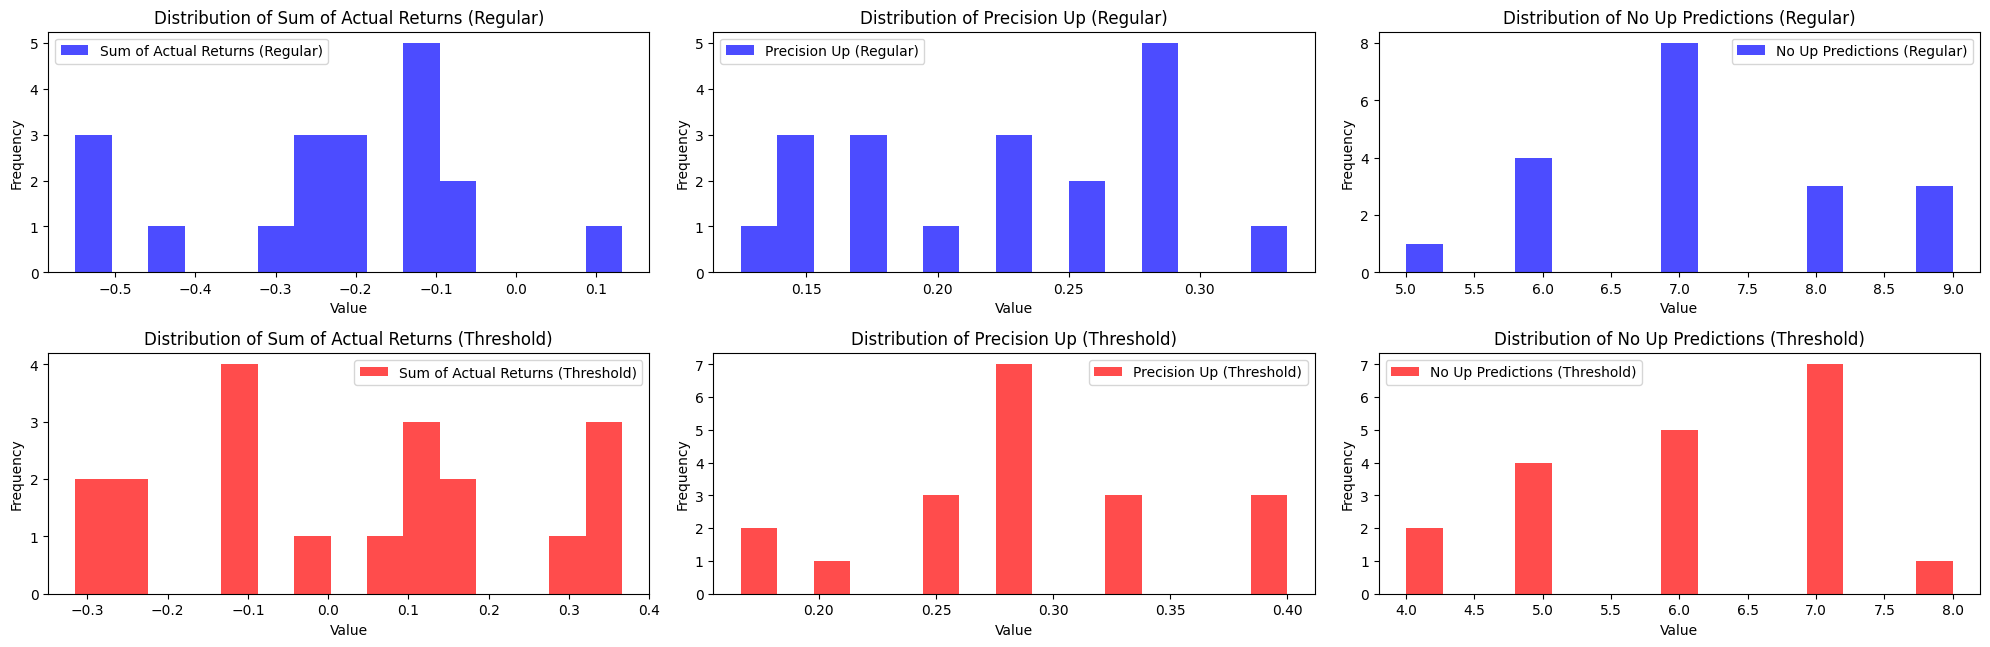

ALL Realizations Regular Unique Actuals Ups: {np.float64(-0.17536183103332204), np.float64(-0.20685732856678574), np.float64(0.06672678088367912), np.float64(0.28744769874477005), np.float64(0.01014370245139462), np.float64(0.15017414464249113), np.float64(-0.23493562231759657), np.float64(0.026851851851851682), np.float64(-0.2302209550962223), np.float64(-0.4469387755102041)}
ALL Realizations Regular Unique Actuals Ups Sum: -0.7529703339499442
Total Unique Up Preds Regular: 10
ALL Realizations Threshold Unique Actuals Ups: {np.float64(-0.17536183103332204), np.float64(0.01014370245139462), np.float64(0.06672678088367912), np.float64(0.15017414464249113), np.float64(-0.20685732856678574), np.float64(0.28744769874477005), np.float64(-0.23493562231759657), np.float64(0.026851851851851682), np.float64(-0.4469387755102041)}
ALL Realizations Threshold Unique Actuals Ups Sum: -0.5227493788537219
Total Unique Up Preds Threshold: 9


In [ ]:
#####       PURPOSE - THIS IS JSUT FOR TESTING 



names_all = { 'res_mac_H_val': res_mac_H_val, 
             'res_mac_H_test': res_mac_H_test}



# Define your groups configuration
groups_config = [
    ("mac",  (-1, 1), 2),
    # ("mac",  (0.1, 0.2), 2),
    # ("mac",  (0.3, 0.5), 2),
    # ("mac",  (-1, 0.3), 3),
    # ("mac",  (0.1, 0.3), 3),
    # ("mac",  (0.3, 0.5), 3)
]


number_realizations = 20

all_results_regular = []
all_results_threshold = []

# random_seeds_seed = 4
# random.seed(random_seeds_seed)


sample_size = number_realizations
seeds = random.sample(range(1, 100000), sample_size)

for i, seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = False,
                                    seed = None,
                                    no_maps_per_group = 30,
                                    filter_outliers = False ,#### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4 ,


                                    )
    all_results_regular.append(results)




for i , seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = True,
                                    seed = None,
                                    no_maps_per_group = 30,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                    )

    all_results_threshold.append(results)

all_groups_prec_up_regular = []
all_groups_total_return_regular = []
no_up_preds_per_group_regular = []
all_realizations_unique_actuals_ups_regular = []



        # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
        # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
        # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

for seed_res in all_results_regular:
    #first set of plots 
    all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_regular.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_regular_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_regular for item in sublist])
all_realizations_unique_actuals_ups_regular_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_regular_UNIQUE)


    

all_groups_prec_up_threshold = []
all_groups_total_return_threshold = []
no_up_preds_per_group_threshold = []
all_realizations_unique_actuals_ups_threshold = []



for seed_res in all_results_threshold:
    all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_threshold.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_threshold_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_threshold for item in sublist])
all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_threshold_UNIQUE)



# {'group_results': {'pair_2_neg03_01': ['None - 0 (3, 9) - 0 - Correct: 0 - []', 'None - 0 (3, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (1, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 12) - 0 - Correct: 0 - []', 'None - 0 (6, 13) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 4) - 0 - Correct: 0 - []', 'None - 0 (13, 14) - 0 - Correct: 0 - []', 'None - 0 (5, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 15) - 0 - Correct: 0 - []', 'None - 0 (14, 15) - 0 - Correct: 0 - []'], 'pair_2_neg03_01_summary':
#  ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_01_03': ['None - 0 (7, 10) - 0 - Correct: 0 - []', 'None - 0 (2, 7) - 0 - Correct: 0 - []', 'None - 0 (3, 5) - 0 - Correct: 0 - []', 'None - 0 (5, 10) - 0 - Correct: 0 - []', 'None - 0 (5, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7) - 0 - Correct: 0 - []', 'None - 0 (6, 9) - 0 - Correct: 0 - []', 'None - 0 (10, 13) - 0 - Correct: 0 - []', 'None - 0 (7, 13) - 0 - Correct: 0 - []', 'None - 0 (10, 11) - 0 - Correct: 0 - []'], 'pair_2_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_03_05': ['None - 0 (11, 13) - 0 - Correct: 0 - []', 'None - 0 (6, 12) - 0 - Correct: 0 - []', 'None - 0 (9, 13) - 0 - Correct: 0 - []', 'None - 0 (8, 15) - 0 - Correct: 0 - []', 'None - 0 (4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 11) - 0 - Correct: 0 - []', 'None - 0 (12, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 14) - 0 - Correct: 0 - []', 'None - 0 (3, 6) - 0 - Correct: 0 - []', 'None - 0 (2, 9) - 0 - Correct: 0 - []'], 'pair_2_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_neg03_01': ['None - 0 (1, 3, 7) - 0 - Correct: 0 - []', 'None - 0 (5, 6, 15) - 0 - Correct: 0 - []', 'None - 0 (1, 3, 15) - 0 - Correct: 0 - []'], 'pair_3_neg03_01_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_01_03': ['None - 0 (5, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7, 10) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 13) - 0 - Correct: 0 - []'], 'pair_3_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_03_05': ['None - 0 (1, 4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 8, 12) - 0 - Correct: 0 - []', 'None - 0 (4, 6, 8) - 0 - Correct: 0 - []', 'None - 0 (2, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (4, 7, 9) - 0 - Correct: 0 - []', 'None - 0 (4, 8, 9) - 0 - Correct: 0 - []', 'None - 0 (8, 12, 14) - 0 - Correct: 0 - []', 'None - 0 (4, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (1, 4, 8) - 0 - Correct: 0 - []', 'None - 0 (1, 6, 8) - 0 - Correct: 0 - []'], 'pair_3_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000']}, 'detailed_results': {'pair_2_neg03_01': [{'combo_numbers': (3, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 4), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (13, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (14, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_01_03': [{'combo_numbers': (7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 5), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_03_05': [{'combo_numbers': (11, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (12, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_neg03_01': [{'combo_numbers': (1, 3, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 6, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_01_03': [{'combo_numbers': (5, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_03_05': [{'combo_numbers': (1, 4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 8, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 7, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 8, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 12, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 4, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}]}, 'summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'total_metrics': {'total_ups': 0, 'total_correct_ups': 0, 'sum_actuals_ups': 0, 'precision': 0}, 'config_info': {'groups_config': [('mac', 'V', (-0.3, 0.1), 2), ('mac', 'V', (0.1, 0.3), 2), ('mac', 'V', (0.3, 0.5), 2), ('mac', 'V', (-0.3, 0.1), 3), ('mac', 'V', (0.1, 0.3), 3), ('mac', 'V', (0.3, 0.5), 3)], 'data_type_corr_groups_creation': 'V', 'data_type_ensemble': 'T', 'use_threshold_data': True, 'seed': None, 'no_maps_per_group': 10}}
import matplotlib.pyplot as plt

# List of variable names and titles
metrics = [
    
    (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
    (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
    (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

    (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
    (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
    (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),


]

plt.figure(figsize=(20, 19))

for i, (var_name, title, color) in enumerate(metrics, 1):

    plt.subplot(6, 3, i)
    data = var_name  # Get the variable by name
    plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {title}')
    plt.legend()

plt.tight_layout()
plt.show()




print("ALL Realizations Regular Unique Actuals Ups:", all_realizations_unique_actuals_ups_regular_UNIQUE)
print("ALL Realizations Regular Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_regular_UNIQUE_SUM)
print("Total Unique Up Preds Regular:", len(all_realizations_unique_actuals_ups_regular_UNIQUE))

print("ALL Realizations Threshold Unique Actuals Ups:", all_realizations_unique_actuals_ups_threshold_UNIQUE)
print("ALL Realizations Threshold Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM)
print("Total Unique Up Preds Threshold:", len(all_realizations_unique_actuals_ups_threshold_UNIQUE))


In [ ]:
##### Threshold Discovery Process 

#####                                   PURPOSE - RUN FOR DIFFERENT THRESHOLDS AND PLOT RESULTS

def thresh(THRESH , data_type_corr_groups_creation ,data_type_ensemble ):

    names_all = { 'res_mac_H_val': res_mac_H_val, 
                 'res_mac_H_test': res_mac_H_test}


    # Define your groups configuration
    groups_config = [
        ("mac", (-1, 1), 2),
        # ("mac",  (0.1, 0.3), 2),
        # ("mac",  (0.3, 0.5), 2),
        # ("mac",  (-0.3, 0.1), 3),
        # ("mac",  (0.1, 0.3), 3),
        # ("mac",  (0.3, 0.5), 3)
    ]

    number_realizations = 40

    all_results_regular = []
    all_results_threshold = []


    random_seeds_seed = 400
    random.seed(random_seeds_seed)


    sample_size = number_realizations
    seeds = random.sample(range(1, 100000), sample_size)
    

    for i ,seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = THRESH,
                                        names_all = names_all,
                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = data_type_corr_groups_creation,
                                        data_type_ensemble = data_type_ensemble,
                                        use_threshold_data = False,
                                        seed = None,
                                        no_maps_per_group = 10,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 2 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                        )
        all_results_regular.append(results)

    for i ,seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = THRESH,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = data_type_corr_groups_creation,
                                        data_type_ensemble = data_type_ensemble,
                                        use_threshold_data = True,
                                        seed = None,
                                        no_maps_per_group = 10,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 2 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                        )

        all_results_threshold.append(results)

    all_groups_prec_up_regular = []
    all_groups_total_return_regular = []
    no_up_preds_per_group_regular = []

    HOD_all_groups_total_return_regular = []
    UCO_all_groups_total_return_regular = []
    HUC_all_groups_total_return_regular = []
    CRUD_all_groups_total_return_regular = []
    USO_all_groups_total_return_regular = []

            # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
            # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
            # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

    for seed_res in all_results_regular:
        #first set of plots 
        all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])

        
    all_groups_prec_up_threshold = []
    all_groups_total_return_threshold = []
    no_up_preds_per_group_threshold = []


    for seed_res in all_results_threshold:
        all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])




    import matplotlib.pyplot as plt

    # List of variable names and titles
    metrics = [
        
        (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
        (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
        (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

        (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
        (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
        (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),

    ]


    import io
    import matplotlib.pyplot as plt

    # Create a bytes buffer to save the figure
    buffer = io.BytesIO()

    plt.figure(figsize=(20, 19))

    for i, (var_name, title, color) in enumerate(metrics, 1):
        plt.subplot(6, 3, i)
        data = var_name  # Get the variable by name
        plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {title}')
        plt.legend()

    plt.tight_layout()

    # Save the figure to the bytes buffer
    plt.savefig(buffer, format='png', dpi=300, bbox_inches='tight')
    plt.close()  # Close the figure to free memory

    # Get the bytes data
    figure_bytes = buffer.getvalue()
    buffer.close()

    return THRESH, figure_bytes

    # Now you can use figure_bytes as needed
    # For example: return figure_bytes, save to file, send over network, etc.

from joblib import Parallel, delayed , parallel_backend

with parallel_backend('loky'):
    res = Parallel(n_jobs=-1)(delayed(thresh)(THRESH , data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "V") for THRESH in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9 , 0.95])
    
with parallel_backend('loky'):
    res2 = Parallel(n_jobs=-1)(delayed(thresh)(THRESH , data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T") for THRESH in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9 , 0.95])
    




Threshold: 0.5


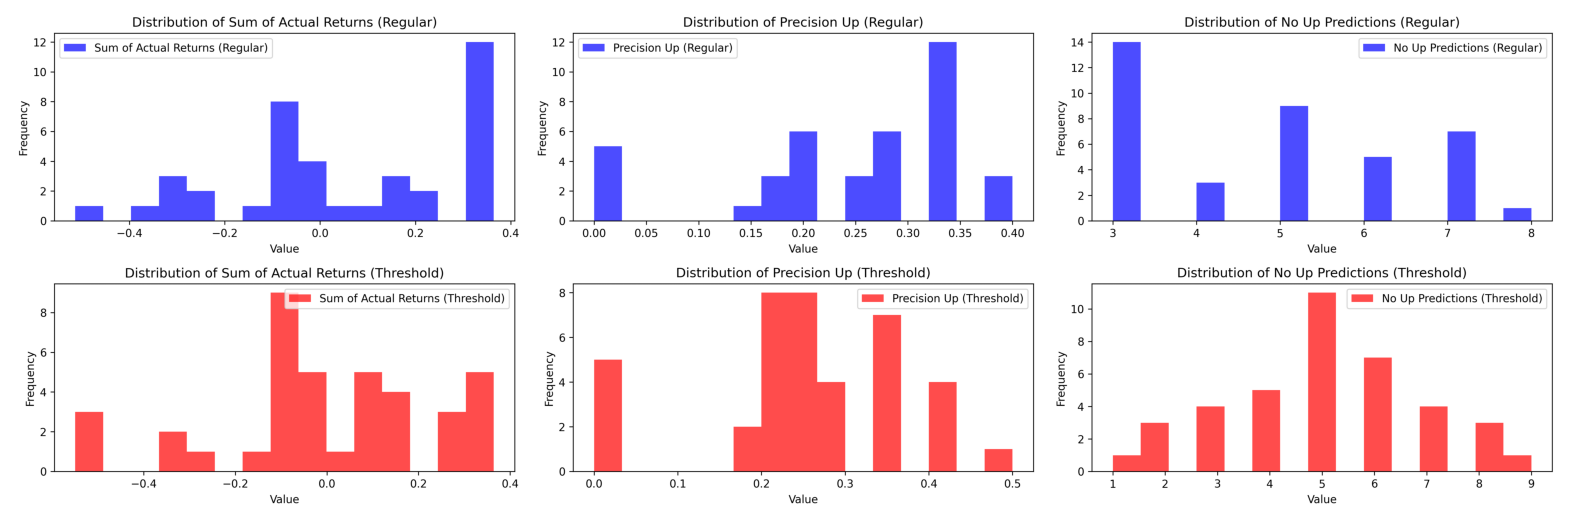

Threshold: 0.55


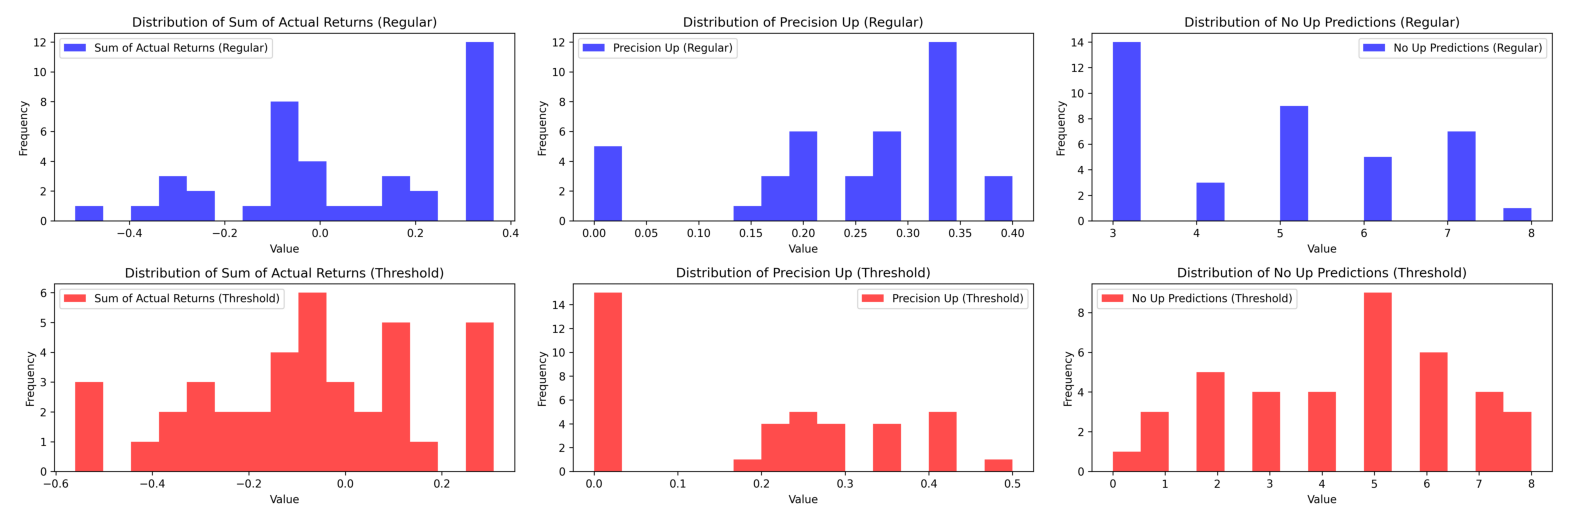

Threshold: 0.6


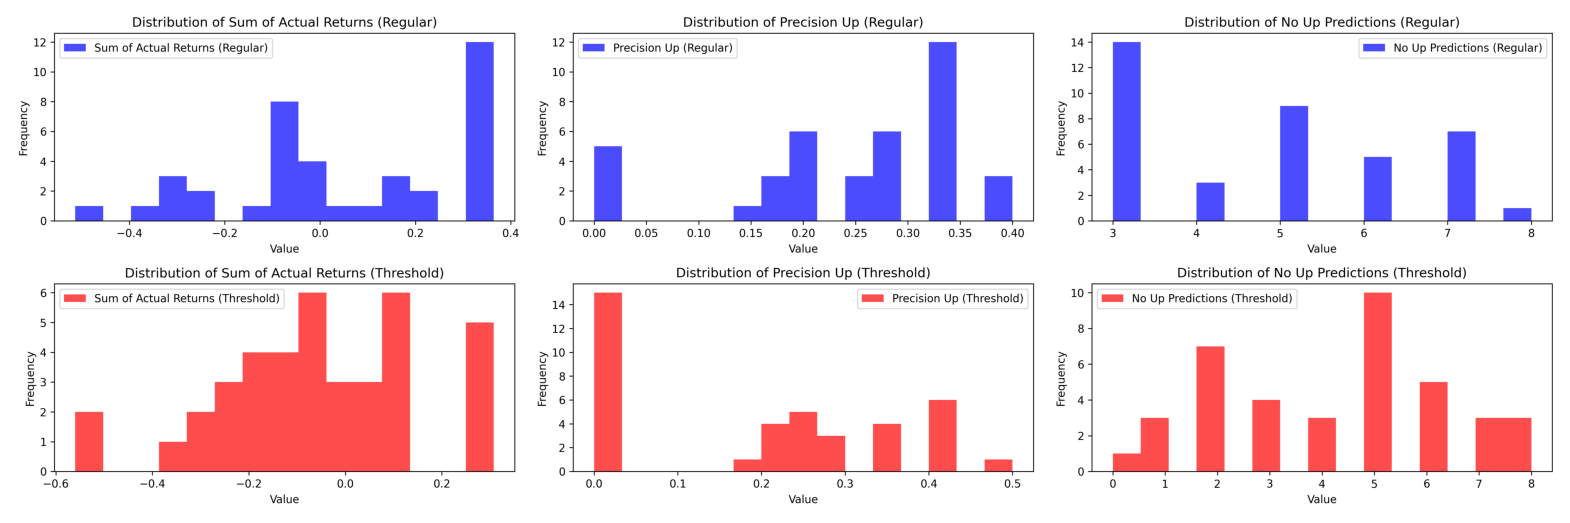

Threshold: 0.65


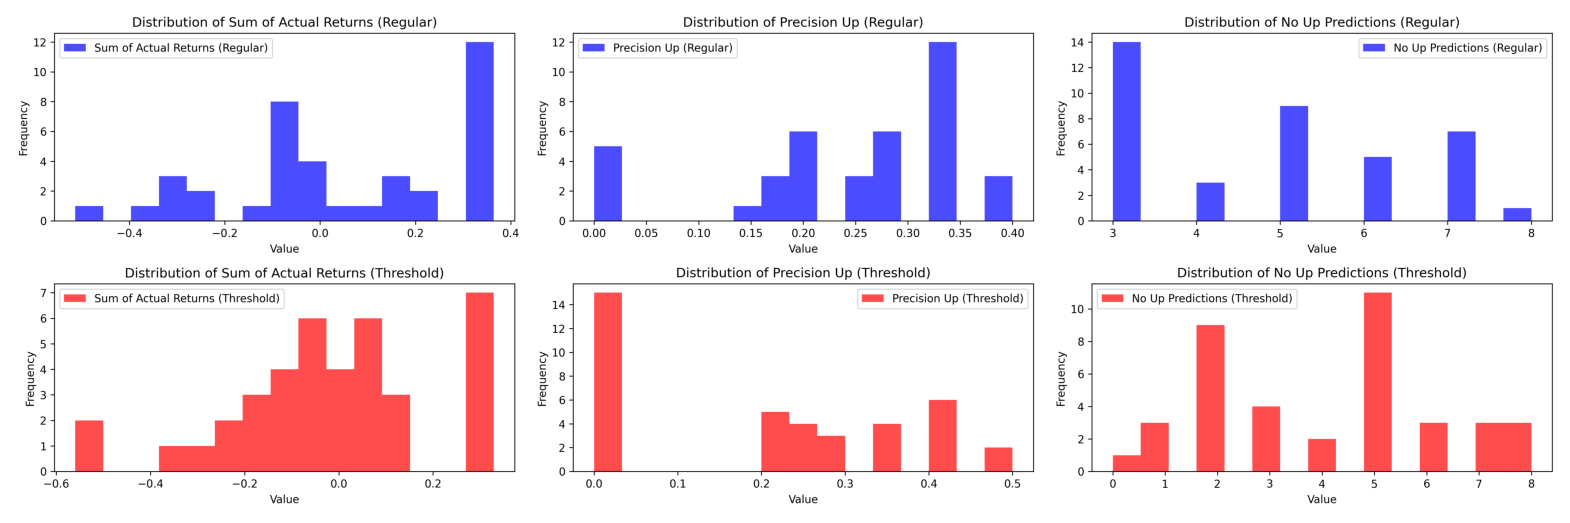

Threshold: 0.7


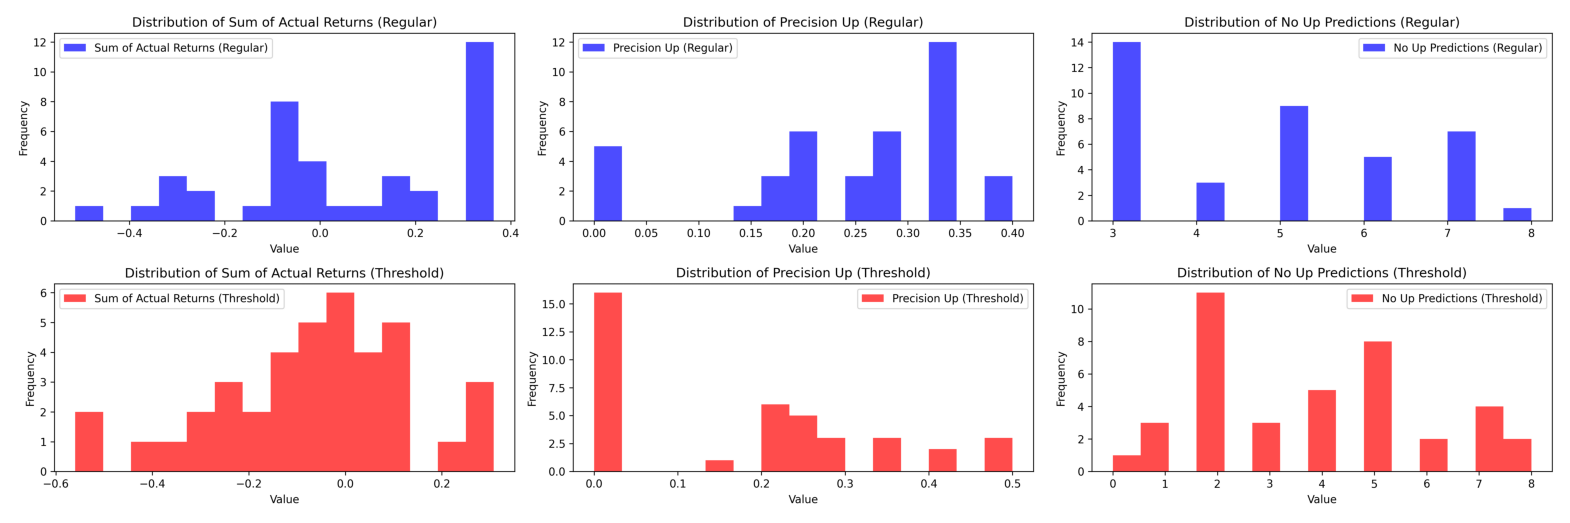

Threshold: 0.75


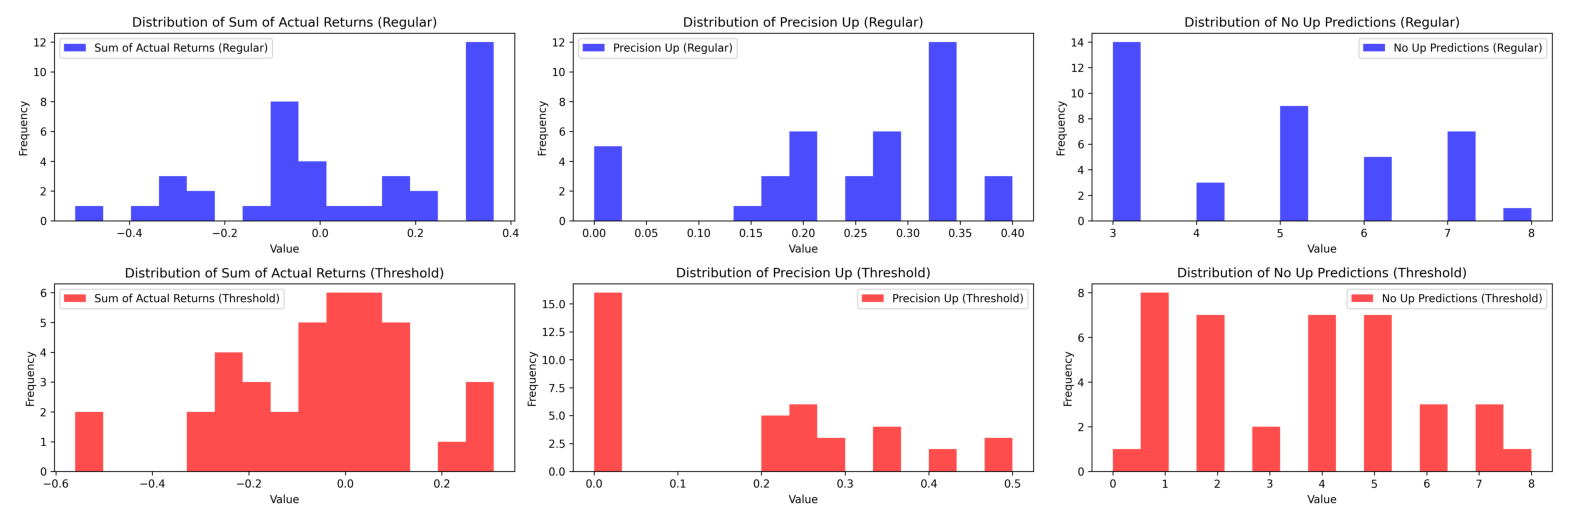

Threshold: 0.8


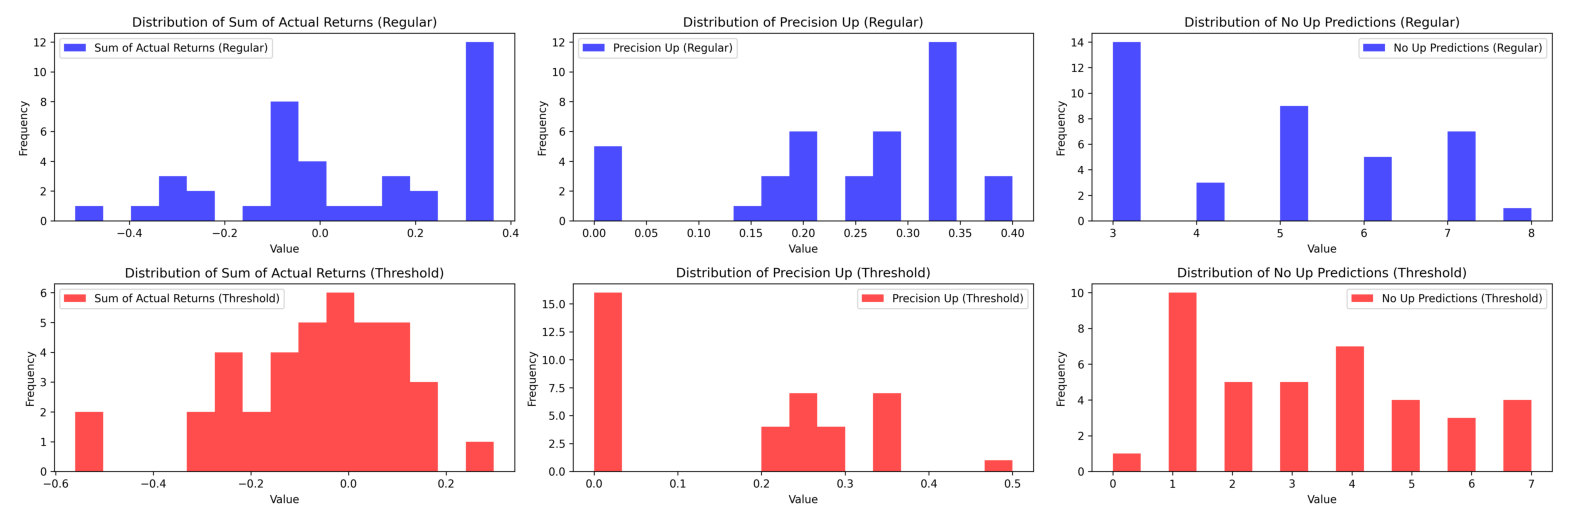

Threshold: 0.85


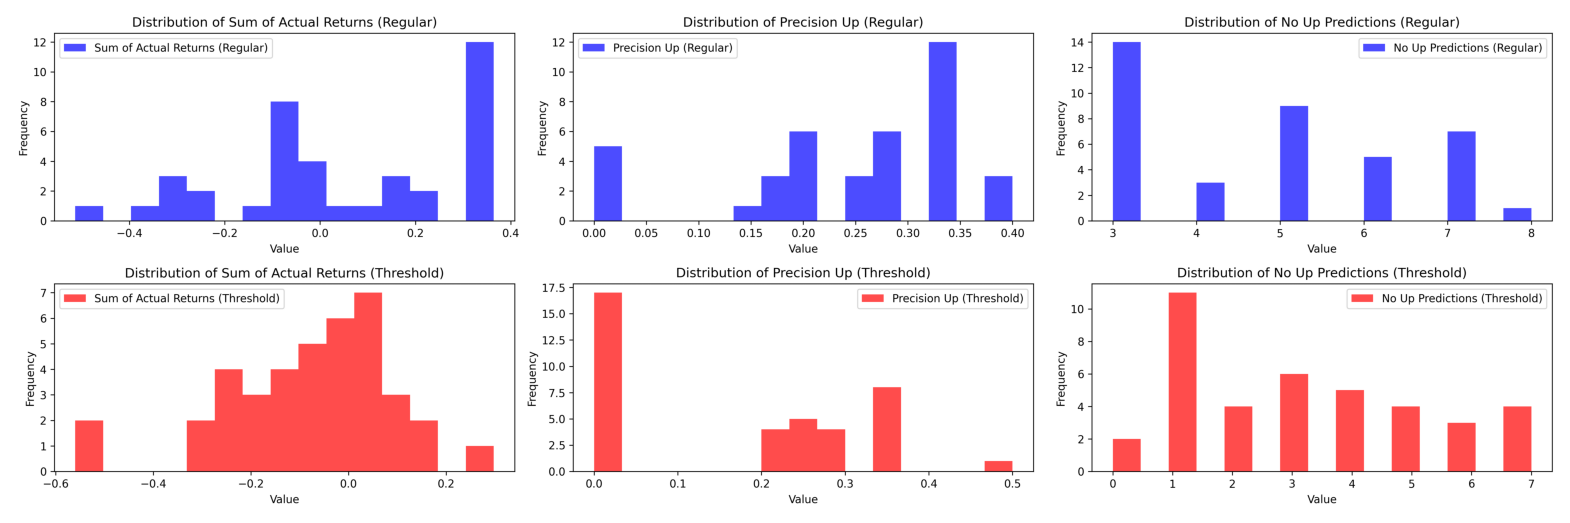

Threshold: 0.9


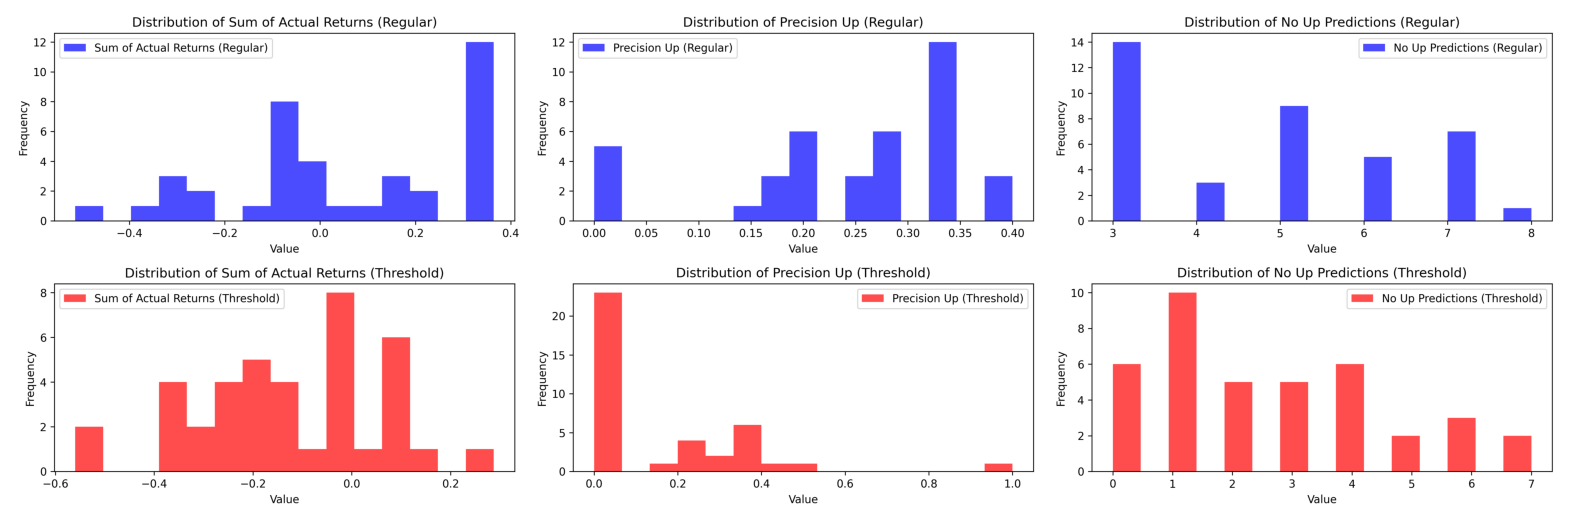

Threshold: 0.95


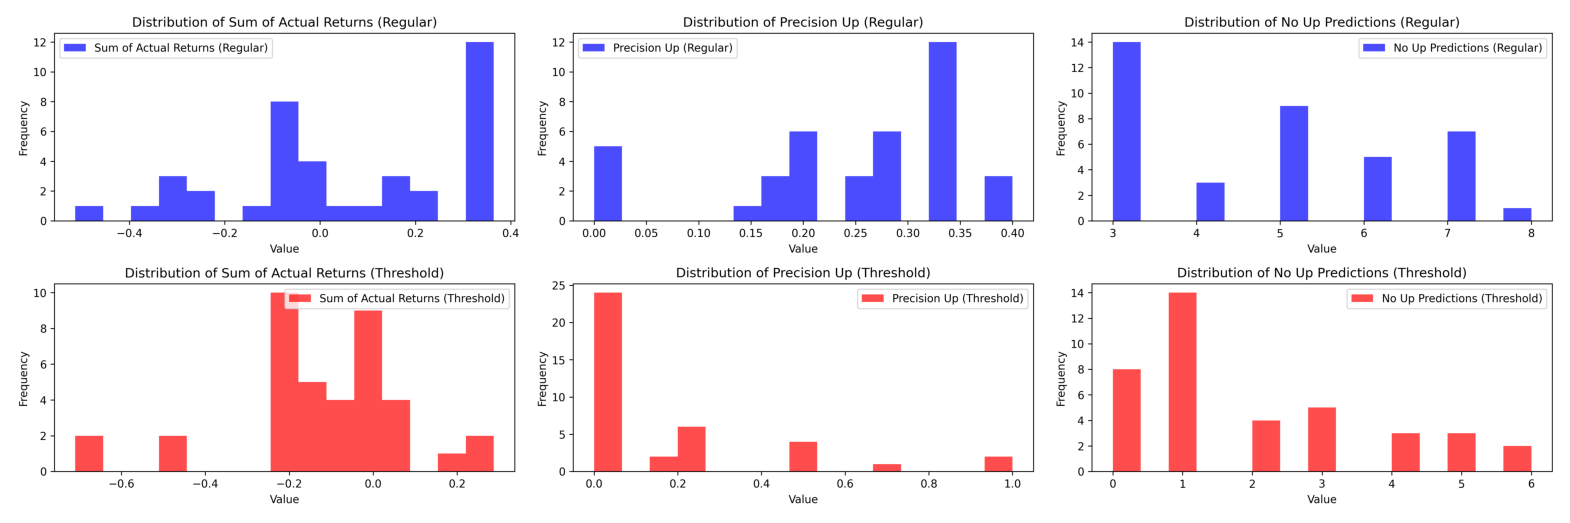

In [ ]:
###### PURPOSE ---- RESULTS PLOTTING FROM THE CODE ABOVCE 


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

thresh , fig_bytes = zip(*res)

thresh2 , fig_bytes2 = zip(*res2)


# for th , fig_bytes in zip(thresh, fig_bytes):
#     print(f"Threshold: {th}")
#     plt.figure(figsize=(20, 19))
#     img = mpimg.imread(io.BytesIO(fig_bytes), format='png')
#     plt.imshow(img)
#     plt.axis('off')  # Hide axes
#     plt.show()


for th , fig_bytes in zip(thresh2, fig_bytes2):
    print(f"Threshold: {th}")
    plt.figure(figsize=(20, 19))
    img = mpimg.imread(io.BytesIO(fig_bytes), format='png')
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()


---
# Part 2 -  Deeper Dive - Precision DIST and Thresh Discovery: GS Best Results Distribution Discovery 
---

In [ ]:
from Equations_Run_Combo_V_2 import *
from Equations_Ensembles_Dist import *

In [ ]:
# #### ----------------------                 RUN COMBOS
# with parallel_backend("loky", n_jobs=3):
#     results = Parallel()(
#         delayed(distribution_discovery)(c, combo_index = i , number_of_seeds = 70)
        
#         for i, c in enumerate(combos)
#     )



# class NpEncoder(json.JSONEncoder):
#     def default(self, obj):
#         if isinstance(obj, numpy.integer):
#             return int(obj)
#         elif isinstance(obj, numpy.ndarray):
#             return obj.tolist()
#         elif isinstance(obj, pd.DatetimeIndex):
#             return obj.tolist()
#         elif isinstance(obj, pd.Timestamp):
#             return obj.isoformat()
#         else:
#             return super(NpEncoder, self).default(obj)


# file = f"70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_Vset_HOD.json"

# with open(file, "w") as f_json:
#     json.dump(results, f_json, cls=NpEncoder, indent=2)

In [16]:

import json

import copy

with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:
    results_dist_disc = json.load(f_json)   # Load the JSON data
    

with open('/Users/cs/Desktop/Tset_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_Vset_HOD.json') as f:
    results_dist_disc_Tset_loaded = json.load(f)

results_dist_disc_Tset = copy.deepcopy(results_dist_disc_Tset_loaded)

ignore = ['val_start_month', 'val_end_month' , 'seed']

for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset:
        f_cb_idx = find["combo_index"]
        ff = str({k: v for k, v in find['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if tt == ff:
            ff['combo_index'] = tt["combo_index"]






In [17]:
def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"

    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"



def TP_FP_brackets_analysis(top_models ,brackets , mdoel_name : str ):
        
    # Count TP and FP for each bracket
    bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})

    for score, entry in top_models:
        for pred_fold, actual_fold in zip(entry['all_preds'], entry['all_actuals']):
            for pred, actual in zip(pred_fold, actual_fold):
                if pred > 0.5:
                    for L, H in brackets:
                        if L < pred < H:
                            if actual > 0.5:
                                bracket_counts[f"{L}-{H}"]['TP'] += 1
                            else:
                                bracket_counts[f"{L}-{H}"]['FP'] += 1

    # Prepare data for plotting
    bracket_labels = sorted(bracket_counts.keys(), key=lambda x: float(x.split('-')[0]))
    tp_counts = [bracket_counts[b]['TP'] for b in bracket_labels]
    fp_counts = [bracket_counts[b]['FP'] for b in bracket_labels]

    # Create plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.35

    plt.bar(x - width/2, tp_counts, width, label='True Positives', color='green', alpha=0.7)
    plt.bar(x + width/2, fp_counts, width, label='False Positives', color='red', alpha=0.7)

    plt.xlabel('Confidence Brackets ')
    plt.ylabel('Count')
    plt.title(f'TP vs FP by Confidence Bracket  - {mdoel_name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def TP_FP_brackets_severity_analysis(top, brackets , name : str ):

    # Count FP severity by bracket
    bracket_severity_counts = defaultdict(lambda: {
        "Pos_high (0.05-0.1)":0 ,
        "Pos_low (0-0.05)":0 , 
        "Neg_low (-0.05) - 0": 0 ,
        "Neg_mid (-0.12) - (-0.05)" : 0 ,
        "Severe (<-0.12)" : 0 })



    for score, entry in top:
        all_preds = entry['all_preds']
        all_actuals = entry['all_actuals']
        raw_actuals = entry['raw_actuals']
        
        # Flatten all arrays
        flat_preds = [p for fold in all_preds for p in fold]
        flat_actuals = [a for fold in all_actuals for a in fold]
        flat_raw_actuals = [r for fold in raw_actuals for r in fold]
        
        for p, a, raw in zip(flat_preds, flat_actuals, flat_raw_actuals):
            # Only process FALSE POSITIVES
            if p > 0.5 and a < 0.5:
                severity = classify_severity_10_percent_pos(raw)

                # print(f"Pred: {p:.3f}, Actual: {a:.3f}, Raw: {raw:.3f} => Severity: {severity}")
                
                # Find which bracket this prediction falls into
                for L, H in brackets:
                    if L < p < H:
                        bracket_severity_counts[f"{L}-{H}"][severity] += 1
                        break

    # Prepare data for plotting
    bracket_labels = sorted(bracket_severity_counts.keys(), key=lambda x: float(x.split('-')[0]))
    severity_categories = ["Pos_high (0.05-0.1)", "Pos_low (0-0.05)", "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", "Severe (<-0.12)"]

    # Create the stacked bar plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.8
    bottom = np.zeros(len(bracket_labels))

    colors = ['lightblue', 'lightgreen', 'yellow' , 'orange', 'red']

    for i, category in enumerate(severity_categories):
        counts = [bracket_severity_counts[b][category] for b in bracket_labels]
        plt.bar(x, counts, width, bottom=bottom, label=category, alpha=0.8, color=colors[i])
        bottom += counts

    plt.xlabel('Confidence Brackets')
    plt.ylabel('Count of False Positives')
    plt.title(f'False Positives by Confidence Bracket vs Actual Severity - {name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add total counts and severity proportions on top
    for i, bracket in enumerate(bracket_labels):
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        plt.text(i, total + 0.5, f"{total}\n({severe_proportion:.0f}% severe)", 
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print severity proportion analytics
    print("Severe Case Proportions by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        print(f"{bracket}: {severe_proportion:.1f}% severe ({severe_count}/{total})")

    print("Severity Counts by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        print(f"{bracket}: {bracket_severity_counts[bracket]}")





In [ ]:
# brackets = [(0.5, 0.6), (0.6, 0.65), (0.65, 0.7), (0.7, 0.75), 
#             (0.75, 0.8), (0.8, 0.85), (0.85, 0.9), (0.9, 0.95), (0.95, 1)]

# prec_brackets = [(70, 75), (75, 80), (80, 85), (85, 90), (90, 95), (95, 100)]

# # We assume you already have:
# # - buckets            : buckets["combo_idx_<idx>"][seed][(L,H)] = [ {"precision_up": p, "result": <per-seed dict>}, ... ]
# # - brackets           : confidence bins for p (e.g., [(0.5,0.6), ... , (0.95,1.0)])
# # - prec_brackets      : precision% bins (e.g., [(70,75), ... , (95,100)])
# # - TP_FP_brackets_analysis(top_models, brackets, title)
# # - TP_FP_brackets_severity_analysis(top_models, brackets, title)

# def _combo_sort_key(k):
#     try:
#         return int(str(k).split("_")[-1])
#     except Exception:
#         return str(k)

# def _seed_sort_key(s):
#     try:
#         return int(s)
#     except Exception:
#         return s

# for combo_key in buckets.keys():
#     # if int(combo_key.split('_')[-1]) == 68 : 
#         seed_map = buckets.get(combo_key)

#         for prec_br in prec_brackets:
#             # collect ALL items in this precision bracket across seeds (stable seed order)
#             items_for_br = []
#             for seed in seed_map.keys():
#                 items_for_br.extend(seed_map[seed].get(prec_br, []))

#             if not items_for_br:
#                 # no entries for this precision bracket in this combo
#                 continue

#             # take first 5 items for this precision bracket
#             LENGTH = 5
#             sample = items_for_br[:LENGTH]

#             for idx, it in enumerate(sample, start=1):
#                 res = it.get("result", {})
#                 entry = res.get("result_entry", {})
#                 seed_val = res.get("seed")
#                 prec_up  = it.get("precision_up")

#                 # Build inputs for the plotting functions using JUST THIS ONE item
#                 top_basic = []
#                 top_sev   = []

#                 if ("all_preds" in entry) and ("all_actuals" in entry):
#                     top_basic = [(0.0, entry)]
#                     if "raw_actuals" in entry:
#                         top_sev = [(0.0, entry)]

#                 title = f"{combo_key} — precision {prec_br} — item {idx}/5 — seed {seed_val}"

#                 if top_basic:
#                     print(f"Plot {idx}/5 | {combo_key} | prec_br={prec_br} | seed={seed_val} | precision_up={prec_up}")
#                     TP_FP_brackets_analysis(top_basic, brackets, title)
#                 else:
#                     print(f"[skip] {title}: missing all_preds/all_actuals")

#                 if top_sev:
#                     TP_FP_brackets_severity_analysis(top_sev, brackets, title)
#                 else:
#                     print(f"[skip severity] {title}: raw_actuals missing")


In [ ]:
import json
with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:

    results_dist_disc = json.load(f_json)   # Load the JSON data



In [ ]:
import copy

#############   SEEDS AND COMBO NUMBERS WER DETERMINED FROM THEH FINDINGS BELOW 

# models:
 
# 68 - seeds high  seeds low
# 32 - seeds high 6963  seeds low 2703
# 43 - seeds high 11794 seeds low 30341
# 58- seeds high 26058 seeds low 
# 6- seeds high 1719 seeds low 3556
# 0 - seeds high 42 seeds low 4198
# 57 - seeds high 14577  seeds low
# --- 
# 31- seeds high 35229 seeds low                9118high
# 60 - seeds high 4956  seeds low 48198

# combo_number and seeds dict

seeds_H_list = { 
                
                32: {'H' : 6963 , 'L' : 2703}, 
                43: {'H' : 11794 , 'L' : 30341},
                58: {'H' : 26058 , 'L' : None},
                6: {'H' : 1719 , 'L' : 3556},
                0: {'H' : 42 , 'L' : 4198},
                57: {'H' : 14577 , 'L' : None},
                68: {'H' : None , 'L' : None},
                31: {'H' : 35229 , 'L' : 9118},
                60: {'H' : 4956 , 'L' : 48198}
                
                }

res_GC_H_val = []
res_GC_L_val = []

for entry in results_dist_disc:
    for combo_idx in seeds_H_list.keys():
        if entry["combo_index"] == combo_idx:
            for run in entry["per_seed_all_results"]:
                high_seed = seeds_H_list[combo_idx]['H']
                low_seed = seeds_H_list[combo_idx]['L']
                if run['seed'] == high_seed:
                    res_GC_H_val.append(run["result_entry"])
                if run['seed'] == low_seed and low_seed is not None:
                    res_GC_L_val.append(run["result_entry"])



test_param_res_GC_H_val = []
test_param_res_GC_L_val = []

for entry in copy.deepcopy(res_GC_H_val):
    param = entry["parameters"] 
    param['val_start_month'] = '2022-01'
    param['val_end_month'] = '2022-12'
    test_param_res_GC_H_val.append(param)

for entry in copy.deepcopy(res_GC_L_val):
    param = entry["parameters"] 
    param['val_start_month'] = '2022-01'
    param['val_end_month'] = '2022-12'
    test_param_res_GC_L_val.append(param)
    


In [ ]:
res_GC_H_val[0]

{'combo_number': 1,
 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 70,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 6,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': False,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': False,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1.5,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO

In [ ]:
# ##### RUn val set results on mac, the idea is to get les overfitted results, in order to asses the optimal thresh from the algo where we plot the results for many thresh 
# # in the V set adn sthen choose the optimal thresh fro teh T set adn see if tehre is a corr 


# with parallel_backend("loky", n_jobs=-1):
#     results_H_val_mac = Parallel()(
#         delayed(run_combo_V_4)(i, combo["parameters"], total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(res_GC_H_val)
#     )


# ###### THSI WAS RUN ON A C4D WHERE AS THE FIRST VERSION WAS RUN ON N2D , THE MAC AND C4D SEEM TO PREDORM THE EXACT SAME ... MAYBE THE SAME MATH LIBRATIES ... 
# # BUT THE N2D IS DIFFERENT ...

##### NOTE if you look at the all_preds probabs, you will see that they are very similar but not exactly the same ...

In [ ]:
# # import pickle 

# # with open('res_GC_H_val')

# res , w = zip(*results_L_val_mac)

# for i in res:
#     print(i['cv_sets']['overall_metrics'])

In [ ]:
# with parallel_backend("loky", n_jobs=-1):
#     results_L_val_mac = Parallel()(
#         delayed(run_combo_V_4)(i, combo["parameters"], total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(res_GC_L_val)
#     )



In [ ]:

# with parallel_backend("loky", n_jobs=-1):
#     results_H = Parallel()(
#         delayed(run_combo_V_4)(i, combo, total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(test_param_res_GC_H_val)
#     )




In [ ]:


# with parallel_backend("loky", n_jobs=-1):
#     results_L = Parallel()(
#         delayed(run_combo_V_4)(i, combo, total_offset = 0, use_print_acc_vs_pred=False , pred_threshold_sigmoid01_up_bool = False)
#         for i, combo in enumerate(test_param_res_GC_L_val)
#     )

In [ ]:
# import pickle 


# with open('results_H.pkl' , 'wb' ) as f:
#     pickle.dump(results_H , f)
# with open('results_L.pkl' , 'wb' ) as f:
#     pickle.dump(results_L , f)

In [ ]:
import pickle

with open('results_H_mac_T_manual_selection_dist HOD 20_01 - 21_12.pkl' , 'rb' ) as f: ## MAC test
    results_H  = pickle.load(f)
with open('results_L_mac_T_manual_selection_dist HOD 20_01 - 21_12.pkl' , 'rb' ) as f: ## MAC test results_H_mac_T_manual_selection HOD 20_01 - 21_12
    results_L = pickle.load(f)


res_mac_H_test , w = zip(*results_H)

for i in res_mac_H_test:
    print(i['cv_sets']['overall_metrics']["precision_up"] , '<---->' , i['parameters'] )


res_mac_L_test , w = zip(*results_L)

for i in res_mac_L_test:
    print(i['cv_sets']['overall_metrics']["precision_up"] , '<---->' , i['parameters'] )

33.33333333333333 <----> {'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1.5, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predict

In [ ]:
from Results_Dists_V_2 import *

In [ ]:



res_mac_H_val = res_GC_H_val
res_mac_L_val = res_GC_L_val



# Add threshold metrics
names_all = [res_mac_L_val, res_mac_H_val, res_mac_L_test, res_mac_H_test]

names_test = [res_mac_L_test, res_mac_H_test]
names_val = [res_mac_L_val, res_mac_H_val]


for data in names_all:
    add_threshold_metrics(data, threshold=.7)


res_mac_L_test


({'combo_number': 1,
  'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
   'learning_rate': 0.005,
   'num_epochs': 150,
   'batch_size': 10,
   'use_bidirectional': False,
   'lag': 2,
   'input_size': 12,
   'hidden_size': 55,
   'num_layers': 1,
   'use_monthly_dfs_only': True,
   'use_binary_0_1_retRate': False,
   'use_custom_loss_function_BCE_THRESH': True,
   'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
   'use_LOW_weights_for_BCE_custom_loss': True,
   'pred_threshold_sigmoid01_up': None,
   'use_binary_neg1_1': False,
   'use_ret_rate': False,
   'use_print_acc': False,
   'use_dropout': False,
   'use_class_weighting': True,
   'is_deterministic': True,
   'seed_num': 9118,
   'use_existing_lagged_data': True,
   'use_dynamic_weights': False,
   'use_binary_0_1_retRate_custom_neg': False,
   'use_binary_0_1_retRate_custom_pos': True,
   'POS_weight_multiplier': 0.1,
   'use_rolling_fixed_train_size': False,
   'use_existing_initial_weights': False,
 

In [ ]:
# Create DataFrames
df_mac_L_val = flatten_results(res_mac_L_val)
df_mac_H_val = flatten_results(res_mac_H_val)
df_mac_L_test = flatten_results(res_mac_L_test)
df_mac_H_test = flatten_results(res_mac_H_test)

# Add H/L labels
df_mac_L_val['H_L'] = 'L'
df_mac_H_val['H_L'] = 'H'
df_mac_L_test['H_L'] = 'L'
df_mac_H_test['H_L'] = 'H'

dfs = [df_mac_L_val, df_mac_H_val, df_mac_L_test, df_mac_H_test]

# Add various metrics
add_up_prediction_counts(dfs)
add_false_correct_up_stats(dfs)
flatten_metrics_columns(dfs)


master_df = process_parameters_and_merge(dfs)


# print(master_df.columns)
# print(master_df["all_actuals_mac_V"])

In [ ]:
display(master_df[[
    "OA_prec_1_mac_V", "OA_rec_1_mac_V", "no_1_preds_mac_V", "actuals_false_1_mac_V",
    'false_1_preds_mac_V', 'correct_1_preds_mac_V', 'actuals_correct_1_mac_V',
    "OA_prec_1_mac_T", "OA_rec_1_mac_T", "no_1_preds_mac_T", "actuals_false_1_mac_T",
    'false_1_preds_mac_T', 'correct_1_preds_mac_T', 'actuals_correct_1_mac_T',
    "H_L_mac_T", "H_L_mac_V", "param_int_Vue_mac_T"
]].round(4))


display(master_df[[
    "OA_thresh_prec_1_thresh_mac_V", "OA_thresh_rec_1_thresh_mac_V", "no_1_preds_thresh_mac_V", 
    "actuals_false_1_thresh_mac_V", 'false_1_preds_thresh_mac_V', 'correct_1_preds_thresh_mac_V', 
    'actuals_correct_1_thresh_mac_V',
    "OA_thresh_prec_1_thresh_mac_T", "OA_thresh_rec_1_thresh_mac_T", "no_1_preds_thresh_mac_T", 
    "actuals_false_1_thresh_mac_T", 'false_1_preds_thresh_mac_T', 'correct_1_preds_thresh_mac_T', 
    'actuals_correct_1_thresh_mac_T' , "param_int_Vue_mac_T"
]].round(4))


,OA_prec_1_mac_V,OA_rec_1_mac_V,no_1_preds_mac_V,actuals_false_1_mac_V,false_1_preds_mac_V,correct_1_preds_mac_V,actuals_correct_1_mac_V,OA_prec_1_mac_T,OA_rec_1_mac_T,no_1_preds_mac_T,actuals_false_1_mac_T,false_1_preds_mac_T,correct_1_preds_mac_T,actuals_correct_1_mac_T,H_L_mac_T,H_L_mac_V,param_int_Vue_mac_T
0,100.0,33.3333,2,[],[],"[0.531, 0.6091]","[0.1014, 0.1347]",40.0000,100.0,5,"[-0.2349, -0.2302, 0.0101]","[0.6094, 0.6976, 0.5165]","[0.5042, 0.5057]","[0.2874, 0.1502]",L,L,1
1,100.0,33.3333,2,[],[],"[0.9109, 0.7563]","[0.1014, 0.1347]",50.0000,100.0,4,"[-0.2349, 0.0101]","[0.7233, 0.8586]","[0.7829, 0.6306]","[0.2874, 0.1502]",H,H,7
2,75.0,50.0000,4,[-0.2673],[0.5486],"[0.8355, 0.5581, 0.8486]","[0.3069, 0.1856, 0.1014]",40.0000,100.0,5,"[-0.2302, 0.0101, -0.2069]","[0.9178, 0.5974, 0.5025]","[0.5329, 0.8385]","[0.2874, 0.1502]",L,L,2
3,100.0,16.6667,1,[],[],[0.8363],[0.1347],NaN,0.0,0,[],[],[],[],H,H,9
4,100.0,33.3333,2,[],[],"[0.9329, 0.9927]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0101],[0.9907],[],[],H,H,8
5,100.0,33.3333,2,[],[],"[0.6753, 0.939]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0667],[0.8714],[],[],H,H,6
6,100.0,16.6667,1,[],[],[0.8605],[0.1347],NaN,0.0,0,[],[],[],[],L,L,0
7,100.0,33.3333,2,[],[],"[0.5229, 0.9925]","[0.1014, 0.1347]",33.3333,100.0,6,"[-0.2349, 0.0667, 0.0101, -0.2069]","[0.978, 0.9944, 0.9916, 0.8651]","[0.6934, 0.5413]","[0.2874, 0.1502]",H,H,5
8,100.0,50.0000,3,[],[],"[0.5923, 0.9853, 0.9721]","[1.1117, 0.1014, 0.1347]",33.3333,100.0,6,"[-0.2349, 0.0667, 0.0101, -0.2069]","[0.9973, 0.995, 0.9948, 0.9737]","[0.8711, 0.9854]","[0.2874, 0.1502]",H,H,4
9,75.0,50.0000,4,[-0.2858],[0.712],"[0.8059, 0.9993, 0.9507]","[0.1856, 1.1117, 0.1347]",0.0000,0.0,1,[0.0667],[0.9443],[],[],L,L,3


,OA_thresh_prec_1_thresh_mac_V,OA_thresh_rec_1_thresh_mac_V,no_1_preds_thresh_mac_V,actuals_false_1_thresh_mac_V,false_1_preds_thresh_mac_V,correct_1_preds_thresh_mac_V,actuals_correct_1_thresh_mac_V,OA_thresh_prec_1_thresh_mac_T,OA_thresh_rec_1_thresh_mac_T,no_1_preds_thresh_mac_T,actuals_false_1_thresh_mac_T,false_1_preds_thresh_mac_T,correct_1_preds_thresh_mac_T,actuals_correct_1_thresh_mac_T,param_int_Vue_mac_T
0,NaN,0.0000,0,[],[],[],[],NaN,NaN,0,[],[],[],[],1
1,100.0,33.3333,2,[],[],"[0.9109, 0.7563]","[0.1014, 0.1347]",33.3333,50.0,0,"[-0.2349, 0.0101]","[0.7233, 0.8586]",[0.7829],[0.2874],7
2,100.0,33.3333,2,[],[],"[0.8355, 0.8486]","[0.3069, 0.1014]",50.0000,50.0,0,[-0.2302],[0.9178],[0.8385],[0.1502],2
3,100.0,16.6667,1,[],[],[0.8363],[0.1347],NaN,0.0,0,[],[],[],[],9
4,100.0,33.3333,2,[],[],"[0.9329, 0.9927]","[1.1117, 0.1347]",0.0000,0.0,0,[0.0101],[0.9907],[],[],8
5,100.0,16.6667,1,[],[],[0.939],[0.1347],0.0000,0.0,0,[0.0667],[0.8714],[],[],6
6,100.0,16.6667,1,[],[],[0.8605],[0.1347],NaN,0.0,0,[],[],[],[],0
7,100.0,16.6667,1,[],[],[0.9925],[0.1347],0.0000,NaN,0,"[-0.2349, 0.0667, 0.0101, -0.2069]","[0.978, 0.9944, 0.9916, 0.8651]",[],[],5
8,100.0,33.3333,2,[],[],"[0.9853, 0.9721]","[0.1014, 0.1347]",33.3333,100.0,0,"[-0.2349, 0.0667, 0.0101, -0.2069]","[0.9973, 0.995, 0.9948, 0.9737]","[0.8711, 0.9854]","[0.2874, 0.1502]",4
9,75.0,50.0000,4,[-0.2858],[0.712],"[0.8059, 0.9993, 0.9507]","[0.1856, 1.1117, 0.1347]",0.0000,0.0,0,[0.0667],[0.9443],[],[],3


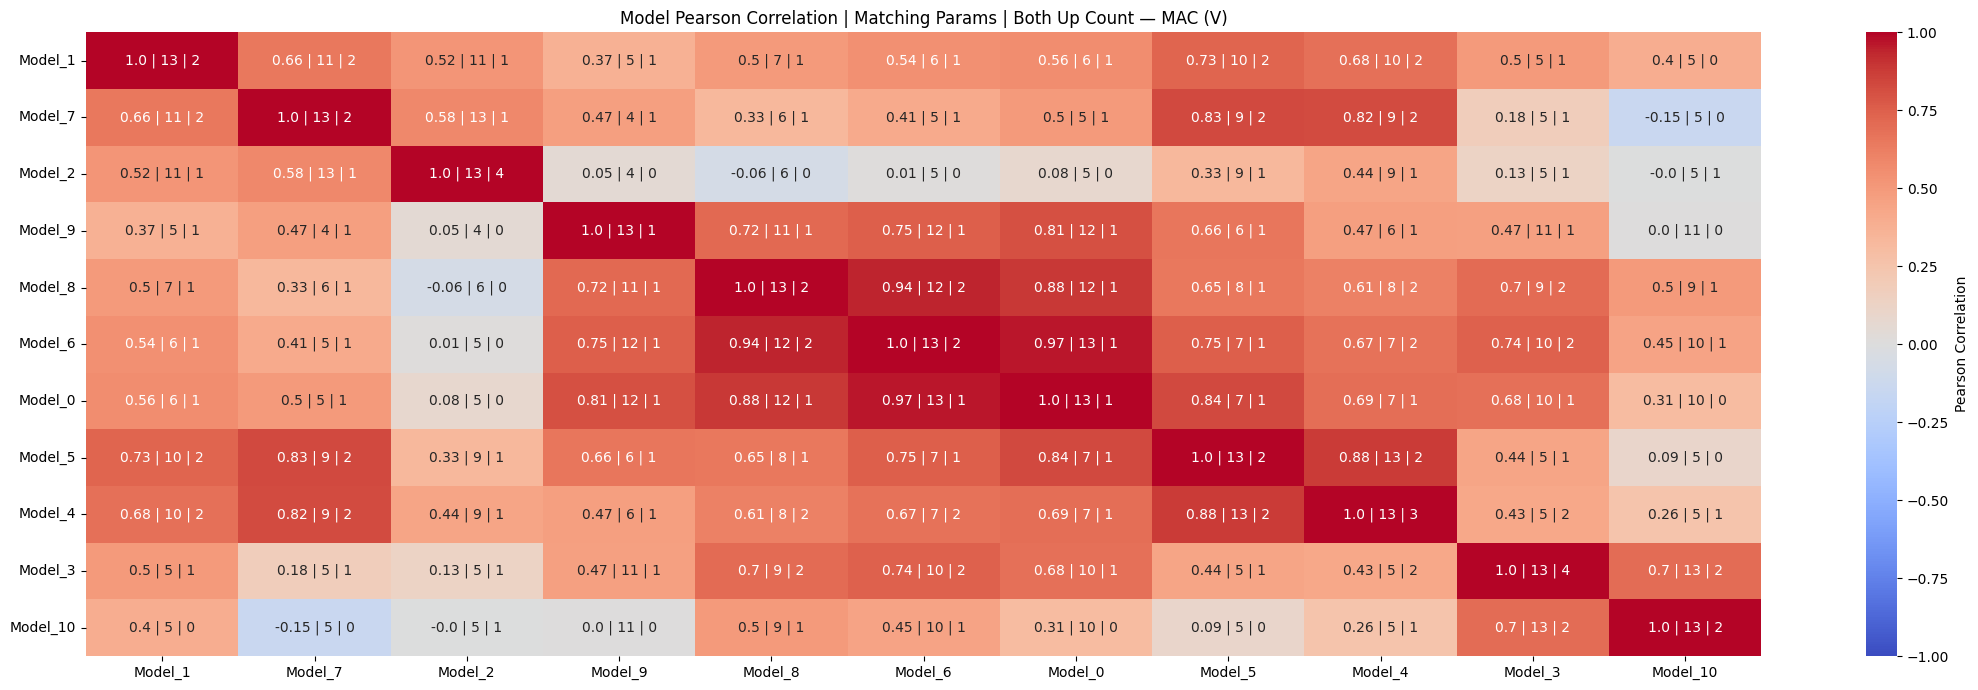

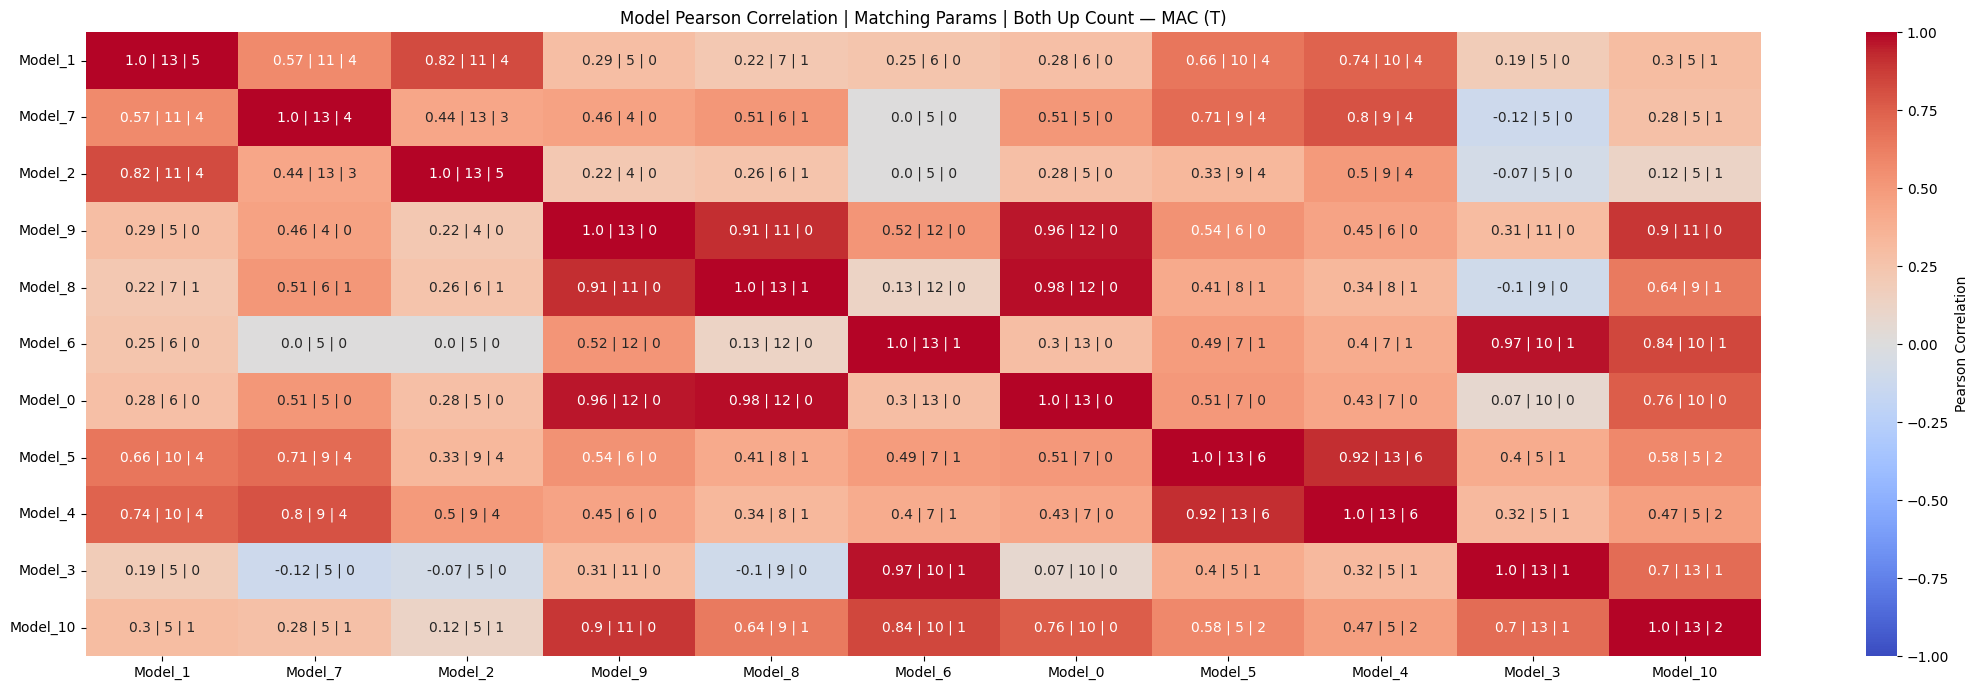

[(1, 3, 9), (2, 3, 4), (2, 3, 5), (2, 4, 10), (3, 4, 9), (3, 7, 9)]

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_model_corr(master_df, machine="mac", set_type="V", use_spearman=True, use_01_preds=False):
    """
    Plots correlation and matching-parameter counts for models
    from a given machine ('mac' or 'gc') and set type ('V' or 'T'),
    using the param_int_Vue column as the unique model ID.
    
    Returns: Dictionary with keys as model pairs (tuple) and values as (same_params_count, correlation, both_up_count)
    """
    # Dynamic column names
    preds_col  = f"all_preds_{machine}_{set_type}"
    params_col = f"parameters_{machine}_{set_type}"
    id_col     = f"param_int_Vue_{machine}_{set_type}"  # unique model integer

    # Extract relevant rows
    block = master_df[[preds_col, params_col, id_col]].reset_index(drop=True)
    if block.empty:
        raise ValueError(f"No data found for machine '{machine}' and set '{set_type}'.")

    # 1. Flatten predictions and get model IDs
    all_preds_list = []
    model_ids = []
    
    for idx, preds in enumerate(block[preds_col]):
        flat = [p for fold in preds for p in fold]  # flatten folds
        if use_01_preds:
            flat = [1 if p >= 0.5 else -1 for p in flat]  # binary conversion
        all_preds_list.append(flat)
        model_ids.append(int(block.iloc[idx][id_col]))

    labels = [f"Model_{mid}" for mid in model_ids]
    n_models = len(all_preds_list)
    n_samples = len(all_preds_list[0])  # number of predictions per model

    # 2. Correlation matrix - unified approach
    corr = np.zeros((n_models, n_models))
    both_up_counts = np.zeros((n_models, n_models), dtype=int)  # New: count of both predicting up
    
    for i in range(n_models):
        for j in range(n_models):
            if i <= j:  # Calculate only once for each pair
                # Correlation
                if use_spearman:
                    rho, _ = spearmanr(all_preds_list[i], all_preds_list[j])
                else:
                    rho = np.corrcoef(all_preds_list[i], all_preds_list[j])[0, 1]
                corr[i, j] = rho
                corr[j, i] = rho  # Symmetric matrix
                
                # Count both predicting up (>=0.5) at the same time
                if not use_01_preds:
                    # Convert to binary for counting both up (only if not already in 0/1 form)
                    preds_i_bin = [1 if p >= 0.5 else 0 for p in all_preds_list[i]]
                    preds_j_bin = [1 if p >= 0.5 else 0 for p in all_preds_list[j]]
                else:
                    # Already in binary form: 1 for up, -1 for down (so convert -1 to 0)
                    preds_i_bin = [1 if p == 1 else 0 for p in all_preds_list[i]]
                    preds_j_bin = [1 if p == 1 else 0 for p in all_preds_list[j]]
                
                count_both_up = sum((a == 1) and (b == 1) for a, b in zip(preds_i_bin, preds_j_bin))
                both_up_counts[i, j] = count_both_up
                both_up_counts[j, i] = count_both_up  # Symmetric

    corr_df = pd.DataFrame(corr, index=labels, columns=labels)
    both_up_df = pd.DataFrame(both_up_counts, index=labels, columns=labels)  # DataFrame for both_up counts

    # 3. Matching parameter counts
    keys_to_check = [
        "learning_rate", "num_epochs", "batch_size", "lag",
        "num_layers", "input_size", "use_rolling_fixed_train_size",
        "hidden_size", "use_class_weighting", "use_dropout", 
        "use_custom_loss_function_BCE_THRESH", "train_start_month", "seed"
    ]
    params_list = block[params_col].tolist()
    match_counts = np.zeros((n_models, n_models), dtype=int)

    for i in range(n_models):
        for j in range(n_models):
            p1, p2 = params_list[i], params_list[j]
            if not isinstance(p1, dict) or not isinstance(p2, dict):
                continue
            match_counts[i, j] = sum(p1.get(k) == p2.get(k) for k in keys_to_check)

    match_df = pd.DataFrame(match_counts, index=labels, columns=labels)

    # 4. Annotated heatmap: now with three metrics
    annot = corr_df.round(2).astype(str) + " | " + match_df.astype(str) + " | " + both_up_df.astype(str)
    
    correlation_type = "Spearman" if use_spearman else "Pearson"
    
    plt.figure(figsize=(22, 7))
    sns.heatmap(
        corr_df,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        cbar_kws={'label': f'{correlation_type} Correlation'}
    )
    plt.title(f"Model {correlation_type} Correlation | Matching Params | Both Up Count — {machine.upper()} ({set_type})")
    plt.tight_layout()
    plt.show()

    # 5. Create return data: dictionary with keys as model pairs and values as (same_params, correlation, both_up_count)
    return_data = {}
    for i in range(n_models):
        for j in range(i + 1, n_models):  # Only unique pairs, avoid self-comparisons and duplicates
            model_pair = (model_ids[i], model_ids[j])
            same_params = match_counts[i, j]
            correlation = corr[i, j]
            both_up = both_up_counts[i, j]
            return_data[model_pair] = (same_params, correlation, both_up)

    return return_data

# Example usage:
result_V = plot_model_corr(master_df, machine="mac", set_type="V", use_spearman=False, use_01_preds=False)
result_T = plot_model_corr(master_df, machine="mac", set_type="T", use_spearman=False, use_01_preds=False)




from itertools import combinations
import numpy as np
import pandas as pd
from itertools import combinations
import numpy as np
import pandas as pd

def get_model_groups_in_corr_range_diff_params_and_same_up_preds(master_df, machine, set_type, corr_range, group_size=2, 
                                 use_spearman_bool=False, num_diff_params=None, 
                                 min_same_up_preds=None, max_same_up_preds=None):
    """
    Find groups of models (size=group_size) whose pairwise correlations
    of predictions fall within [low, high), with optional parameter difference filtering
    and same "up" predictions filtering.

    Args:
        master_df (pd.DataFrame): your merged DF.
        machine (str): 'mac' or 'gc'.
        set_type (str): 'V' or 'T'.
        corr_range (tuple): (low, high) inclusive/exclusive as [low, high).
        group_size (int): number of models per group (>=2).
        use_spearman_bool (bool): if True, use Spearman correlation; else use Pearson.
        num_diff_params (int or None): Minimum number of different parameters required 
                                     between models in the group. If None, no filtering.
        min_same_up_preds (int or None): Minimum number of times both models predict "up" (>=0.5)
                                        for the same entry. If None, no filtering.
        max_same_up_preds (int or None): Maximum number of times both models predict "up" (>=0.5)
                                        for the same entry. If None, no filtering.

    Returns:
        list[tuple]: list of tuples of model IDs (param_int_Vue_...) meeting the criteria.
    """
    assert group_size >= 2, "group_size must be >= 2"

    preds_col = f"all_preds_{machine}_{set_type}"
    id_col = f"param_int_Vue_{machine}_{set_type}"
    params_col = f"parameters_{machine}_{set_type}"

    # Keep only rows with predictions, ID, and parameters
    block = master_df.loc[master_df[preds_col].notna() & 
                         master_df[id_col].notna() & 
                         master_df[params_col].notna(), 
                         [id_col, preds_col, params_col]]

    # Flatten predictions per model id and store parameters
    preds_by_id = {}
    params_by_id = {}
    
    for _, row in block.iterrows():
        mid = int(row[id_col])
        flat = [p for fold in row[preds_col] for p in fold]
        preds_by_id[mid] = np.asarray(flat, dtype=float)
        params_by_id[mid] = row[params_col]  # Store parameters

    if not preds_by_id:
        return []

    model_ids = sorted(preds_by_id.keys())

    # Build data matrix (n_models, n_samples)
    data = np.vstack([preds_by_id[mid] for mid in model_ids])

    # Correlation matrix
    if use_spearman_bool:
        from scipy.stats import spearmanr
        corr = spearmanr(data, axis=1).correlation
    else:
        corr = np.corrcoef(data)

    low, high = corr_range

    groups = []
    idx_map = {i: mid for i, mid in enumerate(model_ids)}

    # Fast path for pairs
    if group_size == 2:
        for i in range(len(model_ids)):
            for j in range(i+1, len(model_ids)):
                c = corr[i, j]
                if not np.isnan(c) and (low <= c < high):
                    groups.append((idx_map[i], idx_map[j]))
    else:
        # For k >= 3: check all combinations are within range
        for combo in combinations(range(len(model_ids)), group_size):
            ok = True
            for a, b in combinations(combo, 2):
                c = corr[a, b]
                if np.isnan(c) or not (low <= c < high):
                    ok = False
                    break
            if ok:
                groups.append(tuple(idx_map[i] for i in combo))

    # Filter by parameter differences if requested
    if num_diff_params is not None and groups:
        filtered_groups = []
        
        for group in groups:
            # Get parameters for all models in this group
            group_params = [params_by_id[mid] for mid in group]
            
            # Check if all models have the same parameter structure
            if not all(isinstance(params, dict) for params in group_params):
                continue
                
            # Count different parameters across all pairs in the group
            min_diff_params = float('inf')
            
            for i in range(len(group)):
                for j in range(i + 1, len(group)):
                    params1 = group_params[i]
                    params2 = group_params[j]
                    
                    # Count different parameters between this pair
                    diff_count = 0
                    all_keys = set(params1.keys()) | set(params2.keys())
                    
                    for key in all_keys:
                        val1 = params1.get(key)
                        val2 = params2.get(key)
                        
                        # Consider parameters different if:
                        # 1. One has the parameter and the other doesn't
                        # 2. Both have the parameter but with different values
                        if (key not in params1 or key not in params2) or (val1 != val2):
                            diff_count += 1
                    
                    min_diff_params = min(min_diff_params, diff_count)
            
            # Keep group if minimum difference meets the threshold
            if min_diff_params >= num_diff_params:
                filtered_groups.append(group)
        
        groups = filtered_groups

    # Filter by same "up" predictions if requested (both min and max)
    if (min_same_up_preds is not None or max_same_up_preds is not None) and groups:
        filtered_groups = []
        
        for group in groups:
            # For groups of size 2, check the pair directly
            if group_size == 2:
                mid1, mid2 = group
                preds1 = preds_by_id[mid1]
                preds2 = preds_by_id[mid2]
                
                # Count number of times both predict "up" (>=0.5)
                both_up_count = np.sum((preds1 >= 0.5) & (preds2 >= 0.5))
                
                # Check both min and max constraints
                min_ok = (min_same_up_preds is None) or (both_up_count >= min_same_up_preds)
                max_ok = (max_same_up_preds is None) or (both_up_count <= max_same_up_preds)
                
                if min_ok and max_ok:
                    filtered_groups.append(group)
            
            # For groups larger than 2, check all pairs
            else:
                keep_group = True
                for i in range(len(group)):
                    for j in range(i + 1, len(group)):
                        mid1, mid2 = group[i], group[j]
                        preds1 = preds_by_id[mid1]
                        preds2 = preds_by_id[mid2]
                        
                        # Count number of times both predict "up" (>=0.5)
                        both_up_count = np.sum((preds1 >= 0.5) & (preds2 >= 0.5))
                        
                        # Check both min and max constraints for this pair
                        min_ok = (min_same_up_preds is None) or (both_up_count >= min_same_up_preds)
                        max_ok = (max_same_up_preds is None) or (both_up_count <= max_same_up_preds)
                        
                        if not (min_ok and max_ok):
                            keep_group = False
                            break
                    
                    if not keep_group:
                        break
                
                if keep_group:
                    filtered_groups.append(group)
        
        groups = filtered_groups

    return groups

get_model_groups_in_corr_range_diff_params_and_same_up_preds(master_df, machine = "mac", set_type = "V" , corr_range = (-1, 0.5), group_size=3, 
                                 use_spearman_bool=False, num_diff_params=None, max_same_up_preds=2 , min_same_up_preds=1)



In [ ]:
import numpy as np
from itertools import combinations
from collections import Counter
import random

# random.seed(402)




n_random = 10
n_random_2 = 10
#  ----------------- Groups of size 2
groups_2_neg03_01 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.3, 0.1), group_size=2) 
groups_2_01_03    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.1, 0.3), group_size=2) 
groups_2_03_05    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.3, 0.5), group_size=2) 
# groups_2_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.6, 0.7), group_size=2) 

# Randomly select 10 from each group
random_2_neg03_01 = random.sample(groups_2_neg03_01, min(n_random_2, len(groups_2_neg03_01))) if groups_2_neg03_01 else []
random_2_01_03    = random.sample(groups_2_01_03, min(n_random_2, len(groups_2_01_03))) if groups_2_01_03 else []
random_2_03_05    = random.sample(groups_2_03_05, min(n_random_2, len(groups_2_03_05))) if groups_2_03_05 else []
# random_2_04_07    = random.sample(groups_2_04_07, min(n_random_2, len(groups_2_04_07))) if groups_2_04_07 else []

# ------------------ Groups of size 3
groups_3_neg03_01 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.3, 0.1), group_size=3)
groups_3_01_03    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.1, 0.3), group_size=3) 
groups_3_03_05    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.3, 0.5), group_size=3) 
# groups_3_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.6, 0.7), group_size=3)




# Randomly select 10 from each group
random_3_neg03_01 = random.sample(groups_3_neg03_01, min(n_random, len(groups_3_neg03_01))) if groups_3_neg03_01 else []
random_3_01_03    = random.sample(groups_3_01_03, min(n_random, len(groups_3_01_03))) if groups_3_01_03 else []
random_3_03_05    = random.sample(groups_3_03_05, min(n_random, len(groups_3_03_05))) if groups_3_03_05 else []
# random_3_04_07    = random.sample(groups_3_04_07, min(n_random, len(groups_3_04_07))) if groups_3_04_07 else []
# # ------------------ Groups of size 4
# groups_4_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=4)
# groups_4_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=4) 
# groups_4_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=4)
# groups_4_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=4)

# # Randomly select 10 from each group
# random_4_neg01_00 = random.sample(groups_4_neg01_00, min(n_random, len(groups_4_neg01_00))) if groups_4_neg01_00 else []
# random_4_00_02    = random.sample(groups_4_00_02, min(n_random, len(groups_4_00_02))) if groups_4_00_02 else []
# random_4_02_04    = random.sample(groups_4_02_04, min(n_random, len(groups_4_02_04))) if groups_4_02_04 else []
# random_4_04_07    = random.sample(groups_4_04_07, min(n_random, len(groups_4_04_07))) if groups_4_04_07 else []

# ------------------- CHECK 
print("Size 2 groups:")
print(len(groups_2_neg03_01))
print(len(groups_2_01_03))
print(len(groups_2_03_05))
# print(len(random_2_04_07))
print('----')
print("Size 3 groups:")
print(len(groups_3_neg03_01))
print(len(groups_3_01_03))
print(len(groups_3_03_05))
# print(len(random_3_04_07))
print('----')
# print("Size 4 groups:")
# print(len(random_4_neg01_00))
# print(len(random_4_00_02))
# print(len(random_4_02_04))
# print(len(random_4_04_07))


Size 2 groups:
8
3
17
----
Size 3 groups:
1
0
3
----


In [ ]:
# Create pair parameter maps using the function
pair_params_map_2_neg03_01 = create_pair_params_map(random_2_neg03_01, master_df, num_models=2, data_type="V")
pair_params_map_2_01_03 = create_pair_params_map(random_2_01_03, master_df, num_models=2, data_type="V")
pair_params_map_2_03_05 = create_pair_params_map(random_2_03_05, master_df, num_models=2, data_type="V")

pair_params_map_3_neg03_01 = create_pair_params_map(random_3_neg03_01, master_df, num_models=3, data_type="V")
pair_params_map_3_01_03 = create_pair_params_map(random_3_01_03, master_df, num_models=3, data_type="V")
pair_params_map_3_03_05 = create_pair_params_map(random_3_03_05, master_df, num_models=3, data_type="V")


pair_params_map_3_03_05

{(1,
  3,
  9): {'parameters': [{'binary_0_1_cutoff_ret_rate_percentage': 0.1,
    'learning_rate': 0.0005,
    'num_epochs': 150,
    'batch_size': 50,
    'use_bidirectional': False,
    'lag': 6,
    'input_size': 12,
    'hidden_size': 55,
    'num_layers': 4,
    'use_monthly_dfs_only': True,
    'use_binary_0_1_retRate': False,
    'use_custom_loss_function_BCE_THRESH': False,
    'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
    'use_LOW_weights_for_BCE_custom_loss': True,
    'pred_threshold_sigmoid01_up': None,
    'use_binary_neg1_1': False,
    'use_ret_rate': False,
    'use_print_acc': False,
    'use_dropout': False,
    'use_class_weighting': False,
    'is_deterministic': True,
    'seed_num': 2703,
    'use_existing_lagged_data': True,
    'use_dynamic_weights': False,
    'use_binary_0_1_retRate_custom_neg': False,
    'use_binary_0_1_retRate_custom_pos': True,
    'POS_weight_multiplier': 1,
    'use_rolling_fixed_train_size': False,
    'use_existing_in

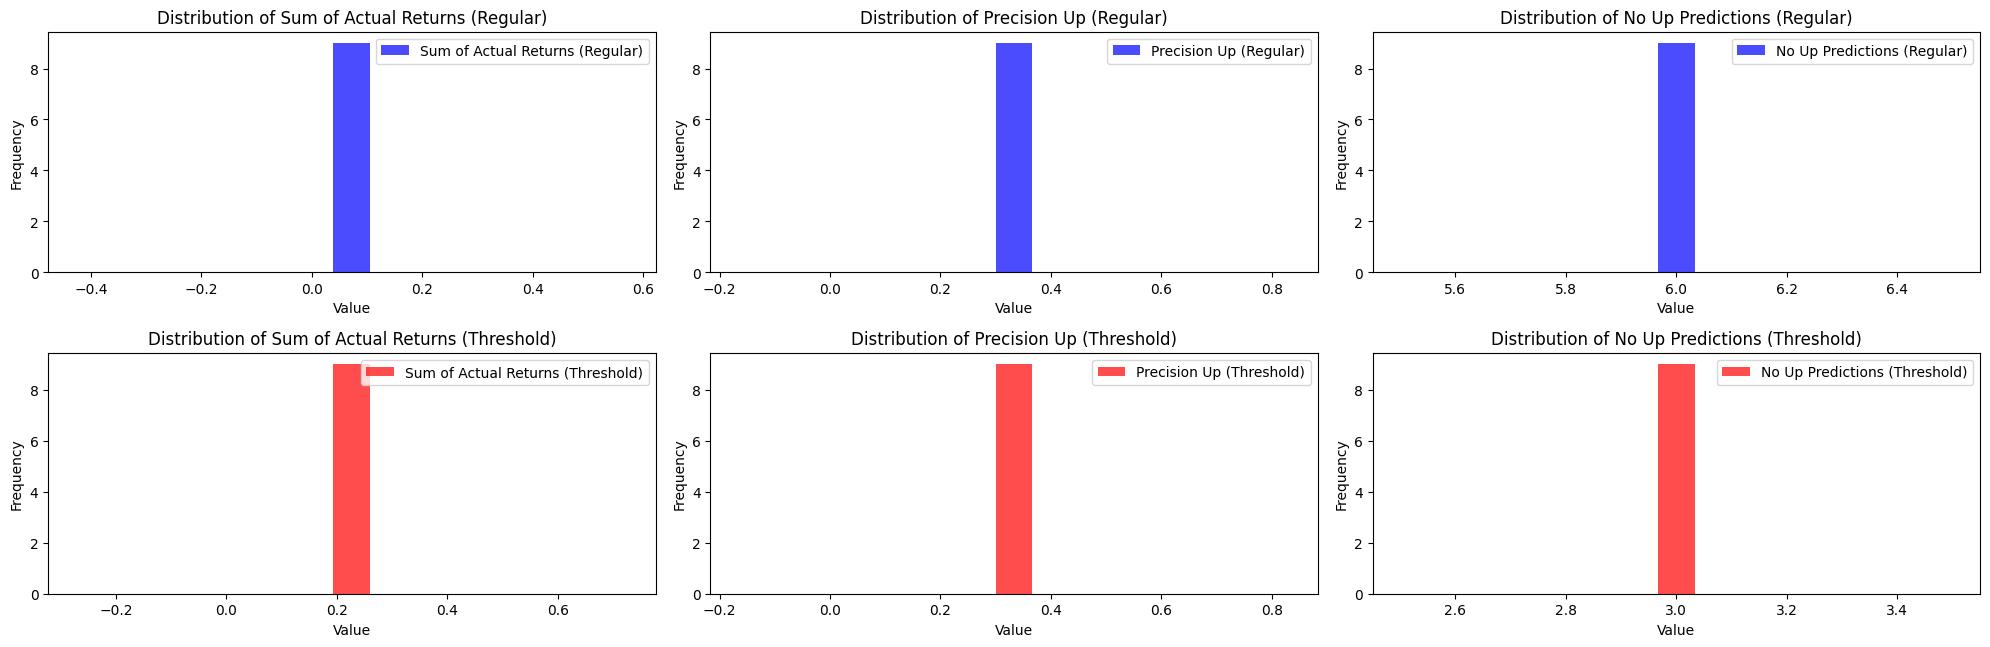

ALL Realizations Regular Unique Actuals Ups: {np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.28744769874477005), np.float64(0.15017414464249113), np.float64(-0.23493562231759657), np.float64(-0.20685732856678574)}
ALL Realizations Regular Unique Actuals Ups Sum: 0.0726993758379526
Total Unique Up Preds Regular: 6
ALL Realizations Threshold Unique Actuals Ups: {np.float64(0.06672678088367912), np.float64(0.01014370245139462), np.float64(0.15017414464249113)}
ALL Realizations Threshold Unique Actuals Ups Sum: 0.22704462797756486
Total Unique Up Preds Threshold: 3


In [ ]:
#####       PURPOSE - THIS IS JSUT FOR TESTING 





names_all = {'res_mac_L_val': res_mac_L_val, 'res_mac_H_val': res_mac_H_val, 
             'res_mac_L_test': res_mac_L_test, 'res_mac_H_test': res_mac_H_test}



# Define your groups configuration
groups_config = [
    ("mac",  (-1, 1), 2),
    # ("mac",  (0.1, 0.3), 2),
    # ("mac",  (0.3, 0.5), 2),
    # ("mac",  (-1, 1), 3),
    # ("mac",  (0.1, 0.3), 3),
    # ("mac",  (0.3, 0.5), 3)
]


number_realizations = 10

all_results_regular = []
all_results_threshold = []

# random_seeds_seed = 4
# random.seed(random_seeds_seed)


sample_size = number_realizations
seeds = random.sample(range(1, 100000), sample_size)

for i, seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = False,
                                    seed = 5,
                                    no_maps_per_group = 20,
                                    filter_outliers = False ,#### NOTICE NOTICE
                                    
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 2,

                                    

                                    )
    all_results_regular.append(results)




for i , seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = True,
                                    seed = 5,
                                    no_maps_per_group =20,
                                    filter_outliers = False , #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 1,


                                    )

    all_results_threshold.append(results)

all_groups_prec_up_regular = []
all_groups_total_return_regular = []
no_up_preds_per_group_regular = []
all_realizations_unique_actuals_ups_regular = []



        # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
        # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
        # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

for seed_res in all_results_regular:
    #first set of plots 
    all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_regular.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_regular_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_regular for item in sublist])
all_realizations_unique_actuals_ups_regular_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_regular_UNIQUE)




all_groups_prec_up_threshold = []
all_groups_total_return_threshold = []
no_up_preds_per_group_threshold = []
all_realizations_unique_actuals_ups_threshold = []


for seed_res in all_results_threshold:
    all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_threshold.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_threshold_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_threshold for item in sublist])
all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_threshold_UNIQUE)

# {'group_results': {'pair_2_neg03_01': ['None - 0 (3, 9) - 0 - Correct: 0 - []', 'None - 0 (3, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (1, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 12) - 0 - Correct: 0 - []', 'None - 0 (6, 13) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 4) - 0 - Correct: 0 - []', 'None - 0 (13, 14) - 0 - Correct: 0 - []', 'None - 0 (5, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 15) - 0 - Correct: 0 - []', 'None - 0 (14, 15) - 0 - Correct: 0 - []'], 'pair_2_neg03_01_summary':
#  ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_01_03': ['None - 0 (7, 10) - 0 - Correct: 0 - []', 'None - 0 (2, 7) - 0 - Correct: 0 - []', 'None - 0 (3, 5) - 0 - Correct: 0 - []', 'None - 0 (5, 10) - 0 - Correct: 0 - []', 'None - 0 (5, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7) - 0 - Correct: 0 - []', 'None - 0 (6, 9) - 0 - Correct: 0 - []', 'None - 0 (10, 13) - 0 - Correct: 0 - []', 'None - 0 (7, 13) - 0 - Correct: 0 - []', 'None - 0 (10, 11) - 0 - Correct: 0 - []'], 'pair_2_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_03_05': ['None - 0 (11, 13) - 0 - Correct: 0 - []', 'None - 0 (6, 12) - 0 - Correct: 0 - []', 'None - 0 (9, 13) - 0 - Correct: 0 - []', 'None - 0 (8, 15) - 0 - Correct: 0 - []', 'None - 0 (4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 11) - 0 - Correct: 0 - []', 'None - 0 (12, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 14) - 0 - Correct: 0 - []', 'None - 0 (3, 6) - 0 - Correct: 0 - []', 'None - 0 (2, 9) - 0 - Correct: 0 - []'], 'pair_2_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_neg03_01': ['None - 0 (1, 3, 7) - 0 - Correct: 0 - []', 'None - 0 (5, 6, 15) - 0 - Correct: 0 - []', 'None - 0 (1, 3, 15) - 0 - Correct: 0 - []'], 'pair_3_neg03_01_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_01_03': ['None - 0 (5, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7, 10) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 13) - 0 - Correct: 0 - []'], 'pair_3_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_03_05': ['None - 0 (1, 4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 8, 12) - 0 - Correct: 0 - []', 'None - 0 (4, 6, 8) - 0 - Correct: 0 - []', 'None - 0 (2, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (4, 7, 9) - 0 - Correct: 0 - []', 'None - 0 (4, 8, 9) - 0 - Correct: 0 - []', 'None - 0 (8, 12, 14) - 0 - Correct: 0 - []', 'None - 0 (4, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (1, 4, 8) - 0 - Correct: 0 - []', 'None - 0 (1, 6, 8) - 0 - Correct: 0 - []'], 'pair_3_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000']}, 'detailed_results': {'pair_2_neg03_01': [{'combo_numbers': (3, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 4), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (13, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (14, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_01_03': [{'combo_numbers': (7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 5), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_03_05': [{'combo_numbers': (11, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (12, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_neg03_01': [{'combo_numbers': (1, 3, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 6, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_01_03': [{'combo_numbers': (5, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_03_05': [{'combo_numbers': (1, 4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 8, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 7, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 8, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 12, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 4, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}]}, 'summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'total_metrics': {'total_ups': 0, 'total_correct_ups': 0, 'sum_actuals_ups': 0, 'precision': 0}, 'config_info': {'groups_config': [('mac', 'V', (-0.3, 0.1), 2), ('mac', 'V', (0.1, 0.3), 2), ('mac', 'V', (0.3, 0.5), 2), ('mac', 'V', (-0.3, 0.1), 3), ('mac', 'V', (0.1, 0.3), 3), ('mac', 'V', (0.3, 0.5), 3)], 'data_type_corr_groups_creation': 'V', 'data_type_ensemble': 'T', 'use_threshold_data': True, 'seed': None, 'no_maps_per_group': 10}}
import matplotlib.pyplot as plt

# List of variable names and titles
metrics = [
    
    (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
    (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
    (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

    (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
    (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
    (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),


]

plt.figure(figsize=(20, 19))

for i, (var_name, title, color) in enumerate(metrics, 1):

    plt.subplot(6, 3, i)
    data = var_name  # Get the variable by name
    plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {title}')
    plt.legend()

plt.tight_layout()
plt.show()


print("ALL Realizations Regular Unique Actuals Ups:", all_realizations_unique_actuals_ups_regular_UNIQUE)
print("ALL Realizations Regular Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_regular_UNIQUE_SUM)
print("Total Unique Up Preds Regular:", len(all_realizations_unique_actuals_ups_regular_UNIQUE))

print("ALL Realizations Threshold Unique Actuals Ups:", all_realizations_unique_actuals_ups_threshold_UNIQUE)
print("ALL Realizations Threshold Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM)
print("Total Unique Up Preds Threshold:", len(all_realizations_unique_actuals_ups_threshold_UNIQUE))

In [ ]:
results

{'group_results': {'pair_2_neg1_1': ['None - None (2, 7) - 0 - Correct: 0 - [] ',
   '0 - None (4, 10) - 2 - Correct: 0 - [np.float64(0.06672678088367912), np.float64(0.01014370245139462)] ',
   'None - 0 (5, 9) - 0 - Correct: 0 - [] ',
   'None - 0 (8, 9) - 0 - Correct: 0 - [] ',
   'None - 0 (6, 7) - 0 - Correct: 0 - [] ',
   '0.0 - 0.0 (5, 6) - 1 - Correct: 0 - [np.float64(0.06672678088367912)] ',
   'None - 0 (3, 9) - 0 - Correct: 0 - [] ',
   '0.0 - 0.0 (8, 10) - 1 - Correct: 0 - [np.float64(0.01014370245139462)] ',
   'None - 0 (0, 1) - 0 - Correct: 0 - [] ',
   '100.0 - 50.0 (2, 4) - 1 - Correct: 1 - [np.float64(0.15017414464249113)] ',
   'None - 0 (0, 9) - 0 - Correct: 0 - [] ',
   '0.0 - 0.0 (6, 10) - 1 - Correct: 0 - [np.float64(0.06672678088367912)] ',
   'None - 0 (0, 3) - 0 - Correct: 0 - [] ',
   'None - 0 (0, 7) - 0 - Correct: 0 - [] ',
   'None - 0 (0, 5) - 0 - Correct: 0 - [] ',
   'None - 0 (1, 8) - 0 - Correct: 0 - [] ',
   'None - 0 (2, 5) - 0 - Correct: 0 - [] ',


---
# Part 3 : Master df and Correlation Exploration 
---

In [ ]:
import pandas as pd
import copy

with open('/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/V_05NEG_best_models_results/results_8fold_05NEG_preds_best_models_MAC_V_2.json' , 'r') as f_json:
   res_mac_val =  json.load(f_json)

with open('/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/V_05NEG_best_models_results/results_TESTfold_05NEG_preds_best_models_MAC_V_2.json' , 'r') as f_json:
   res_mac_test =  json.load(f_json)

with open('/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/V_05NEG_best_models_results/results_8fold_05NEG_preds_best_models_GC_V_2.json' , 'r') as f_json:
   res_gc_val =  json.load(f_json)

with open('/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/V_05NEG_best_models_results/results_TESTfold_05NEG_preds_best_models_GC_V_2.json' , 'r') as f_json:
   res_gc_test =  json.load(f_json)



def flatten_results(result_list):
    """Flatten one list of results into a DataFrame without modifying the original."""
    flattened = []
    for entry in result_list:
        flat_entry = {k: v for k, v in entry.items() if k != "cv_sets"}
        flat_entry.update(entry["cv_sets"])
        flattened.append(flat_entry)
    return pd.DataFrame(flattened)

# Create new DataFrames for each result set
df_mac_val  = flatten_results(res_mac_val)
df_mac_test = flatten_results(res_mac_test)
df_gc_val   = flatten_results(res_gc_val)
df_gc_test  = flatten_results(res_gc_test)

dfs = [df_mac_val, df_mac_test, df_gc_val, df_gc_test]

### ---- number of up predictions made 
for df in dfs:
    no_up_list = []  

    for row in df["all_preds"]:

        flat_preds = [p for fold in row for p in fold]
        no_up_list.append(sum(p > 0.5 for p in flat_preds))

    df["no_up_preds"] = no_up_list


# ---- Crate a col that keeps track of the actual change when there was a false up pred 
for df in dfs:
        
    false_up_preds_col_list = []
    for row_raw_actuals, row_01_actuals , row_preds in zip(df["raw_actuals"] ,df["all_actuals"] , df["all_preds"]):
        
        false_up_preds_row = []

        row_raw_actuals_flattened = [p for fold in row_raw_actuals for p in fold ]
        row_01_actuals_flattened = [p for fold in row_01_actuals for p in fold ]
        row_preds_flattened = [p for fold in row_preds for p in fold]

        for entry_raw_actual,entry_01_actual , entry_pred in zip(row_raw_actuals_flattened , row_01_actuals_flattened,row_preds_flattened ):
            
            if entry_pred > 0.5 and entry_01_actual < 0.5:
                false_up_preds_row.append(round(entry_raw_actual,3)) 

        false_up_preds_col_list.append(false_up_preds_row)


    df["actuals_false_up"] = false_up_preds_col_list
# ---- Crate a col that keeps track of the actual change when there was a false up pred 

for df in dfs:
    df.rename(columns={"overall_metrics": "overall"}, inplace=True)

# ---- Flatten "parameters" dict column for each DataFrame ----
for df in (df_mac_val, df_mac_test, df_gc_val, df_gc_test):
    if "overall" in df.columns:
        params_df = pd.json_normalize(df["overall"])
        params_df.columns = [f"OA_{col}" for col in params_df.columns]
        df[params_df.columns] = params_df

df_gc_test.columns

dfs = [df_mac_val, df_mac_test, df_gc_val, df_gc_test]

for df in dfs:
    params_chosen = []
    for param_dict in df["parameters"]:
        param_dict_fix = {}
        for param_key in param_dict.keys():
            if param_key not in ['num_folds', 'end_value_train_set_fraction', 'val_set_fraction']:
                param_dict_fix[str(param_key)] = param_dict[param_key]

        params_chosen.append(str(param_dict_fix))
    
    df["params_fix"] = params_chosen


dict_fic_params = {}
for idx, p in enumerate(df_gc_test["params_fix"]):
    p_str = str(p).replace(' ','').replace("'",'').replace('  ','')
    dict_fic_params[p_str] = idx


for df in (df_mac_val, df_mac_test, df_gc_val, df_gc_test):
    param_values = []
    for p in df["params_fix"]:
        p_str = str(p).replace(' ','').replace("'",'')

        param_values.append(dict_fic_params[p_str])
    df["param_int_value"] = param_values


# Append suffix based on variable name
df_mac_val.rename(columns=lambda x: f"{x}_mac_val" if x != "params_fix" else x, inplace=True)
df_mac_test.rename(columns=lambda x: f"{x}_mac_test" if x != "params_fix" else x, inplace=True)
df_gc_val.rename(columns=lambda x: f"{x}_gc_val" if x != "params_fix" else x, inplace=True)
df_gc_test.rename(columns=lambda x: f"{x}_gc_test" if x != "params_fix" else x, inplace=True)


master_df = (
    df_mac_val
    .merge(df_mac_test, on="params_fix", how="outer")
    .merge(df_gc_val, on="params_fix", how="outer")
    .merge(df_gc_test, on="params_fix", how="outer")
)


master_df.columns = (
    master_df.columns
      .str.replace('precision', 'prec')
      .str.replace('recall', 'rec')
      .str.replace('down', '0')
      .str.replace('up', '1')
      .str.replace('accuracy', 'acc')
      .str.replace('test', 'T')
      .str.replace('val', 'V')

)

master_df.columns

Index(['combo_number_mac_V', 'parameters_mac_V', 'all_preds_mac_V',
       'all_actuals_mac_V', 'raw_actuals_mac_V', 'set_1_mac_V', 'set_2_mac_V',
       'set_3_mac_V', 'set_4_mac_V', 'set_5_mac_V', 'set_6_mac_V',
       'set_7_mac_V', 'set_8_mac_V', 'avg_across_all_sets_mac_V',
       'overall_mac_V', 'no_1_preds_mac_V', 'actuals_false_1_mac_V',
       'OA_acc_mac_V', 'OA_prec_1_mac_V', 'OA_rec_1_mac_V', 'OA_prec_0_mac_V',
       'OA_rec_0_mac_V', 'params_fix', 'param_int_Vue_mac_V',
       'combo_number_mac_T', 'parameters_mac_T', 'all_preds_mac_T',
       'all_actuals_mac_T', 'raw_actuals_mac_T', 'set_1_mac_T', 'set_2_mac_T',
       'set_3_mac_T', 'set_4_mac_T', 'avg_across_all_sets_mac_T',
       'overall_mac_T', 'no_1_preds_mac_T', 'actuals_false_1_mac_T',
       'OA_acc_mac_T', 'OA_prec_1_mac_T', 'OA_rec_1_mac_T', 'OA_prec_0_mac_T',
       'OA_rec_0_mac_T', 'param_int_Vue_mac_T', 'combo_number_gc_V',
       'parameters_gc_V', 'all_preds_gc_V', 'all_actuals_gc_V',
       'raw_actu

In [ ]:
# master_df.columns =  (master_df.columns.str.replace('_', '\n'))


master_df[ ["OA_prec_1_gc_V" , "OA_rec_1_gc_V" , "no_1_preds_gc_V" , "actuals_false_1_gc_V" 
            
            ,"OA_prec_1_gc_T" , "OA_rec_1_gc_T" , "no_1_preds_gc_T", "actuals_false_1_gc_T" ,

            "OA_prec_1_mac_V" ,"OA_rec_1_mac_V"  ,  "no_1_preds_mac_V", "actuals_false_1_mac_V" ,
            
            "OA_prec_1_mac_T" ,"OA_rec_1_mac_T"  ,  "no_1_preds_mac_T", "actuals_false_1_mac_T" ,   ]
            
            ].round(2)

,OA_prec_1_gc_V,OA_rec_1_gc_V,no_1_preds_gc_V,actuals_false_1_gc_V,OA_prec_1_gc_T,OA_rec_1_gc_T,no_1_preds_gc_T,actuals_false_1_gc_T,OA_prec_1_mac_V,OA_rec_1_mac_V,no_1_preds_mac_V,actuals_false_1_mac_V,OA_prec_1_mac_T,OA_rec_1_mac_T,no_1_preds_mac_T,actuals_false_1_mac_T
0,100.00,25.0,2,[],25.00,20.0,4,"[-0.022, 0.233, 0.102]",40.00,25.0,5,"[0.147, 0.037, 0.1]",NaN,0.0,0,[]
1,100.00,37.5,3,[],66.67,80.0,6,"[0.233, 0.097]",0.00,0.0,1,[0.19],50.00,60.0,6,"[-0.022, 0.102, 0.097]"
2,100.00,25.0,2,[],0.00,0.0,1,[-0.049],66.67,25.0,3,[0.055],0.00,0.0,2,"[-0.022, -0.049]"
3,100.00,25.0,2,[],0.00,0.0,3,"[0.143, 0.233, 0.102]",50.00,12.5,2,[0.147],25.00,20.0,4,"[0.143, 0.06, 0.102]"
4,100.00,25.0,2,[],NaN,0.0,0,[],100.00,50.0,4,[],100.00,40.0,2,[]
5,100.00,25.0,2,[],100.00,20.0,1,[],100.00,37.5,3,[],100.00,40.0,2,[]
6,100.00,25.0,2,[],100.00,20.0,1,[],100.00,37.5,3,[],100.00,40.0,2,[]
7,80.00,50.0,5,[0.055],33.33,60.0,9,"[-0.022, 0.143, 0.06, 0.102, -0.049, 0.097]",33.33,25.0,6,"[0.055, 0.186, 0.059, 0.046]",44.44,80.0,9,"[0.143, 0.06, 0.102, -0.049, 0.097]"
8,100.00,25.0,2,[],0.00,0.0,3,"[0.143, 0.06, 0.102]",NaN,0.0,0,[],100.00,20.0,1,[]
9,100.00,25.0,2,[],NaN,0.0,0,[],100.00,12.5,1,[],NaN,0.0,0,[]


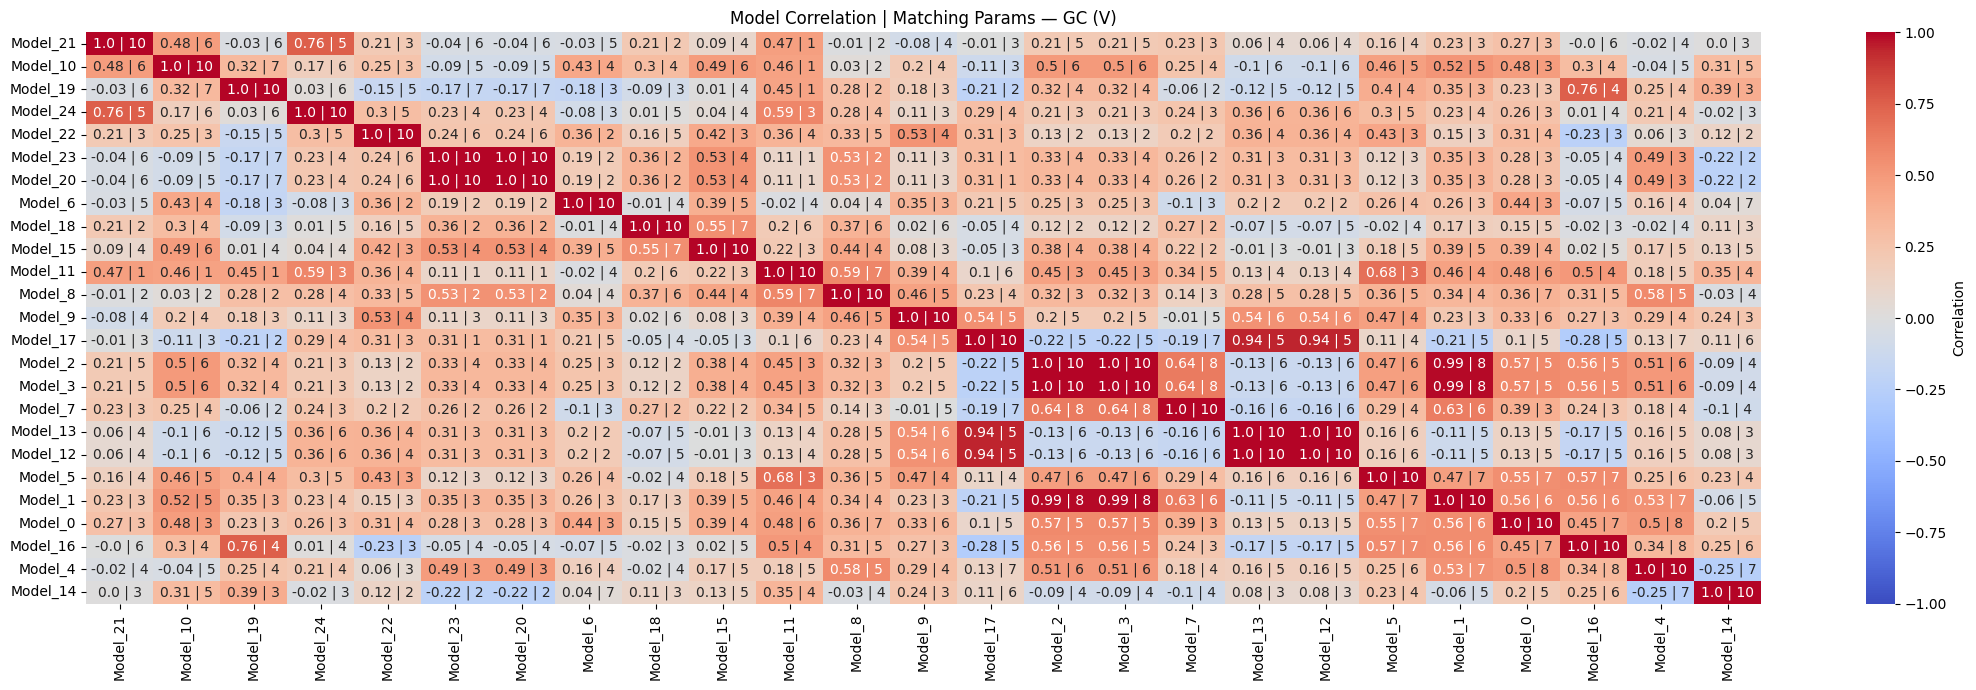

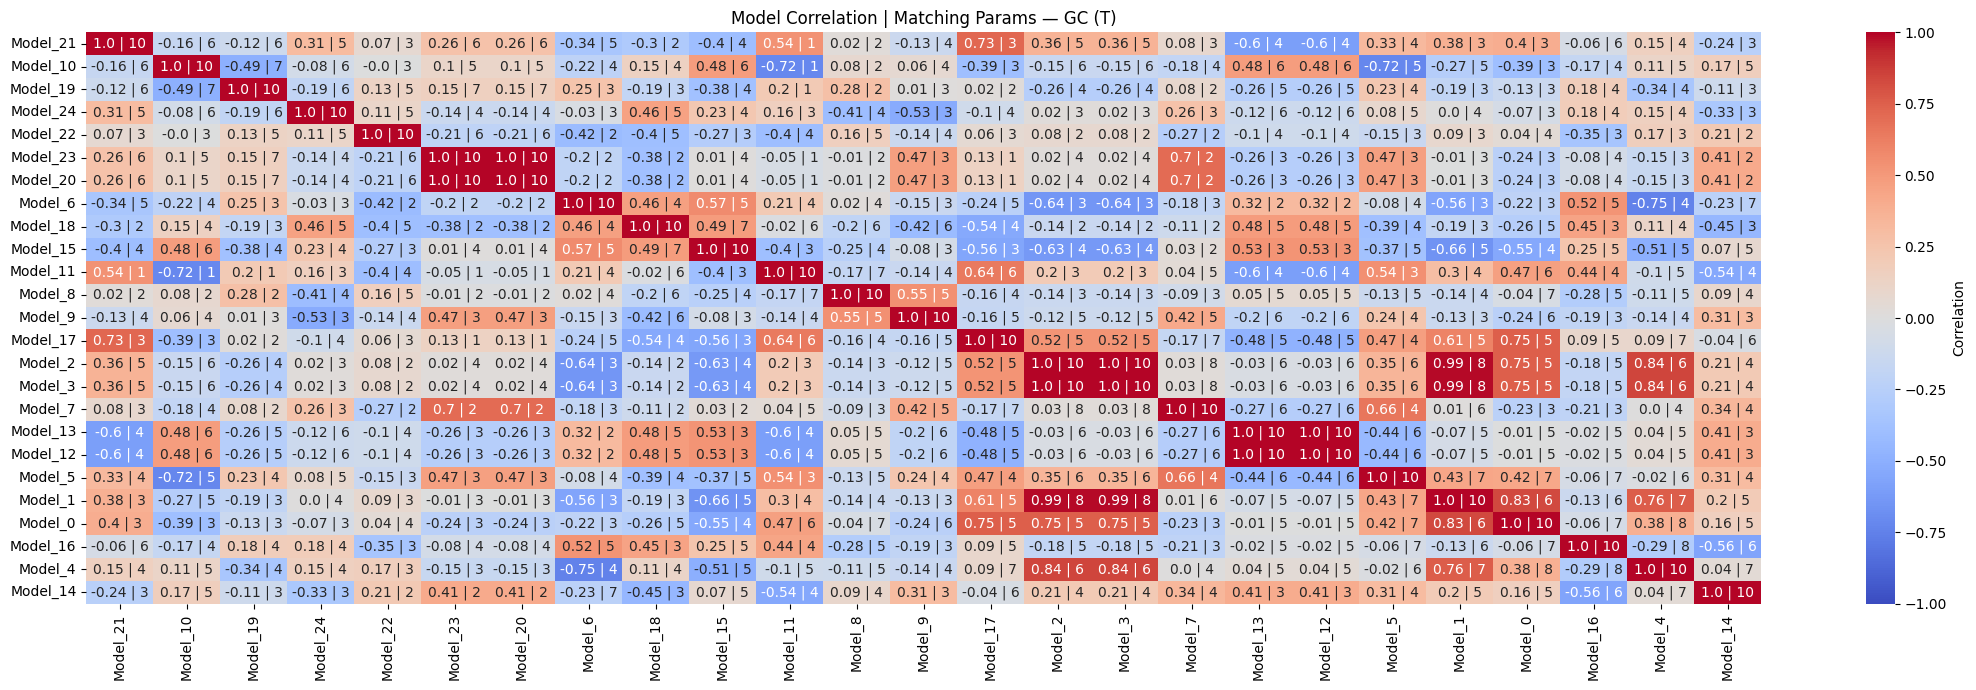

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_model_corr(master_df, machine="mac", set_type="V"):
    """
    Plots correlation and matching-parameter counts for models
    from a given machine ('mac' or 'gc') and set type ('V' or 'T'),
    using the param_int_Vue column as the unique model ID.
    """
    # Dynamic column names
    preds_col  = f"all_preds_{machine}_{set_type}"
    params_col = f"parameters_{machine}_{set_type}"
    id_col     = f"param_int_Vue_{machine}_{set_type}"  # unique model integer

    # Extract relevant rows
    block = master_df[[preds_col, params_col, id_col]].reset_index(drop=True)
    if block.empty:
        raise ValueError(f"No data found for machine '{machine}' and set '{set_type}'.")

    # 1. Flatten predictions
    all_preds_list = []
    for preds in block[preds_col]:
        flat = [p for fold in preds for p in fold]  # flatten folds
        all_preds_list.append(flat)

    labels = [f"Model_{int(mid)}" for mid in block[id_col]]

    # 2. Correlation matrix
    corr = np.corrcoef(all_preds_list)
    corr_df = pd.DataFrame(corr, index=labels, columns=labels)

    # 3. Matching parameter counts
    keys_to_check = [
        "learning_rate", "num_epochs", "batch_size", "lag",
        "num_layers", "input_size", "use_rolling_fixed_train_size",
        "hidden_size", "use_class_weighting", "use_dropout"
    ]
    params_list = block[params_col].tolist()
    n = len(params_list)
    match_counts = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            p1, p2 = params_list[i], params_list[j]
            if not isinstance(p1, dict) or not isinstance(p2, dict):
                continue
            match_counts[i, j] = sum(p1.get(k) == p2.get(k) for k in keys_to_check)

    match_df = pd.DataFrame(match_counts, index=labels, columns=labels)

    # 4. Annotated heatmap
    annot = corr_df.round(2).astype(str) + " | " + match_df.astype(str)

    plt.figure(figsize=(22, 7))
    sns.heatmap(
        corr_df,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        cbar_kws={'label': 'Correlation'}
    )
    plt.title(f"Model Correlation | Matching Params — {machine.upper()} ({set_type})")
    plt.tight_layout()
    plt.show()


# Example usage:
plot_model_corr(master_df, machine="gc", set_type="V")
# plot_model_corr(master_df, machine="mac", set_type="T")
plot_model_corr(master_df, machine="gc", set_type="T")


In [ ]:
import numpy as np
from itertools import combinations
from collections import Counter

def get_model_groups_in_corr_range(master_df, machine, set_type, corr_range, group_size=2):
    """
    Find groups of models (size=group_size) whose pairwise correlations
    of predictions fall within [low, high).

    Args:
        master_df (pd.DataFrame): your merged DF.
        machine (str): 'mac' or 'gc'.
        set_type (str): 'V' or 'T'.
        corr_range (tuple): (low, high) inclusive/exclusive as [low, high).
        group_size (int): number of models per group (>=2).

    Returns:
        list[tuple]: list of tuples of model IDs (param_int_Vue_...) meeting the criterion.
    """
    assert group_size >= 2, "group_size must be >= 2"

    preds_col = f"all_preds_{machine}_{set_type}"
    id_col    = f"param_int_Vue_{machine}_{set_type}"

    # Keep only rows with predictions and an ID
    block = master_df.loc[master_df[preds_col].notna() & master_df[id_col].notna(), [id_col, preds_col]]

    # Flatten predictions per model id
    preds_by_id = {}
    for _, row in block.iterrows():
        mid = int(row[id_col])
        flat = [p for fold in row[preds_col] for p in fold]
        preds_by_id[mid] = np.asarray(flat, dtype=float)

    if not preds_by_id:
        return []

    # Handle potential unequal lengths robustly:
    lengths = [len(v) for v in preds_by_id.values()]
    modal_len = Counter(lengths).most_common(1)[0][0]
    # Keep only models with the modal length to ensure comparable correlations
    preds_by_id = {k: v for k, v in preds_by_id.items() if len(v) == modal_len}

    model_ids = sorted(preds_by_id.keys())
    if len(model_ids) < group_size:
        return []

    # Build data matrix (n_models, n_samples)
    data = np.vstack([preds_by_id[mid] for mid in model_ids])

    # Correlation matrix
    corr = np.corrcoef(data)

    low, high = corr_range

    groups = []
    idx_map = {i: mid for i, mid in enumerate(model_ids)}

    # Fast path for pairs
    if group_size == 2:
        for i in range(len(model_ids)):
            for j in range(i+1, len(model_ids)):
                c = corr[i, j]
                if not np.isnan(c) and (low <= c < high):
                    groups.append((idx_map[i], idx_map[j]))
        return groups

    # For k >= 3: check all combinations are within range
    for combo in combinations(range(len(model_ids)), group_size):
        ok = True
        for a, b in combinations(combo, 2):
            c = corr[a, b]
            if np.isnan(c) or not (low <= c < high):
                ok = False
                break
        if ok:
            groups.append(tuple(idx_map[i] for i in combo))

    return groups



In [ ]:
#                                               VAL SET MAC 

import random


n_random = 10

#  ----------------- Groups of size 2

groups_2_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=2) ; rand_groups_2_neg01_00 = random.sample(groups_2_neg01_00, n_random)
groups_2_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=2) ; rand_groups_2_00_02 = random.sample(groups_2_00_02, n_random)
groups_2_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=2) ; rand_groups_2_02_04 = random.sample(groups_2_02_04, n_random)
groups_2_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=2) ; rand_groups_2_04_07 = random.sample(groups_2_04_07, n_random)

# ------------------ Groups of size 3

# groups_3_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=3)
groups_3_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=3) ; rand_groups_3_00_02 = random.sample(groups_3_00_02, n_random)
groups_3_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=3) ; rand_groups_3_02_04 = random.sample(groups_3_02_04, n_random)
# groups_3_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=3)

# ------------------ Groups of size 4

# groups_4_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=4)
# groups_4_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=4) ; rand_groups_4_00_02 = random.sample(groups_4_00_02, n_random)
# groups_4_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=4)
# groups_4_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=4)


# ------------------- CHECK 

print(len(groups_2_neg01_00))
print(len(groups_2_00_02))
print(len(groups_2_02_04))
print(len(groups_2_04_07))
print('----')
# print(len(groups_3_neg01_00))
print(len(groups_3_00_02))
print(len(groups_3_02_04))
# print(len(groups_3_04_07))
print('----')
# print(len(groups_4_neg01_00))
# print(len(groups_4_00_02))
# print(len(groups_4_02_04))
# print(len(groups_4_04_07))


#                                               VAL SET MAC 

# -------- Size 2 --------
pair_params_map_2_neg01_00 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_2_neg01_00
}

pair_params_map_2_00_02 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_2_00_02
}

pair_params_map_2_02_04 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_2_02_04
}

pair_params_map_2_04_07 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_2_04_07
}

# -------- Size 3 --------
pair_params_map_3_00_02 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[2], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_3_00_02
}

pair_params_map_3_02_04 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_mac_V"] == pair[2], "parameters_mac_V"].iloc[0]
    ]
    for pair in rand_groups_3_02_04
}

# # -------- Size 4 --------
# pair_params_map_4_00_02 = {
#     pair: [
#         master_df.loc[master_df["param_int_Vue_mac_V"] == pair[0], "parameters_mac_V"].iloc[0],
#         master_df.loc[master_df["param_int_Vue_mac_V"] == pair[1], "parameters_mac_V"].iloc[0],
#         master_df.loc[master_df["param_int_Vue_mac_V"] == pair[2], "parameters_mac_V"].iloc[0],
#         master_df.loc[master_df["param_int_Vue_mac_V"] == pair[3], "parameters_mac_V"].iloc[0]
#     ]
#     for pair in rand_groups_4_00_02
# }



#               SELECTIVE_ENSEMBLE_ALL_AGREE VAL SET VAL SET VAL SET VAL SET 

import pickle

ensemble_config = {
    "pair_params_map_2_neg01_00": pair_params_map_2_neg01_00,
    "pair_params_map_2_00_02": pair_params_map_2_00_02,
    "pair_params_map_2_02_04": pair_params_map_2_02_04,
    "pair_params_map_2_04_07": pair_params_map_2_04_07,
    "pair_params_map_3_00_02": pair_params_map_3_00_02,
    "pair_params_map_3_02_04": pair_params_map_3_02_04,
    # "pair_params_map_4_00_02": pair_params_map_4_00_02
}





38
96
65
18
----
72
28
----


In [ ]:
from Results_Dists_V_2 import *


In [ ]:
# Create pair parameter maps using the function
pair_params_map_2_neg01_00 = create_pair_params_map(rand_groups_2_neg01_00, master_df, num_models=2, data_type="V")
pair_params_map_2_00_02 = create_pair_params_map(rand_groups_2_00_02, master_df, num_models=2, data_type="V")
pair_params_map_2_02_04 = create_pair_params_map(rand_groups_2_02_04, master_df, num_models=2, data_type="V")
pair_params_map_2_04_07 = create_pair_params_map(rand_groups_2_04_07, master_df, num_models=2, data_type="V")


pair_params_map_3_00_02 = create_pair_params_map(rand_groups_3_00_02, master_df, num_models=3, data_type="V")
pair_params_map_3_02_04 = create_pair_params_map(rand_groups_3_02_04, master_df, num_models=3, data_type="V")



before set: [-0.022367913613575152, -0.051506024096385494, -0.04850943729052748, -0.10390349379765573, -0.1523234889382873, -0.022367913613575152, -0.1523234889382873, -0.022367913613575152, 0.09727772227772236, -0.10390349379765573, -0.022367913613575152, -0.1523234889382873, -0.022367913613575152, -0.022367913613575152, -0.1523234889382873, -0.1523234889382873, -0.022367913613575152, -0.1523234889382873, -0.051506024096385494, -0.022367913613575152, -0.1523234889382873, -0.022367913613575152, -0.022367913613575152, -0.1523234889382873, -0.022367913613575152, -0.022367913613575152, -0.10390349379765573, -0.022367913613575152, -0.022367913613575152]
after set: {-0.022367913613575152, -0.051506024096385494, -0.1523234889382873, -0.04850943729052748, -0.10390349379765573, 0.09727772227772236}
before set: [-0.04850943729052748, -0.1523234889382873, -0.051506024096385494, -0.022367913613575152, -0.0953469962177852, -0.022367913613575152, -0.022367913613575152, -0.022367913613575152, -0.152

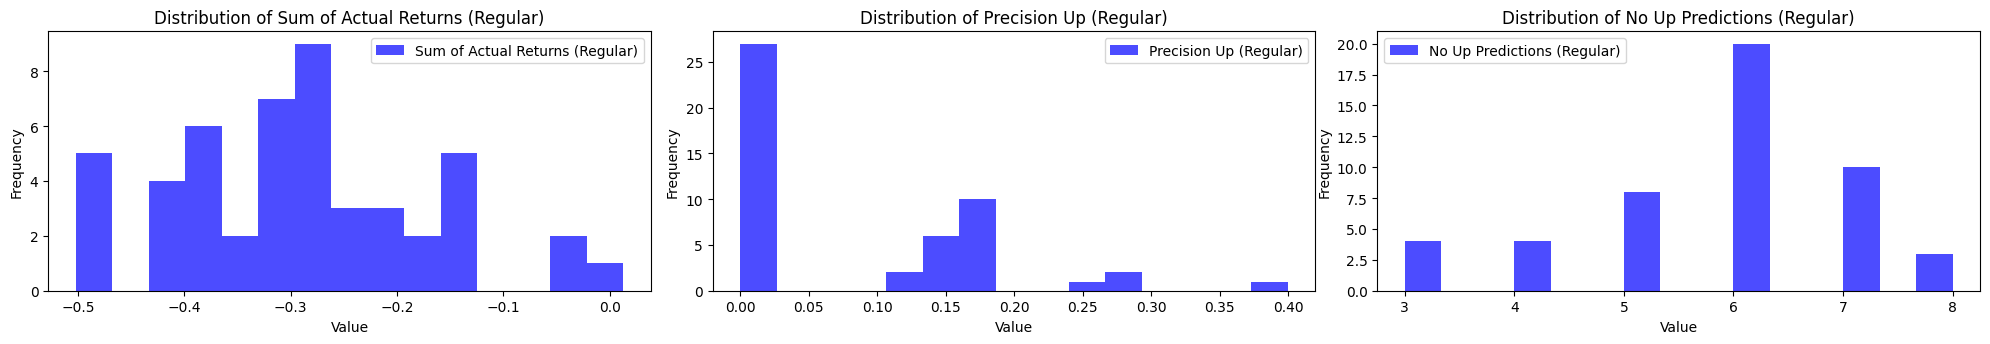

In [ ]:
groups_2_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=2) ; rand_groups_2_neg01_00 = random.sample(groups_2_neg01_00, n_random)
groups_2_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=2) ; rand_groups_2_00_02 = random.sample(groups_2_00_02, n_random)
groups_2_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=2) ; rand_groups_2_02_04 = random.sample(groups_2_02_04, n_random)
groups_2_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=2) ; rand_groups_2_04_07 = random.sample(groups_2_04_07, n_random)

# ------------------ Groups of size 3

# groups_3_neg01_00 = get_model_groups_in_corr_range(master_df, "mac", "V", (-0.1, 0.0), group_size=3)
groups_3_00_02    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.0, 0.2), group_size=3) ; rand_groups_3_00_02 = random.sample(groups_3_00_02, n_random)
groups_3_02_04    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.2, 0.4), group_size=3) ; rand_groups_3_02_04 = random.sample(groups_3_02_04, n_random)
# groups_3_04_07    = get_model_groups_in_corr_range(master_df, "mac", "V", (0.4, 0.7), group_size=3)


# Define your groups configuration
groups_config = [
    ("mac", (-0.1, 0.0), 2),
    ("mac", (0.0, 0.2), 2),
    ("mac", (0.2, 0.4), 2),
    ("mac", (0.4, 0.7), 2),

    ("mac", (0.0, 0.2), 3),
    ("mac", (0.2, 0.4), 3)
]


number_realizations = 50

all_results_regular = []


# random_seeds_seed = 444
# random.seed(random_seeds_seed)


sample_size = number_realizations
seeds = random.sample(range(1, 100000), sample_size)

for i, seed_ in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics(
    master_df=master_df,
    groups_config=groups_config,
    data_type_corr_groups_creation="V",
    data_type_ensemble="T",
    use_threshold_data=False,
    seed=None,
    no_maps_per_group=10 , filter_outliers=True)

    all_results_regular.append(results)

all_groups_prec_up_regular = []
all_groups_total_return_regular = []
no_up_preds_per_group_regular = []



        # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
        # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
        # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

for seed_res in all_results_regular:
    #first set of plots 
    all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])

    


import matplotlib.pyplot as plt

# List of variable names and titles
metrics = [

    (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
    (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
    (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

    # (HOD_all_groups_total_return_regular, 'HOD Sum', 'green'),
    # (UCO_all_groups_total_return_regular, 'UCO Sum', 'orange'),
    # (HUC_all_groups_total_return_regular, 'HUC Sum', 'red'),
    # (CRUD_all_groups_total_return_regular, 'CRUD Sum', 'purple'),
    # (USO_all_groups_total_return_regular, 'USO Sum', 'brown'),

    # (HOD_all_groups_total_return_threshold, 'HOD Sum', 'green'),
    # (UCO_all_groups_total_return_threshold, 'UCO Sum', 'orange'),
    # (HUC_all_groups_total_return_threshold, 'HUC Sum', 'red'),
    # (CRUD_all_groups_total_return_threshold, 'CRUD Sum', 'purple'),
    # (USO_all_groups_total_return_threshold, 'USO Sum', 'brown'),

]

plt.figure(figsize=(20, 19))

for i, (var_name, title, color) in enumerate(metrics, 1):
    plt.subplot(6, 3, i)
    data = var_name  # Get the variable by name
    plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {title}')
    plt.legend()

plt.tight_layout()
plt.show()






In [ ]:
#                                               VAL SET GC 
#                                               VAL SET GC 


import random

random.seed(42)


n_random = 10

#  ----------------- Groups of size 2

groups_2_neg01_00 = get_model_groups_in_corr_range(master_df, "gc", "V", (-0.1, 0.0), group_size=2) 
groups_2_00_02    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.0, 0.2), group_size=2) 
groups_2_02_04    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.2, 0.4), group_size=2) 
groups_2_04_07    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.4, 0.7), group_size=2) 

# ------------------ Groups of size 3

# groups_3_neg01_00 = get_model_groups_in_corr_range(master_df, "gc", "V", (-0.1, 0.0), group_size=3)
groups_3_00_02    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.0, 0.2), group_size=3) 
groups_3_02_04    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.2, 0.4), group_size=3) 
groups_3_04_07    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.4, 0.7), group_size=3)

# ------------------ Groups of size 4

# groups_4_neg01_00 = get_model_groups_in_corr_range(master_df, "gc", "V", (-0.1, 0.0), group_size=4)
# groups_4_00_02    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.0, 0.2), group_size=4) 
groups_4_02_04    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.2, 0.4), group_size=4)
groups_4_04_07    = get_model_groups_in_corr_range(master_df, "gc", "V", (0.4, 0.7), group_size=4)

# Random sampling for non-commented groups
rand_groups_2_neg01_00 = random.sample(groups_2_neg01_00, 10)
rand_groups_2_00_02 = random.sample(groups_2_00_02, 10)
rand_groups_2_02_04 = random.sample(groups_2_02_04, 10)
rand_groups_2_04_07 = random.sample(groups_2_04_07, 10)
rand_groups_3_00_02 = random.sample(groups_3_00_02, 10)
rand_groups_3_02_04 = random.sample(groups_3_02_04, 10)
rand_groups_3_04_07 = random.sample(groups_3_04_07, 10)
rand_groups_4_02_04 = random.sample(groups_4_02_04, 10)
rand_groups_4_04_07 = random.sample(groups_4_04_07, 10)



# ------------------- CHECK 

print(len(groups_2_neg01_00))
print(len(groups_2_00_02))
print(len(groups_2_02_04))
print(len(groups_2_04_07))
print('----')
# print(len(groups_3_neg01_00))
print(len(groups_3_00_02))
print(len(groups_3_02_04))
print(len(groups_3_04_07))
print('----')
# print(len(groups_4_neg01_00))
# print(len(groups_4_00_02))
print(len(groups_4_02_04))
print(len(groups_4_04_07))




# -------- Size 2 --------
pair_params_map_2_neg01_00 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_2_neg01_00
}

pair_params_map_2_00_02 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_2_00_02
}

pair_params_map_2_02_04 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_2_02_04
}

pair_params_map_2_04_07 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_2_04_07
}

# -------- Size 3 --------
pair_params_map_3_00_02 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[2], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_3_00_02
}

pair_params_map_3_02_04 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[2], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_3_02_04
}

pair_params_map_3_04_07 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[2], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_3_04_07
}

# -------- Size 4 --------
pair_params_map_4_02_04 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[2], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[3], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_4_02_04
}

pair_params_map_4_04_07 = {
    pair: [
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[0], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[1], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[2], "parameters_gc_V"].iloc[0],
        master_df.loc[master_df["param_int_Vue_gc_V"] == pair[3], "parameters_gc_V"].iloc[0]
    ]
    for pair in rand_groups_4_04_07
}






38
67
102
56
----
30
76
44
----
15
23


In [ ]:
pair_variables_list = [
    pair_params_map_2_neg01_00,
    pair_params_map_2_00_02,
    pair_params_map_2_02_04,
    pair_params_map_2_04_07,
    pair_params_map_3_00_02,
    pair_params_map_3_02_04,
    pair_params_map_3_04_07,
    pair_params_map_4_02_04,
    pair_params_map_4_04_07
]


for pair_params in pair_variables_list:

    for list in pair_params.values():

        for params in list:

            params["val_set_fraction"] = 0.05
            params["num_folds"] = 4
            params["end_value_train_set_fraction"] = 0.95




all_pair_maps = {
    'pair_params_map_2_neg01_00' : pair_params_map_2_neg01_00 ,
    'pair_params_map_2_00_02' : pair_params_map_2_00_02 ,
    'pair_params_map_2_02_04' : pair_params_map_2_02_04 ,
    'pair_params_map_2_04_07' : pair_params_map_2_04_07 ,
    'pair_params_map_3_00_02' : pair_params_map_3_00_02 ,
    'pair_params_map_3_02_04' : pair_params_map_3_02_04 ,
    'pair_params_map_3_04_07' : pair_params_map_3_04_07 ,
    'pair_params_map_4_02_04' : pair_params_map_4_02_04 , 
    'pair_params_map_4_04_07' : pair_params_map_4_04_07
}

# Save to pickle
with open("pair_params_maps_gc_T.pkl", "wb") as f:
    pickle.dump(all_pair_maps, f)

print("✅ Saved all pair maps to pair_params_maps.pkl")



✅ Saved all pair maps to pair_params_maps.pkl


---
# Part 3 : Analysis
---

In [ ]:
import json 

all_pair_maps = [
    "pair_params_map_2_neg01_00",
    "pair_params_map_2_00_02" ,
    "pair_params_map_2_02_04" ,
    "pair_params_map_2_04_07",
    "pair_params_map_3_00_02" ,
    "pair_params_map_3_02_04" ,
    "pair_params_map_4_00_02" 
]


corr_res_MAC_V = []

for name in all_pair_maps:
    with open(f'/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/Top 25 GS Models V_1 Ensemble Results/results_MAC_Vset_pair_params/results_MAC_Vset_{name}.json') as file:
        data = json.load(file)
        corr_res_MAC_V.append(data)

# for i in corr_res_MAC_V:
#     print(i)

for i in corr_res_MAC_V[:len(corr_res_MAC_V) ]:
    print('-----')
    for j in i:
        
        print(j["cv_sets"]["overall_metrics"]["precision_up"] , '-' ,j["cv_sets"]["overall_metrics"]["recall_up"] ,j["combo_numbers"])


# corr_res_MAC_V


-----
0.0 - 0.0 [6, 19]
0.0 - 0.0 [6, 11]
None - 0 [11, 18]
None - 0 [12, 22]
100.0 - 20.0 [0, 14]
None - 0 [5, 10]
None - 0 [11, 17]
100.0 - 50.0 [3, 8]
None - 0 [13, 22]
0.0 - 0.0 [5, 6]
-----
None - 0 [3, 15]
100.0 - 16.666666666666664 [14, 21]
None - 0 [3, 12]
100.0 - 28.57142857142857 [0, 16]
100.0 - 25.0 [3, 4]
100.0 - 16.666666666666664 [15, 23]
None - 0 [13, 16]
100.0 - 40.0 [2, 19]
None - 0 [9, 13]
100.0 - 40.0 [1, 5]
-----
100.0 - 40.0 [2, 11]
50.0 - 16.666666666666664 [0, 4]
None - 0 [13, 21]
None - 0 [12, 19]
66.66666666666666 - 40.0 [2, 16]
100.0 - 33.33333333333333 [8, 23]
100.0 - 28.57142857142857 [5, 7]
None - 0 [11, 15]
100.0 - 20.0 [6, 23]
0.0 - 0.0 [5, 24]
-----
50.0 - 28.57142857142857 [0, 5]
66.66666666666666 - 28.57142857142857 [0, 11]
100.0 - 28.57142857142857 [7, 16]
50.0 - 14.285714285714285 [4, 19]
66.66666666666666 - 25.0 [5, 11]
66.66666666666666 - 28.57142857142857 [0, 19]
50.0 - 16.666666666666664 [9, 19]
75.0 - 50.0 [3, 7]
None - 0 [10, 15]
75.0 - 50.0 [2

In [ ]:
import json 


all_pair_maps = [
    'pair_params_map_2_neg01_00',
    'pair_params_map_2_00_02',
    'pair_params_map_2_02_04',
    'pair_params_map_2_04_07',
    'pair_params_map_3_00_02',
    'pair_params_map_3_02_04',
    'pair_params_map_3_04_07',
    'pair_params_map_4_02_04',
    'pair_params_map_4_04_07'
]

corr_res_MAC_V = []

for name in all_pair_maps:
    with open(f'/Users/cs/Desktop/Top_25_GS_Ensemble_Results/results_GC_Tset_pair_params/results_GC_Tset_{name}.json') as file:
        data = json.load(file)
        corr_res_MAC_V.append(data)

# for i in corr_res_MAC_V:
#     print(i)

for i in corr_res_MAC_V[:len(corr_res_MAC_V) ]:
    print('-----')
    for j in i:
        
        print(j["cv_sets"]["overall_metrics"]["precision_up"] , '-' ,j["cv_sets"]["overall_metrics"]["recall_up"] ,j["combo_numbers"])


# corr_res_MAC_V


FileNotFoundError: [Errno 2] No such file or directory: '/Users/cs/Desktop/Top_25_GS_Ensemble_Results/results_GC_Tset_pair_params/results_GC_Tset_pair_params_map_2_neg01_00.json'

In [ ]:
import json 



with open(f'/Users/cs/Desktop/Top_25_GS_Ensemble_Results/results_MAC_Tset_pair_params_ALL.json') as file:
    data = json.load(file)

import numpy as np 
# for i in corr_res_MAC_V:
#     print(i)


for i in data:

    print('-----')
    for j in i:


        flatten_preds = [j for part in j["all_preds"] for j in part]
        flatten_raw_actuals = [j for part in j["raw_actuals"] for j in part]

        p_ups = sum(i > .5 for i in flatten_preds if isinstance(i,int))

        # up_vals_predicted = [j for part in j["all_actuals"] for j in part if not isinstance(j , str) and j > 0.5 ]

        up_vals_predicted_raw_val = []
        for p,a in zip(flatten_preds , flatten_raw_actuals):
            if not isinstance(p , str ) and p > 0.5:
                up_vals_predicted_raw_val.append(a)


        
        print(j["cv_sets"]["overall_metrics"]["precision_up"] , '-' ,j["cv_sets"]["overall_metrics"]["recall_up"] 
              ,j["combo_numbers"], '-', p_ups , '-' , up_vals_predicted_raw_val)





-----
None - 0 [13, 22] - 0 - []
100.0 - 33.33333333333333 [10, 18] - 1 - [-0.10390349379765573]
100.0 - 50.0 [3, 6] - 1 - [-0.1523234889382873]
None - 0 [4, 24] - 0 - []
None - 0 [11, 17] - 0 - []
None - 0 [6, 8] - 0 - []
0.0 - 0.0 [16, 19] - 1 - [-0.022367913613575152]
None - 0 [8, 21] - 0 - []
None - 0 [16, 23] - 0 - []
100.0 - 33.33333333333333 [0, 22] - 1 - [-0.1523234889382873]
-----
None - 0 [12, 16] - 0 - []
50.0 - 25.0 [0, 24] - 2 - [0.14319526627218937, -0.1523234889382873]
50.0 - 25.0 [0, 16] - 2 - [-0.022367913613575152, -0.1523234889382873]
None - 0 [4, 5] - 0 - []
None - 0 [2, 4] - 0 - []
100.0 - 66.66666666666666 [6, 22] - 2 - [-0.07675194660734153, -0.1523234889382873]
None - 0 [11, 14] - 0 - []
None - 0 [5, 13] - 0 - []
50.0 - 33.33333333333333 [10, 24] - 2 - [0.10238210986874097, -0.1523234889382873]
None - 0 [3, 23] - 0 - []
-----
None - 0 [0, 15] - 0 - []
100.0 - 20.0 [4, 18] - 1 - [-0.10390349379765573]
50.0 - 25.0 [9, 11] - 2 - [-0.022367913613575152, -0.095346996

---
# Part 4: GS Best Results Distribution Discovery 
---

In [ ]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn




from Equations_Run_Combo_V_2 import (


    run_combo,
    LSTM,
    TimeSeriesDataset,
    format_to_tensor,
    train_one_epoch,
    validate_one_epoch,
    evaluate_binary_0_1,
    evaluate_signed_neg1_1 ,
)


from Equations_Ensembles_Dist import (

    evaluate_binary_0_1_selective_ensemble , distribution_discovery , avg_ensemble , selective_ensemble_all_agree
    , selective_ensemble_threshold_agreement , selective_ensemble_majority_vote

)


: 

In [ ]:
import json
import numpy as np
import copy


# with open(f'/Users/cs/Desktop/Incomplete Results/full_results_chunk_1_25_CHUNKS_8fold_05NEG__VERSION_4__GSresults.json', 'r') as f:
#     results = json.load(f)



with open('/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/results_8fold_05NEG_best_models_GC_V_overtall_metrics_FIX.json' , 'r') as f_json:
   results3 =  json.load(f_json)


scored_results = []
for entry in results3:
    avg = entry['cv_sets'].get('overall_metrics', {})
    acc = avg.get('accuracy') or 0.0
    prec_up = avg.get('precision_up') or 0.0
    recall_up = avg.get('recall_up') or 0.0

    total_score = acc  # or add prec_up, etc.
    
    sets = entry["cv_sets"]
    acc_3 = sets.get("set_3", {}).get("accuracy")
    acc_5 = sets.get("set_5", {}).get("accuracy")
    acc_6 = sets.get("set_6", {}).get("accuracy")

    # if acc_3 == (100.0  ) and acc_5 == (100.0 or 66.66666666666666 ) and acc_6 == (100.0  ) and recall_up > 20 and prec_up > 70:
    # if acc_3 == (100.0) and acc_5 == (100.0) and acc_6 == (100.0) and recall_up > 20 and prec_up > 80:
    if recall_up > 20 and prec_up > 75:

        scored_results.append((total_score, entry))

# Step 2: Sort by score descending
scored_results.sort(reverse=True, key=lambda x: x[0])

# Step 3: Extract top 10 entries
top = scored_results[:70]

for i, j in top:
    print(j["combo_number"], '<--->' , j["cv_sets"]["overall_metrics"] , '<---->' , j["parameters"] )

# Step 4: Extract the parameter combos
combos = [j["parameters"] for i, j in top]


combos_test_param = []

for i in combos:
    i_copy = copy.deepcopy(i)
    i_copy["val_set_fraction"] = 0.05
    i_copy["num_folds"] = 4
    i_copy["end_value_train_set_fraction"] = 0.95
    combos_test_param.append(i_copy)


# len(top)
len(combos)




# #### ----------------------                 RUN COMBOS
# with parallel_backend("loky", n_jobs=-1):
#     results = Parallel()(
#         delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
#         for i, (combo) in enumerate(combos_test_param)
#     )

# res , w = zip(*results)

# import copy

# metrics_c = copy.deepcopy(res)

# for m in metrics_c:
#     # Convert all_preds from arrays → lists of lists
#     m["all_preds"] = [pred.tolist() if hasattr(pred, "tolist") else pred for pred in m["all_preds"]]
#     m["all_actuals"] = [act.tolist() if hasattr(act, "tolist") else act for act in m["all_actuals"]]
#     m["raw_actuals"] = [act.tolist() if hasattr(act, "tolist") else act for act in m["raw_actuals"]]
    

# res_name = f"/Users/cs/Desktop/results_8fold_05NEG_preds_best_models_GC_V_2.json"
# # # file_weights = f"/Users/cs/Desktop/full_results_chunk_{chunk_to_run + 1}_{n_chunks}_WEIGHTS_8fold_05NEG__VERSION_2.pt"

# with open(res_name, "w") as f_json:
#     json.dump(metrics_c, f_json, indent=2)



len(results3)


1 <---> {'accuracy': 91.66666666666666, 'precision_up': 87.5, 'recall_up': 87.5, 'precision_down': 93.75, 'recall_down': 93.75} <----> {'learning_rate': 0.05, 'num_epochs': 700, 'batch_size': 10, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 12, 'num_layers': 2, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.1, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False

70

In [ ]:
# c = {'learning_rate': 0.05, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}

# res = distribution_discovery(c, combo_index = 0 , number_of_seeds = 40)


#### ----------------------                 RUN COMBOS
with parallel_backend("loky", n_jobs=3):
    results = Parallel()(
        delayed(distribution_discovery)(c, combo_index = i , number_of_seeds = 60)
        
        for i, c in enumerate(combos)
    )




****************** STARTED RUN FOR COMBO INDEX 1
****************** STARTED RUN FOR COMBO INDEX 0
****************** STARTED RUN FOR COMBO INDEX 2
--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 9906, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_siz

: 

: 

: 

In [ ]:
import json

file_json_metrics = f"/Users/cs/Desktop/top_combos_dist_discovcery_25_combos.json"


with open(file_json_metrics, "w") as f_json:
    json.dump(results, f_json, indent=2)





In [ ]:
import json

with open("/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/top_combos_dist_discovcery_25_combos_MAC.json") as f:
    results = json.load(f)


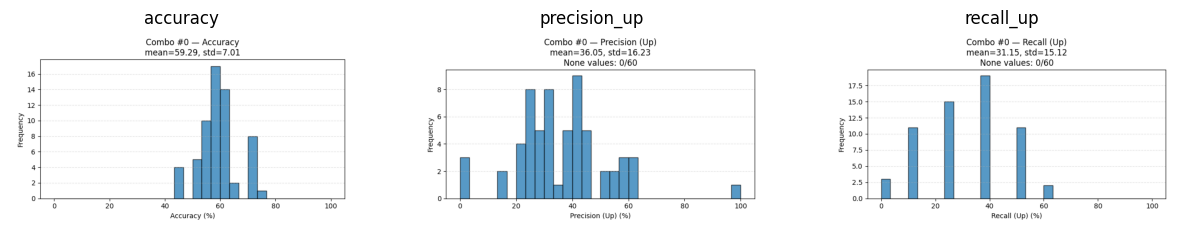

0.1


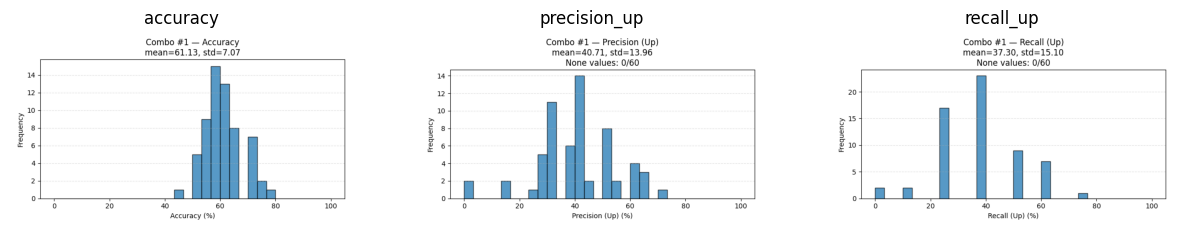

0.7


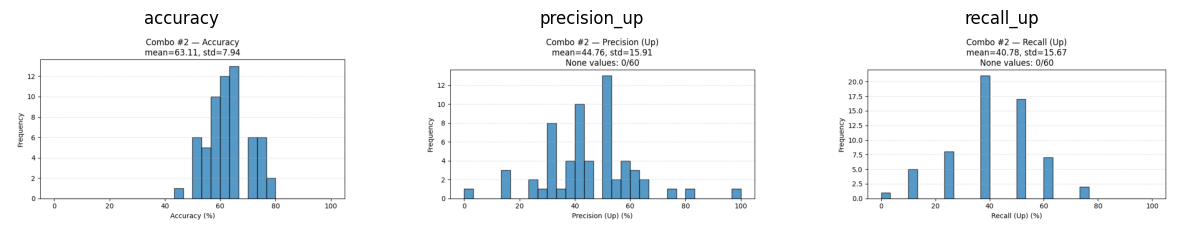

0.7


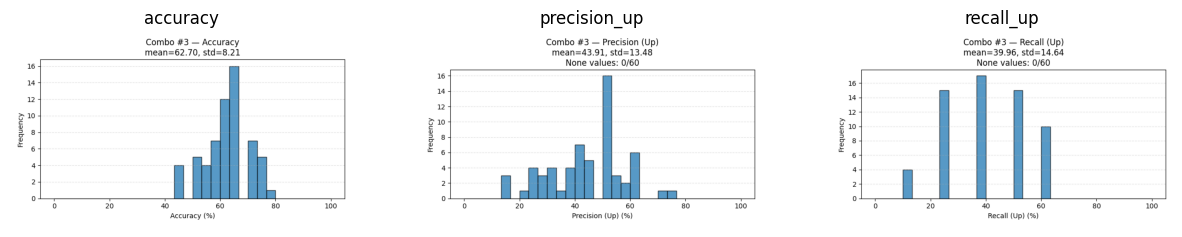

1


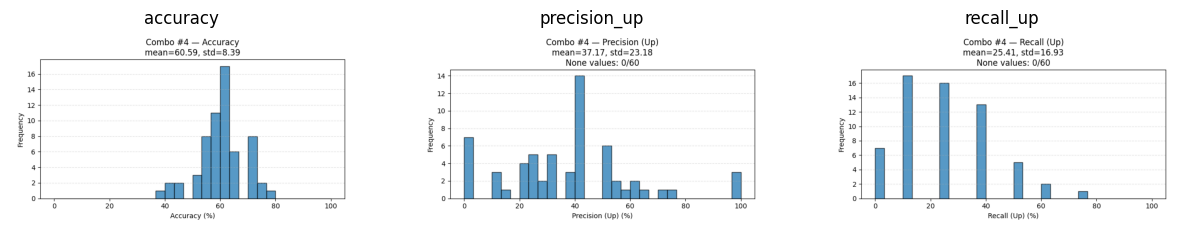

0.1


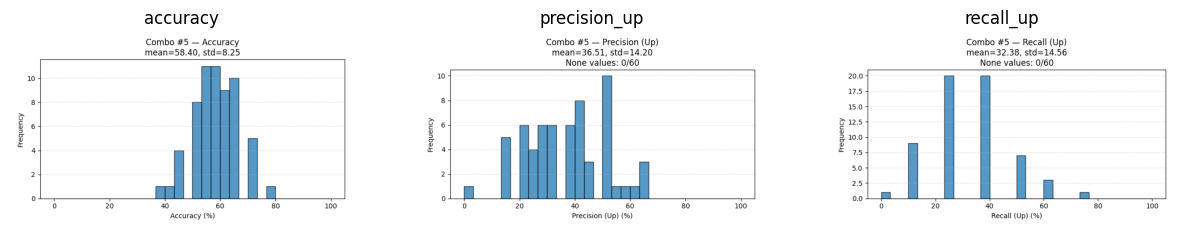

1


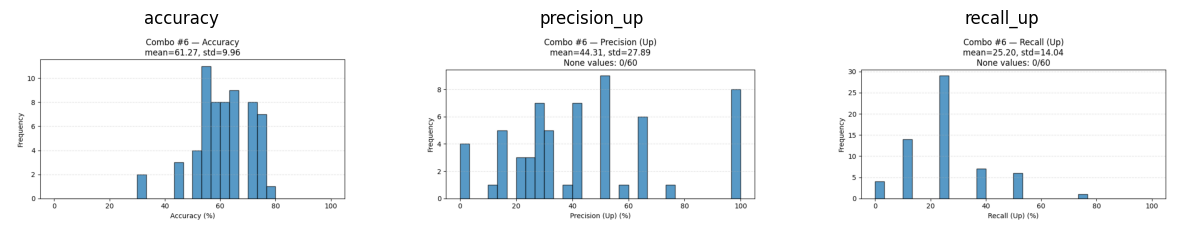

0.7


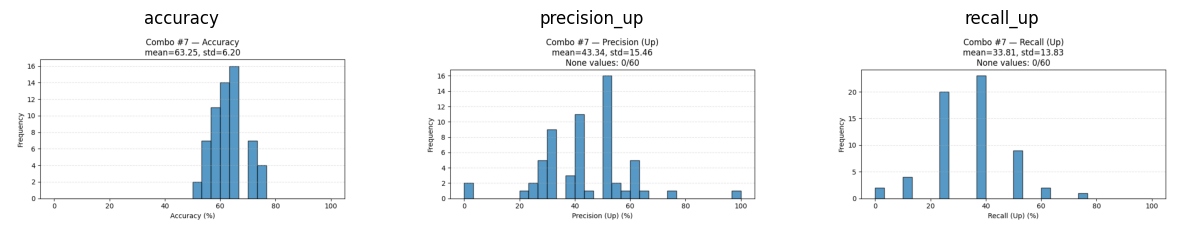

0.1


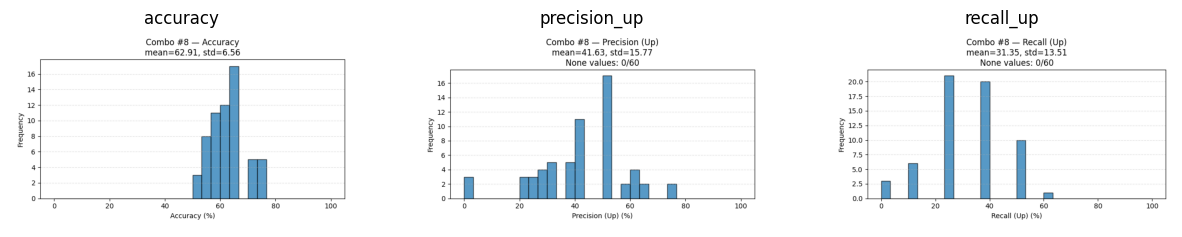

0.1


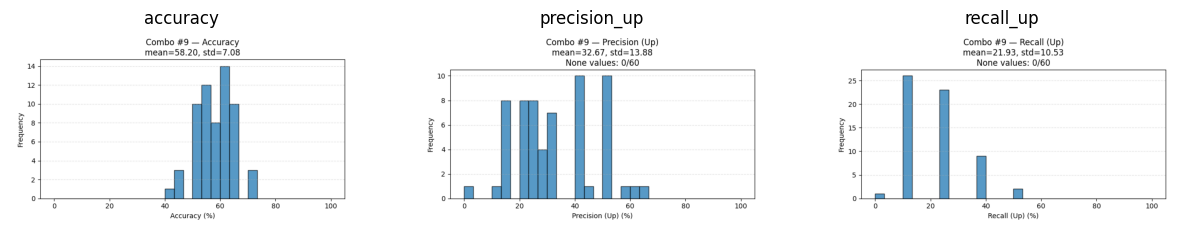

1.3


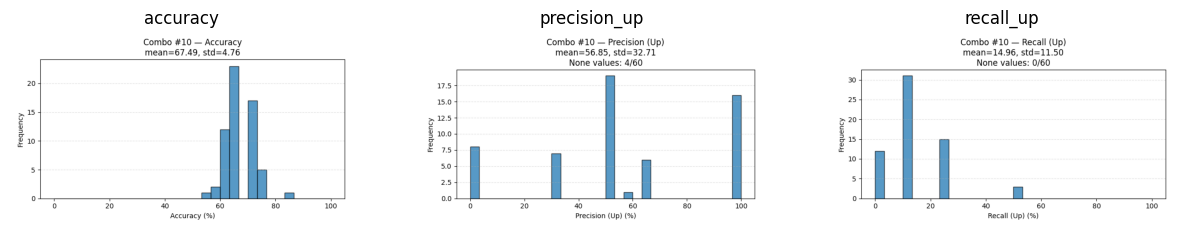

1.3


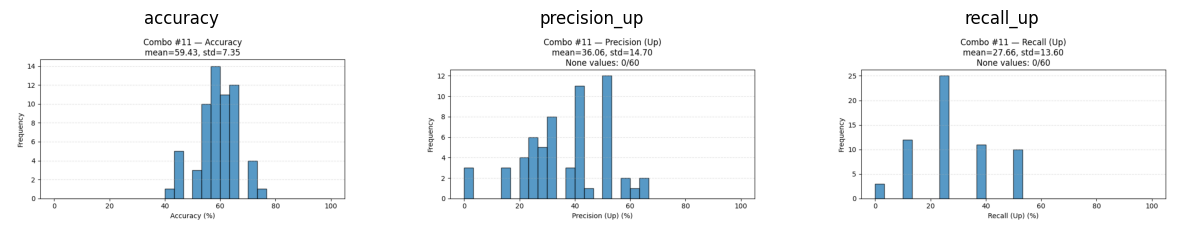

0.1


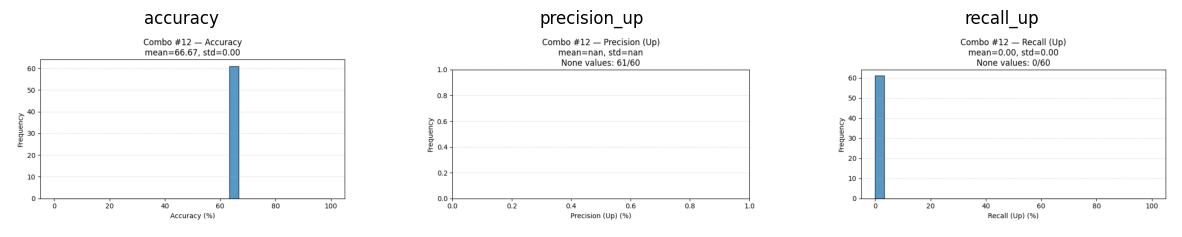

1


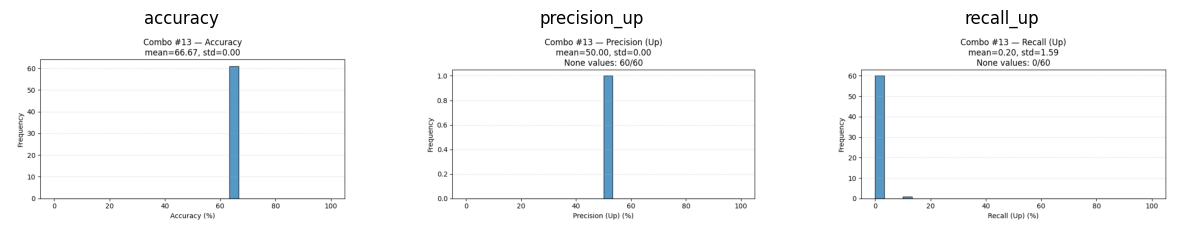

0.7


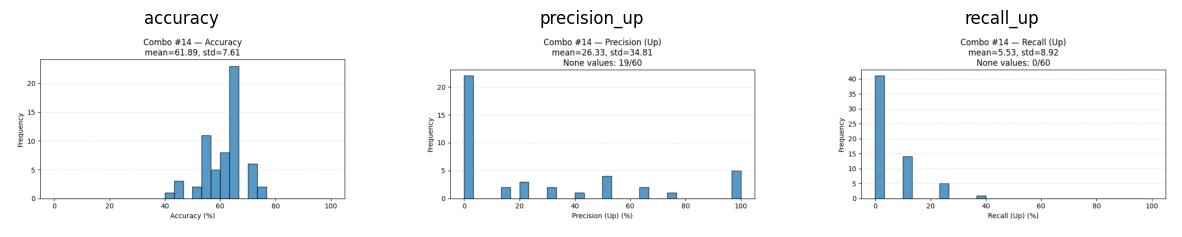

0.7


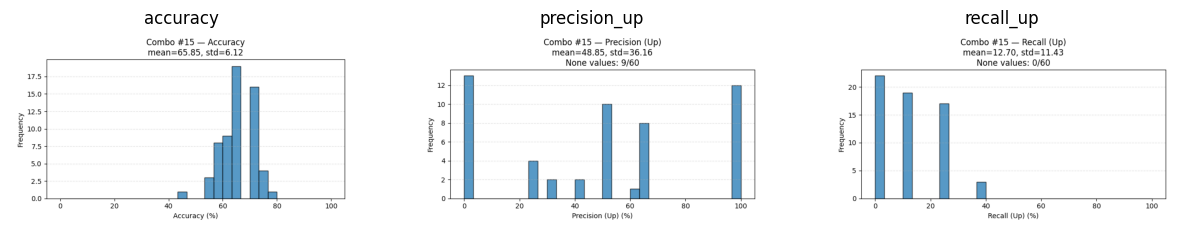

1


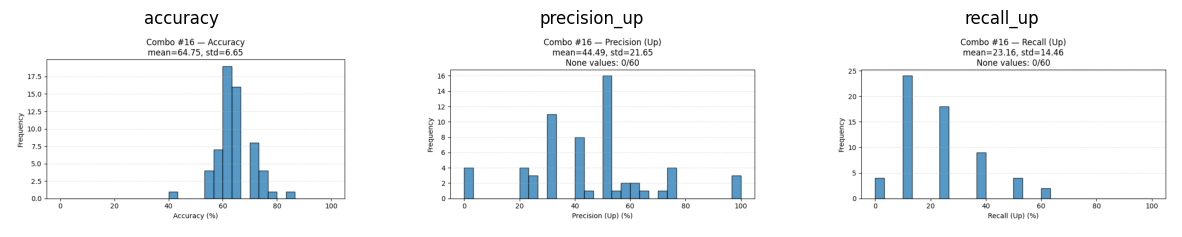

0.1


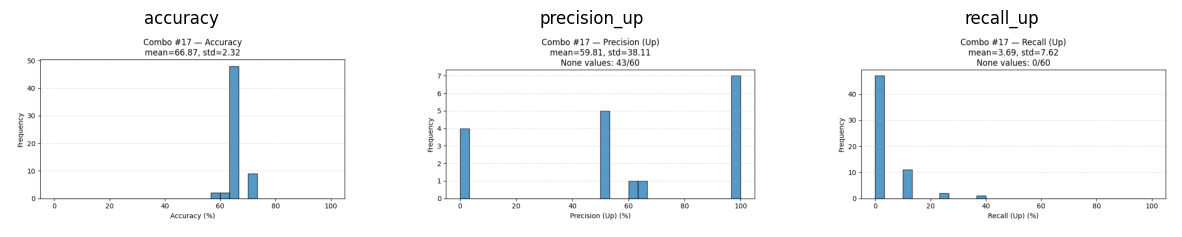

0.1


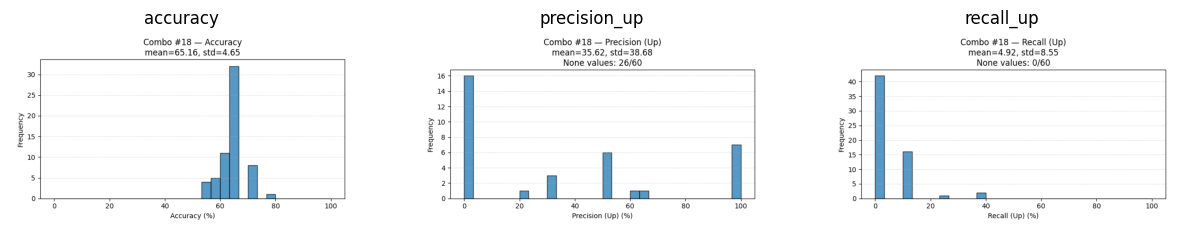

1


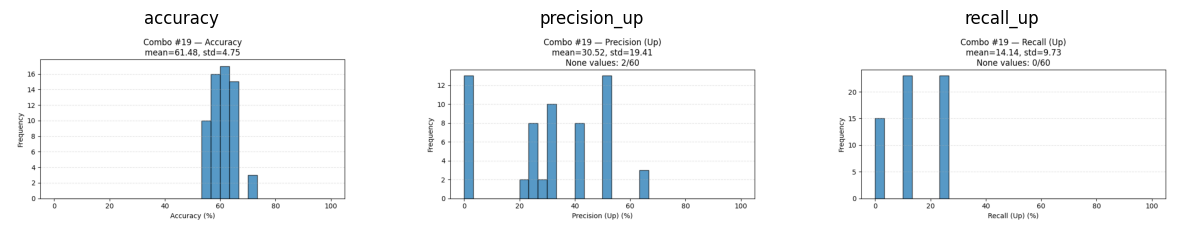

0.7


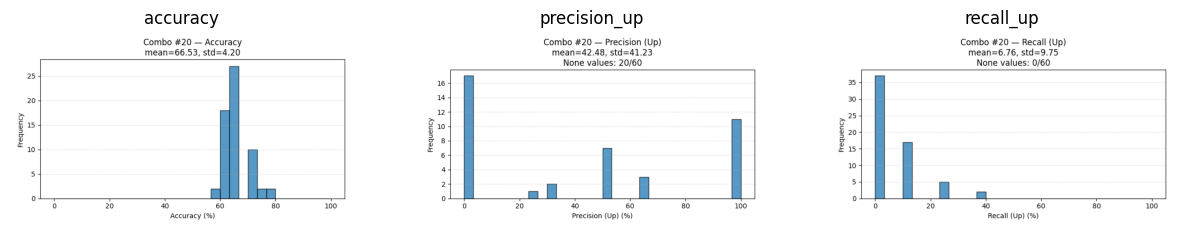

1


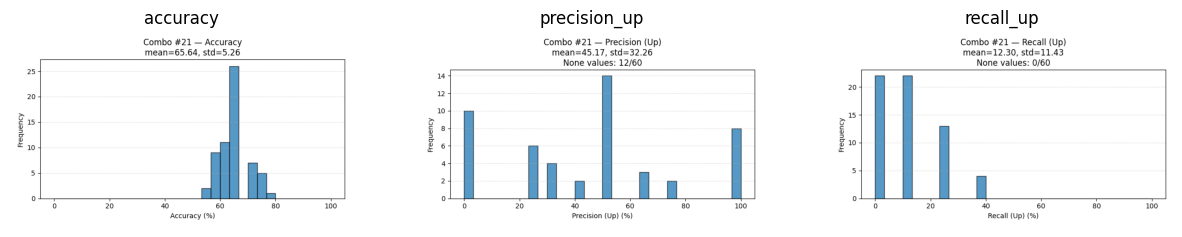

0.1


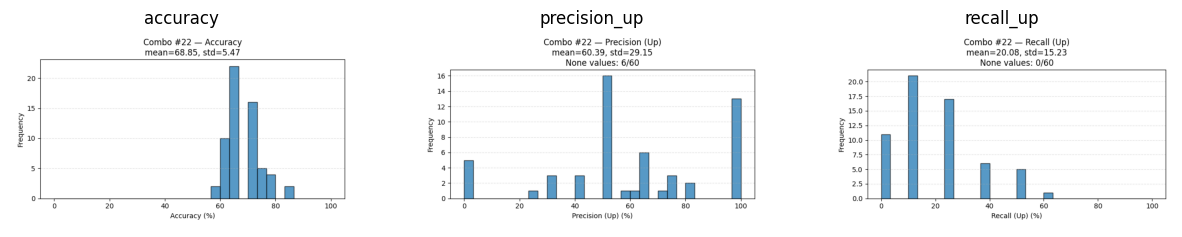

0.7


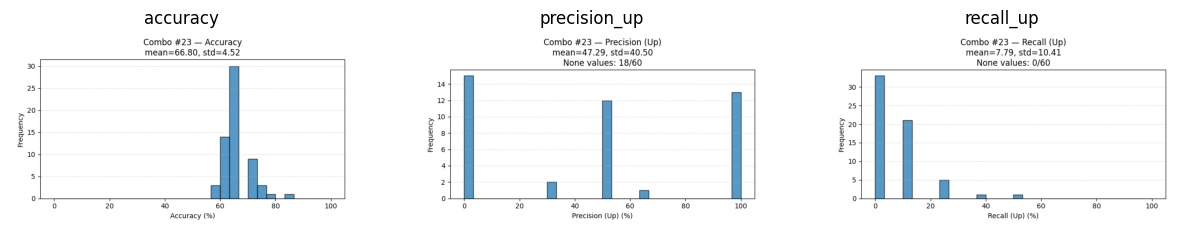

0.7


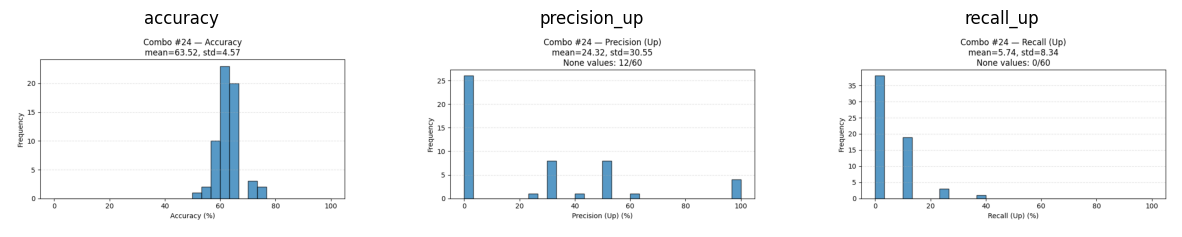

1.3


In [ ]:
import json

with open("/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/top_combos_dist_discovcery_25_combos_MAC.json") as f:
    results = json.load(f)



# for i in results:
#     print(i["combo_index"] , i["combo"]["POS_weight_multiplier"])

# for i in results:
#     for metric in ['accuracy', 'precision_up', 'recall_up']:
#         image_data = base64.b64decode(i["plots_base64"][metric])
#         display(Image(data=image_data))




import matplotlib.pyplot as plt
import base64
from io import BytesIO

metrics = ['accuracy', 'precision_up', 'recall_up']

for i in results:
    fig, axs = plt.subplots(1, len(metrics), figsize=(15, 5))  # one row, 3 cols
    for ax, metric in zip(axs, metrics):
        image_data = base64.b64decode(i["plots_base64"][metric])
        img = plt.imread(BytesIO(image_data), format="png")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(metric)
    plt.show()
    print(i["combo"]["POS_weight_multiplier"])



In [ ]:




# for i in results:
#     print('combo index' , i["combo_index"])
#     for j in i["per_seed"]:
#         if j["precision_up"] > 60:
#             print(j)


In [ ]:
#                                     Preformers in the 60 - 80% range prec up 

# for i in results:
#     print('combo index' , i["combo_index"])
#     for j in i["per_seed"]:
#         if j["precision_up"] > 60:
#             print(j)


# #   CHARACTERISTICS OF THE CHOSEN MODELS 
# - PREFORM IN THE RANGE OF 60 - 80 PREC UP , TO AVOID OVERFITTING!
# - ONE TO TWO MODELS CHOSEN WITH THE SAME PARAMS BUT DIFF SEED 
# - NEXT STUDY CORRELATIONS ARE SEE IF SAME PARAM MODEL, WITH DIFF SEED OFC, ARE NOT CORRELATED 
# - TEST PREFROMANCE OF TEST SET 
# - RUN ENSEMBLES AND COMPATE TO PREVIOUS 
# - NEXT CAN TRY MODELS WITH 100 PREC UP, BUT I AM SKEPTICAL THIS OVERFITS ... DUE TO INITIAL RESULTS 

all_dicts = [
    {"combo_index_1": [
        {'seed': 42, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        # {'seed': 414, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0},
    ]},
    {"combo_index_2": [
        {'seed': 5528, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0}
        # {'seed': 6718, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0},
    ]},
    {"combo_index_3": [
        {'seed': 8928, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        # {'seed': 6516, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5},
    ]},
    {"combo_index_6": [
        {'seed': 2846, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}
        # {'seed': 7788, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_8": [
        {'seed': 6526, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5}
        # {'seed': 5943, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_10": [
        {'seed': 8073, 'accuracy': 70.83333333333334, 'precision_up': 100.0, 'recall_up': 12.5}
        # {'seed': 508, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_22": [
        {'seed': 6825, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0}
        # {'seed': 2363, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_16": [
        {'seed': 7155, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        # {'seed': 8329, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0},
    ]},
]



for i in all_dicts:
    for j in results:
        if j["combo_index"] == int(list(i.keys())[0].split('_')[-1]):

            i["parameters"] = j["combo"]



In [ ]:
all_params_seeded = []

for d in all_dicts:
    params  = d["parameters"]
    seeds = [k["seed"] for k in list(d.values())[0]]


    for s in seeds:
        params["seed_num"] = s
        all_params_seeded.append(params)

In [ ]:
import copy
all_params_seeded


combos_test_param = []

for i in all_params_seeded:
    i_copy = copy.deepcopy(i)
    i_copy["val_set_fraction"] = 0.05
    i_copy["num_folds"] = 4
    i_copy["end_value_train_set_fraction"] = 0.95
    combos_test_param.append(i_copy)
 

In [ ]:
with parallel_backend("loky", n_jobs=-1):
    results_T = Parallel()(
        delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
        for i, (combo) in enumerate(combos_test_param)
    )

--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.95, 'val_set_fraction': 0.05, 'num_folds': 4, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 3 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 150,

In [ ]:
with parallel_backend("loky", n_jobs=-1):
    results_V = Parallel()(
        delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
        for i, (combo) in enumerate(all_params_seeded)
    )

--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 3 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 150, 

In [ ]:
#                                       Top precision up preformers (100% if pssible)

# for i in results:
#     print('combo index' , i["combo_index"])
#     for j in i["per_seed"]:
#         if j["precision_up"] > 60:
#             print(j)


# #   CHARACTERISTICS OF THE CHOSEN MODELS 
# - PREFORM IN THE RANGE OF 60 - 80 PREC UP , TO AVOID OVERFITTING!
# - ONE TO TWO MODELS CHOSEN WITH THE SAME PARAMS BUT DIFF SEED 
# - NEXT STUDY CORRELATIONS ARE SEE IF SAME PARAM MODEL, WITH DIFF SEED OFC, ARE NOT CORRELATED 
# - TEST PREFROMANCE OF TEST SET 
# - RUN ENSEMBLES AND COMPATE TO PREVIOUS 
# - NEXT CAN TRY MODELS WITH 100 PREC UP, BUT I AM SKEPTICAL THIS OVERFITS ... DUE TO INITIAL RESULTS 

all_dicts = [
    {"combo_index_1": [
        {'seed': 42, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        # {'seed': 414, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0},
    ]},
    {"combo_index_2": [
        # {'seed': 5528, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0}
        {'seed': 127, 'accuracy': 79.16666666666666, 'precision_up': 100.0, 'recall_up': 37.5}

        # {'seed': 6718, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0},
    ]},
    {"combo_index_3": [
        # {'seed': 8928, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        {'seed': 9805, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}

        # {'seed': 6516, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5},
    ]},
    {"combo_index_6": [
        # {'seed': 2846, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}
        {'seed': 2662, 'accuracy': 79.16666666666666, 'precision_up': 100.0, 'recall_up': 37.5}

        # {'seed': 7788, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_8": [
        # {'seed': 6526, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5}
        {'seed': 4376, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}
        # {'seed': 5943, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_10": [
        # {'seed': 8073, 'accuracy': 70.83333333333334, 'precision_up': 100.0, 'recall_up': 12.5}
        {'seed': 2900, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 508, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_22": [
        # {'seed': 6825, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0}
        {'seed': 1321, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 2363, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_16": [
        # {'seed': 7155, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}
        {'seed': 7997, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 8329, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0},
    ]},
]



for i in all_dicts:
    for j in results:
        if j["combo_index"] == int(list(i.keys())[0].split('_')[-1]):

            i["parameters"] = j["combo"]



In [ ]:
all_params_seeded = []

for d in all_dicts:
    params  = d["parameters"]
    seeds = [k["seed"] for k in list(d.values())[0]]


    for s in seeds:
        params["seed_num"] = s
        all_params_seeded.append(params)

In [ ]:
import copy
all_params_seeded


combos_test_param = []

for i in all_params_seeded:
    i_copy = copy.deepcopy(i)
    i_copy["val_set_fraction"] = 0.05
    i_copy["num_folds"] = 4
    i_copy["end_value_train_set_fraction"] = 0.95
    combos_test_param.append(i_copy)
 

In [ ]:
with parallel_backend("loky", n_jobs=-1):
    results_T_h = Parallel()(
        delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
        for i, (combo) in enumerate(combos_test_param)
    )

--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.95, 'val_set_fraction': 0.05, 'num_folds': 4, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 3 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 150,

In [ ]:
with parallel_backend("loky", n_jobs=-1):
    results_V_h = Parallel()(
        delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
        for i, (combo) in enumerate(all_params_seeded)
    )

--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 2 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 150, 

In [ ]:


r_V_h ,w = zip(*results_V_h)

r_T_h ,w = zip(*results_T_h)

# for i in r:
#     print(i["cv_sets"]["overall_metrics"])


for i in r_T_h:
    print(i["parameters"])

{'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.95, 'val_set_fraction': 0.05, 'num_folds': 4, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}
{'learning_rate': 0.05, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 

In [ ]:
import json




import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)
    


file_json_metrics = f"/Users/cs/Desktop/top_combos_dist_discovcery_high_prec_seeds_results_MAC_V.json"


with open(file_json_metrics, "w") as f_json:
    json.dump(r_V_h, f_json, cls=NumpyEncoder, indent=2)



file_json_metrics = f"/Users/cs/Desktop/top_combos_dist_discovcery_high_prec_seeds_results_MAC_T.json"


with open(file_json_metrics, "w") as f_json:
    json.dump(r_T_h, f_json, cls=NumpyEncoder, indent=2)




In [ ]:
import json

with open("/Users/cs/Desktop/Project_DATA_LSTM_Spot_Price_WTI/top_combos_dist_discovcery_25_combos_MAC.json") as f:
    results = json.load(f)




In [ ]:
#                                    ALL ALL ALL ALL 

# for i in results:
#     print('combo index' , i["combo_index"])
#     for j in i["per_seed"]:
#         if j["precision_up"] > 60:
#             print(j)


# #   CHARACTERISTICS OF THE CHOSEN MODELS 
# - PREFORM IN THE RANGE OF 60 - 80 PREC UP , TO AVOID OVERFITTING!
# - ONE TO TWO MODELS CHOSEN WITH THE SAME PARAMS BUT DIFF SEED 
# - NEXT STUDY CORRELATIONS ARE SEE IF SAME PARAM MODEL, WITH DIFF SEED OFC, ARE NOT CORRELATED 
# - TEST PREFROMANCE OF TEST SET 
# - RUN ENSEMBLES AND COMPATE TO PREVIOUS 
# - NEXT CAN TRY MODELS WITH 100 PREC UP, BUT I AM SKEPTICAL THIS OVERFITS ... DUE TO INITIAL RESULTS 

all_dicts = [
    {"combo_index_1": [
        {'seed': 42, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5},
        {'seed': 414, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0}
    ]},
    {"combo_index_2": [
        {'seed': 5528, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
        {'seed': 127, 'accuracy': 79.16666666666666, 'precision_up': 100.0, 'recall_up': 37.5}

        # {'seed': 6718, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0},
    ]},
    {"combo_index_3": [
        {'seed': 8928, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5},
        {'seed': 9805, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}

        # {'seed': 6516, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5},
    ]},
    {"combo_index_6": [
        {'seed': 2846, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
        {'seed': 2662, 'accuracy': 79.16666666666666, 'precision_up': 100.0, 'recall_up': 37.5}

        # {'seed': 7788, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_8": [
        {'seed': 6526, 'accuracy': 75.0, 'precision_up': 62.5, 'recall_up': 62.5},
        {'seed': 4376, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5}
        # {'seed': 5943, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_10": [
        # {'seed': 8073, 'accuracy': 70.83333333333334, 'precision_up': 100.0, 'recall_up': 12.5},
        {'seed': 2900, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 508, 'accuracy': 75.0, 'precision_up': 66.66666666666666, 'recall_up': 50.0},
    ]},
    {"combo_index_22": [
        {'seed': 6825, 'accuracy': 79.16666666666666, 'precision_up': 80.0, 'recall_up': 50.0},
        {'seed': 1321, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 2363, 'accuracy': 75.0, 'precision_up': 75.0, 'recall_up': 37.5},
    ]},
    {"combo_index_16": [
        {'seed': 7155, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5},
        {'seed': 7997, 'accuracy': 83.33333333333334, 'precision_up': 100.0, 'recall_up': 50.0}

        # {'seed': 8329, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0},
    ]},
]



for i in all_dicts:
    for j in results:
        if j["combo_index"] == int(list(i.keys())[0].split('_')[-1]):

            i["parameters"] = j["combo"]

for i in all_dicts:
    print(i["parameters"])

{'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None}
{'learning_rate': 0.05, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 1

In [ ]:
for d in all_dicts:
    for i in d.values():
        print(i)

[{'seed': 42, 'accuracy': 79.16666666666666, 'precision_up': 71.42857142857143, 'recall_up': 62.5}, {'seed': 414, 'accuracy': 70.83333333333334, 'precision_up': 66.66666666666666, 'recall_up': 25.0}]
{'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling

In [ ]:
import copy

all_params_seeded = []

for d in all_dicts:
    params = d["parameters"]
    seeds = [k["seed"] for k in list(d.values())[0]]

    for s in seeds:
        p = copy.deepcopy(params)  # new independent dict
        p["seed_num"] = s
        all_params_seeded.append(p)

# for i in all_params_seeded:
#     print(i["seed_num"])

# import copy
# all_params_seeded


# combos_test_param = []

# for i in all_params_seeded:
#     i_copy = copy.deepcopy(i)
#     i_copy["val_set_fraction"] = 0.05
#     i_copy["num_folds"] = 4
#     i_copy["end_value_train_set_fraction"] = 0.95
#     combos_test_param.append(i_copy)
 
all_params_seeded


[{'learning_rate': 0.05,
  'num_epochs': 70,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 3,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1': False,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': True,
  'use_class_weighting': False,
  'is_deterministic': True,
  'seed_num': 42,
  'use_monthly_predictor': False,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_monthly_daily_end_mo_predictor': False,
  'use_monthly_weekly_end_mo_predictor': True,
  'use_binary_0_1_custom_neg': True,
  'use_binary_0_1_custom_pos': False,
  'binary_0_1_cutoff_ret_rate_percentage': 0.05,
  'end_value_train_set_fraction': 0.85,
  'val_set_fraction': 0.1,
  'num_folds': 8,
  'POS_weight_multiplier': 0.7,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None},
 {'learning_rate': 0.05,
  'num_epochs': 70,
  'ba

In [ ]:
from joblib import Parallel, delayed , parallel_backend


with parallel_backend("loky", n_jobs=-1):
    results = Parallel()(
        delayed(run_combo)(0, combo, i, use_print_acc_vs_pred=False)
        
        for i, (combo) in enumerate(all_params_seeded)
    )

KeyboardInterrupt: 

In [ ]:


r,w = zip(*results)


# for i in r:
#     print(i["cv_sets"]["overall_metrics"])




15

In [ ]:



import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)
    

# Your existing code
file_json_metrics = f"/Users/cs/Desktop/dist_discovcery_chosen_combos_lowANDhigh_prec_MAC_V_results.json"

with open(file_json_metrics, "w") as f_json:
    json.dump(  r   , f_json, cls=NumpyEncoder, indent=2)



--- 
# TESTING
--- 

In [ ]:
with open('/Users/cs/Desktop/full_results_chunk_1_25_CHUNKS_8fold_05NEG__VERSION_4__GSresults.json', 'r') as f:
    results = json.load(f)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/cs/Desktop/full_results_chunk_1_25_CHUNKS_8fold_05NEG__VERSION_4__GSresults.json'

In [ ]:
# import json
# import numpy as np


# results_chunks = {}


# # Load all 8-fold results from the specified directory
# for i in range(2):

#     with open(f'/Users/cs/Desktop/full_results_chunk_{i + 1}_15_CHUNKS_8fold_05NEG__VERSION_3.json', 'r') as f:
#         results_chunks[f'CV_Results_chunk_{i + 1}'] = json.load(f)



# all_results = []

# for i in results_chunks["CV_Results_chunk_1"]:
#     all_results.append(i)

# for i in results_chunks["CV_Results_chunk_2"]:
#     all_results.append(i)





# # Step 1: Compute scores
# scored_results = []
# for entry in all_results:
#     avg = entry['cv_sets'].get('avg_across_all_sets', {})
#     acc = avg.get('accuracy', 0.0) or 0.0
#     prec_up = avg.get('precision_up', 0.0) or 0.0

#     total_score = acc + prec_up
#     scored_results.append((total_score, entry))

# # Step 2: Sort by score descending
# scored_results.sort(reverse=True, key=lambda x: x[0])

# # Step 3: Extract top 10 entries
# top = scored_results[:25]


# top


# for i, j in top:
#     print(j["cv_sets"]["avg_across_all_sets"])

# combos = []

# for i, j in top:
#     combos.append(j["parameters"])

# combos

In [ ]:
# from joblib import parallel_backend
# from joblib import Parallel
# from joblib import delayed


# # for i in combos:
# #     run_combo(4, i, 4, use_print_acc_vs_pred=False)


# with parallel_backend("loky", n_jobs=-1):
#     results = Parallel()(
#         delayed(run_combo)(0, combo, 0, use_print_acc_vs_pred=False)
        
#         for i, combo in enumerate(combos)
#     )

# # --- Unzip results ---
# metrics_list, weights_list = zip(*results)


--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 5, 'num_layers': 4, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': True, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': True, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 1 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 70, 'bat

: 

: 

: 

: 

: 

: 

In [ ]:


# import random
# import matplotlib.pyplot as plt
# import numpy as np


# # To display the plot in a Jupyter notebook:
# from IPython.display import Image, display
# import base64

# ###################################################################################################### LOOPS THROUGH EACH COMBINATION, RUNS X TIMES WITH RANDOMLY CHOSEN SEED TO BUILD OUT A DISTRIBUTION 
# #*#**#*#*#*#*#**#*#*#*#**#*#*#*#*#**#*#*#*#**#*#*#*#*#**#*#*#*#**#*#*#*#*#**#*#*#*#**#*#*#*#*#**#*#*        WITH IN PARALLALIZATION WITHIN FUNCTION  

# random.seed(12345)

# import random, io, base64, math
# import numpy as np
# import matplotlib.pyplot as plt
# from joblib import Parallel, delayed, parallel_backend

# random.seed(12345)

# def distribution_discovery(combo: dict, combo_index: int , number_of_seeds: int):
#     """
#     Run the same combo across many different seeds by overriding combo['seed_num'].
#     Uses the current run_combo signature:
#         run_combo(INDEX, combo, total_offset, use_print_acc_vs_pred)
#     Extracts the 'avg_across_all_sets' → 'accuracy' and plots its distribution.
#     Returns a dict with seeds, summary, and a base64-encoded PNG of the histogram.
#     """
#     print(f"****************** STARTED RUN FOR COMBO INDEX {combo_index}")

#     # choose seeds

#     seeds = random.sample(range(10000), number_of_seeds)
#     if 42 not in seeds:
#         seeds.append(42)

#     def run_for_seed(seed_val):
#         # override seed in combo (DO NOT mutate original)
#         combo_seeded = dict(combo)
#         combo_seeded['seed_num'] = seed_val
#         combo_seeded['is_deterministic'] = True  # ensure deterministic path uses the provided seed

#         # run
#         result_entry, _ = run_combo(0, combo_seeded, total_offset=0, use_print_acc_vs_pred=False)

#         # extract avg accuracy across folds
#         try:
#             avg_acc = result_entry['cv_sets']['avg_across_all_sets'].get('accuracy', np.nan)
#         except Exception:
#             avg_acc = np.nan

#         return {'seed': seed_val, 'avg_accuracy': float(avg_acc) if avg_acc is not None else np.nan}

#     # parallel runs
#     with parallel_backend("loky"):
#         per_seed = Parallel(n_jobs=4)(delayed(run_for_seed)(s) for s in seeds)

#     # summary stats
#     accs = np.array([r['avg_accuracy'] for r in per_seed], dtype=np.float64)
#     mean_acc = float(np.nanmean(accs)) if np.isfinite(accs).any() else float('nan')
#     std_acc  = float(np.nanstd(accs))  if np.isfinite(accs).any() else float('nan')

#     # plot histogram of avg accuracies (across all folds) over seeds
#     fig = plt.figure(figsize=(7, 4))
#     plt.hist(accs[~np.isnan(accs)], bins=25, range = (0,100), edgecolor='black', alpha=0.75)
#     plt.xlabel("Avg Accuracy Across CV Folds (%)")
#     plt.ylabel("Frequency")
#     plt.title(f"Combo #{combo_index} — mean={mean_acc:.2f}, std={std_acc:.2f}")
#     plt.grid(axis='y', linestyle='--', alpha=0.4)
#     plt.tight_layout()

#     # encode figure to base64
#     buf = io.BytesIO()
#     plt.savefig(buf, format='png')
#     buf.seek(0)
#     img_b64 = base64.b64encode(buf.read()).decode('utf-8')
#     plt.close(fig)

#     return {
#         'combo_index': combo_index,
#         'combo': combo,
#         # 'seeds': seeds,
#         'per_seed': per_seed,  # list of {'seed', 'avg_accuracy'}
#         'summary_stats': {'mean': mean_acc, 'std': std_acc},
#         'plot_base64': img_b64,
#     }


# c =  {'learning_rate': 0.05,
#   'num_epochs': 70,
#   'batch_size': 50,
#   'use_bidirectional': False,
#   'lag': 3,
#   'input_size': 12,
#   'hidden_size': 5,
#   'num_layers': 4,
#   'use_monthly_dfs_only': True,
#   'use_binary_0_1': False,
#   'use_binary_neg1_1': False,
#   'use_ret_rate': False,
#   'use_print_acc': False,
#   'use_dropout': True,
#   'use_class_weighting': True,
#   'is_deterministic': True,
#   'seed_num': 42,
#   'use_monthly_predictor': False,
#   'use_existing_lagged_data': True,
#   'use_dynamic_weights': False,
#   'use_monthly_daily_end_mo_predictor': False,
#   'use_monthly_weekly_end_mo_predictor': True,
#   'use_binary_0_1_custom_neg': True,
#   'use_binary_0_1_custom_pos': False,
#   'binary_0_1_cutoff_ret_rate_percentage': 0.05,
#   'end_value_train_set_fraction': 0.85,
#   'val_set_fraction': 0.1,
#   'num_folds': 8,
#   'POS_weight_multiplier': 0.7,
#   'use_rolling_fixed_train_size': True,
#   'use_existing_initial_weights': False,
#   'state_dict': None}



# # with parallel_backend("loky"):
# #     parallel_results = Parallel(n_jobs=-1)(
# #         delayed(distribution_discovery)(run, combo_index=i , number_of_seeds = 5)
# #         for i, run in enumerate(top_combos_dicts)
# #     )





# res = distribution_discovery(c, combo_index= , number_of_seeds = 200)


SyntaxError: expected argument value expression (3173363536.py, line 135)

: 

: 

: 

In [ ]:
# image_data = base64.b64decode(res["plot_base64"])
# display(Image(data=image_data))



NameError: name 'base64' is not defined

: 

: 

: 

In [ ]:
# image_data = base64.b64decode(res["plot_base64"])
# display(Image(data=image_data))




# import pickle
# with open('/Users/cs/Desktop/Oil-LSTM-Project-2-2/short_dfs.pkl', 'rb') as f:
#     loaded_dfs = pickle.load(f)

# with open("/Users/cs/Desktop/Oil-LSTM-Project-2-2/lagged_cache.pkl", "rb") as f:
#     lagged_cache = pickle.load(f)



: 

: 

: 

In [ ]:

import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed
from collections import defaultdict
import math
import copy

import torch.nn as nn

import torch
c =  {'learning_rate': 0.05,
  'num_epochs': 7,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 3,
  'input_size': 12,
  'hidden_size': 5,
  'num_layers': 4,
  'use_monthly_dfs_only': True,
  'use_binary_0_1': False,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': True,
  'use_class_weighting': True,
  'is_deterministic': True,
  'seed_num': 42,
  'use_monthly_predictor': False,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_monthly_daily_end_mo_predictor': False,
  'use_monthly_weekly_end_mo_predictor': True,
  'use_binary_0_1_custom_neg': True,
  'use_binary_0_1_custom_pos': False,
  'binary_0_1_cutoff_ret_rate_percentage': 0.05,
  'end_value_train_set_fraction': 0.85,
  'val_set_fraction': 0.1,
  'num_folds': 8,
  'POS_weight_multiplier': 0.7,
  'use_rolling_fixed_train_size': True,
  'use_existing_initial_weights': False,
  'state_dict': None}


a,b = run_combo_ensemble(2,c,3,False)

--- Running Combo 6 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 7, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 5, 'num_layers': 4, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': True, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': True, 'use_existing_initial_weights': False, 'state_dict': None}



: 

: 

: 

In [ ]:
from joblib import parallel_backend , Parallel



models_combo_list = [{'learning_rate': 0.05,'num_epochs': 7,'batch_size': 50,'use_bidirectional': False,
  'lag': 3,'input_size': 12,'hidden_size': 5,'num_layers': 4,'use_monthly_dfs_only': True,'use_binary_0_1': False,'use_binary_neg1_1': False,'use_ret_rate': False,
  'use_print_acc': False,'use_dropout': True,'use_class_weighting': True,'is_deterministic': True,'seed_num': 42,'use_monthly_predictor': False,'use_existing_lagged_data': True,'use_dynamic_weights': False,
  'use_monthly_daily_end_mo_predictor': False,'use_monthly_weekly_end_mo_predictor': True,'use_binary_0_1_custom_neg': True,'use_binary_0_1_custom_pos': False,
  'binary_0_1_cutoff_ret_rate_percentage': 0.05,'end_value_train_set_fraction': 0.85,'val_set_fraction': 0.1,'num_folds': 8,
  'POS_weight_multiplier': 0.7,'use_rolling_fixed_train_size': True,'use_existing_initial_weights': False,'state_dict': None}

  , 

  {'learning_rate': 0.05,'num_epochs': 7,'batch_size': 50,'use_bidirectional': False,'lag': 3,'input_size': 12,'hidden_size': 5,'num_layers': 4,
  'use_monthly_dfs_only': True,'use_binary_0_1': False,'use_binary_neg1_1': False,'use_ret_rate': False,'use_print_acc': False,'use_dropout': True,'use_class_weighting': True,'is_deterministic': True,
  'seed_num': 42,'use_monthly_predictor': False,'use_existing_lagged_data': True,'use_dynamic_weights': False,
  'use_monthly_daily_end_mo_predictor': False,'use_monthly_weekly_end_mo_predictor': True,'use_binary_0_1_custom_neg': True,'use_binary_0_1_custom_pos': False,
  'binary_0_1_cutoff_ret_rate_percentage': 0.05,'end_value_train_set_fraction': 0.85,'val_set_fraction': 0.1,'num_folds': 8,
  'POS_weight_multiplier': 0.7,'use_rolling_fixed_train_size': True,'use_existing_initial_weights': False,'state_dict': None}


]


# --- Run in parallel ---
with parallel_backend("loky", n_jobs=-1):
    all_results  = Parallel()(
        delayed(run_combo_ensemble)(i, combo, 10, use_print_acc_vs_pred=False)
        for i, combo in enumerate(models_combo_list)
    )

results, weights  = zip(*all_results)

# Step 1: Collect all_preds from each model
all_model_preds = [res["all_preds"] for res in results]  # shape: (num_models, num_folds)

# Step 2: Transpose so we group predictions per fold across models
transposed_preds = list(zip(*all_model_preds))  # shape: (num_folds, num_models)

# Step 3: Average predictions for each fold
avg_preds_per_fold = [np.mean(np.stack(preds), axis=0) for preds in transposed_preds]







--- Running Combo 11 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 7, 'batch_size': 50, 'use_bidirectional': False, 'lag': 3, 'input_size': 12, 'hidden_size': 5, 'num_layers': 4, 'use_monthly_dfs_only': True, 'use_binary_0_1': False, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': True, 'use_class_weighting': True, 'is_deterministic': True, 'seed_num': 42, 'use_monthly_predictor': False, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_monthly_daily_end_mo_predictor': False, 'use_monthly_weekly_end_mo_predictor': True, 'use_binary_0_1_custom_neg': True, 'use_binary_0_1_custom_pos': False, 'binary_0_1_cutoff_ret_rate_percentage': 0.05, 'end_value_train_set_fraction': 0.85, 'val_set_fraction': 0.1, 'num_folds': 8, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': True, 'use_existing_initial_weights': False, 'state_dict': None}

--- Running Combo 12 ---Parameters: {'learning_rate': 0.05, 'num_epochs': 7, 'bat

: 

: 

: 

[array([0.35402727, 0.3556526 , 0.35261515], dtype=float32),
 array([0.5897745, 0.5900981, 0.5899443], dtype=float32),
 array([0.48919123, 0.48928595, 0.489183  ], dtype=float32),
 array([0.36290085, 0.3627126 , 0.36174676], dtype=float32),
 array([0.48281696, 0.48331463, 0.48422357], dtype=float32),
 array([0.3729734 , 0.37605792, 0.37456033], dtype=float32),
 array([0.36590055, 0.36802793, 0.3658256 ], dtype=float32),
 array([0.49046436, 0.49121776, 0.4913105 ], dtype=float32)]

: 

: 

: 

In [ ]:
np.stack(transposed_preds[0])
transposed_preds[0]


(array([0.35402727, 0.3556526 , 0.35261515], dtype=float32),
 array([0.35402727, 0.3556526 , 0.35261515], dtype=float32))

: 

: 

: 

In [ ]:
import pickle
with open('/Users/cs/Desktop/Oil-LSTM-Project-2/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/Oil-LSTM-Project-2/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


: 

: 

: 

In [ ]:
# one model - take the avg fo the restuls many times 

# many models - take the avg of the results (could also take the avg of the models over different seeds first)

# selective model 




list_all_preds = []

for array_fold in a["all_preds"]:
    for value in array_fold:
        list_all_preds.append(value) 

def ensemble_function (use_simple_avg : bool, 
                       model_results_1 : list , model_results_2 : list ,model_results_3 : list , num_models :  ):
                       
                    #    ,model_results_4 : list ,model_results_5 : list ,model_results_6 : list )

    cv_data = {}  

    models_list = 


    if use_simple_avg: 
            
        avg_results = []

        num_models = 3

        for set_idx , (fold1   ,  fold2   ,   fold3) in enumerate(zip( model_results_1,model_results_2,model_results_3 )):
            avg = (fold1  +  fold2  +  fold3) / num_models
            avg_results.append(avg)



            metrics = evaluate_binary_0_1(predicted_array, actual_array, do_print=use_print_acc)



            cv_data[f"set_{set_idx + 1}"] = metrics
 

        # === Compute overall average ===
        metrics_keys = cv_data[f"set_{set_idx + 1}"].keys()

        overall_avg = {}
        for k in metrics_keys:
            values = [cv_data[f"set_{i + 1}"][k] for i in range(num_cv_sets)]
            # For string values (i.e., "No 'up' samples..."), skip them in averaging
            numeric_values = [v for v in values if v is not None and not (isinstance(v, float) and np.isnan(v)) and isinstance(v, (int, float))]
            if len(numeric_values) > 0:
                overall_avg[k] = np.mean(numeric_values)

            else:
                overall_avg[k] = None
            # else:
            #     # If all values are string messages, keep the message
            #     string_values = [v for v in values if isinstance(v, str)]
            #     overall_avg[k] = string_values[0] if string_values else np.nan
        cv_data["avg_across_all_sets"] = overall_avg

        return cv_data , model_weight_dict  

    cv_data , model_weight_dict = GRIDSEARCH_FUNCTION_WITH_CV_forTS(**combo)

    


    result_entry = {
        "combo_number": total_offset + INDEX + 1,
        "parameters": combo,
        "cv_sets": cv_data,
    }

    print(
        f"--- Running Combo {total_offset + INDEX + 1} ---" 
        f"Parameters: {combo}\n" ,
        # f"→ Fold Accuracies: " +
        # "  ".join(
        #     f"{k}: {cv_data[k][0]['accuracy']}"  # <-- each set is now a list of metric dicts 
        #     for k in sorted(cv_data) if k.startswith("set_")
        # ) +
        # f"\n→ Overall Avg Accuracy: {cv_data['avg_across_all_sets']['accuracy']}",
        flush=True
    )

    return result_entry ,model_weight_dict


ensemble_function (use_simple_avg  = True, 
                       model_results_1 = a["all_preds"], 
                       model_results_2 = a["all_preds"] ,
                       model_results_3 = a["all_preds"] )



# a["all_preds"]


[array([0.12543239, 0.09037582, 0.25464922], dtype=float32),
 array([0.43697914, 0.2516038 , 0.28423998], dtype=float32),
 array([0.39297518, 0.45505437, 0.52827805], dtype=float32),
 array([0.2518047, 0.579028 , 0.6116389], dtype=float32),
 array([0.40713605, 0.3878775 , 0.38475809], dtype=float32),
 array([0.18569678, 0.5774644 , 0.10767   ], dtype=float32),
 array([0.23631914, 0.30201563, 0.41839305], dtype=float32),
 array([0.9239113 , 0.91865396, 0.89724296], dtype=float32)]

: 

: 

: 

In [ ]:
a["all_preds"]

[array([0.35402727, 0.3556526 , 0.35261515], dtype=float32),
 array([0.5897745, 0.5900981, 0.5899443], dtype=float32),
 array([0.48919123, 0.48928595, 0.489183  ], dtype=float32),
 array([0.36290085, 0.3627126 , 0.36174676], dtype=float32),
 array([0.48281696, 0.48331463, 0.48422357], dtype=float32),
 array([0.3729734 , 0.37605792, 0.37456033], dtype=float32),
 array([0.36590055, 0.36802793, 0.3658256 ], dtype=float32),
 array([0.49046436, 0.49121776, 0.4913105 ], dtype=float32)]

: 

: 

: 

In [ ]:
test = ()

test.append(2)

AttributeError: 'tuple' object has no attribute 'append'

: 

: 

: 